# Linear memory from phenomelogical models

As proposed by Lopez et al. (https://arxiv.org/html/2305.04761v3) or by Favata (https://www.phy.olemiss.edu/StronGBaD/talks/Favata.pdf), the time evolution of the linear memory from the ejecta can be `phenomenologically` modeled using either an exponential or a hyperbolic tangent function. In this notebook, we compare these models and introduce the contribution of the 2 ejecta components (dynamical and wind).

## General function to plot the models

In [1]:
import utils_phenom as up
import utils_signal as using
import importlib

importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI
out_dir = "./figures/"


/home/pycbc/work/Memory_Lopez/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


3.828332673270273e-25
1.0
3.828332673270273e-25
0.9999999999999999
3.828332673270273e-25
0.9999999999999957


/home/pycbc/work/Memory_Lopez/utils_phenom.py:187: RuntimeWarning: overflow encountered in sinh
  h_f =  delta_h *np.pi * tau /(2* 1j*np.sinh( np.pi * f * tau)) # Add a factor of 1/2 to have the same ft[0] as delta_h
/home/pycbc/work/Memory_Lopez/utils_phenom.py:187: RuntimeWarning: overflow encountered in multiply
  h_f =  delta_h *np.pi * tau /(2* 1j*np.sinh( np.pi * f * tau)) # Add a factor of 1/2 to have the same ft[0] as delta_h
/home/pycbc/work/Memory_Lopez/utils_phenom.py:187: RuntimeWarning: invalid value encountered in multiply
  h_f =  delta_h *np.pi * tau /(2* 1j*np.sinh( np.pi * f * tau)) # Add a factor of 1/2 to have the same ft[0] as delta_h
/home/pycbc/work/Memory_Lopez/utils_phenom.py:187: RuntimeWarning: invalid value encountered in divide
  h_f =  delta_h *np.pi * tau /(2* 1j*np.sinh( np.pi * f * tau)) # Add a factor of 1/2 to have the same ft[0] as delta_h


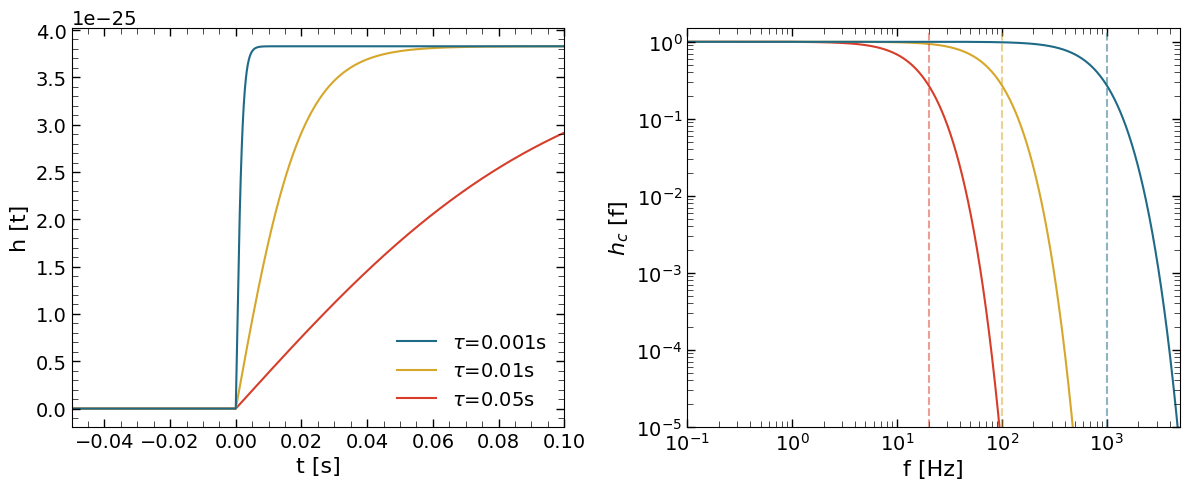

In [3]:
# Plot for illustration
t = np.linspace(-0.1, 10, int(1e5))
M_ej = 0.01 # ejecta masses in solar masses
v_ej = 0.2
tau = [1e-3, 1e-2, 5e-2] # timescales in seconds
r = 100e6 # 100 Mpc
theta_ej = np.pi / 4 # observer angle in radians
colors = ['#1F6A86','#D6A72A', '#D63E2A']
# plots for different timescales in time and frequency domain
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, tau_i in enumerate(tau):
    delta_h = up.delta_h_ejecta(M_ej, v_ej, r)
    print(delta_h)
    # Use the memory formula for the GRB but set h_in = 0 and radius = 0 to get the memory from the ejecta 
    # (reduced to same formula - but not the same step-function behavior. Here it is a t/tau function and not an exp/tanh function)
    h_t = up.linear_memory_ejecta_masked(t, M_ej, v_ej, tau_i, r, start_s=0, model='exponential')
    axes[0].plot(t, h_t, label=rf'$\tau$={tau_i}s', color=colors[idx], zorder = -idx)
    f, fft = up.fft_exp_model(1, tau_i)
    print(2*f[0]*fft[0])
    # Plot frequency-domain memory
    axes[1].loglog(f, 2* f* np.abs(fft), label=rf'$\tau$={tau_i}s', color=colors[idx], zorder = -idx)
    # Plot vlines the characteristic frequency associated to the timescale tau
    f_char = 1 / tau_i
    axes[1].axvline(f_char, color=colors[idx], linestyle='--', alpha=0.5)

    

axes[0].set_xlabel('t [s]')
axes[0].set_xlim(-0.05, 0.1)
axes[0].set_ylabel('h [t]')

axes[1].set_xlabel('f [Hz]')
axes[1].set_ylabel(r'$h_c$ [f]')
axes[0].legend(loc='lower right', frameon=False, fontsize=14)
axes[1].set_xlim(1e-1, 5e3)
axes[1].set_ylim(1e-5, 1.5)
plt.tight_layout()
plt.savefig(out_dir + "illustration_memory_phenom_def.png")


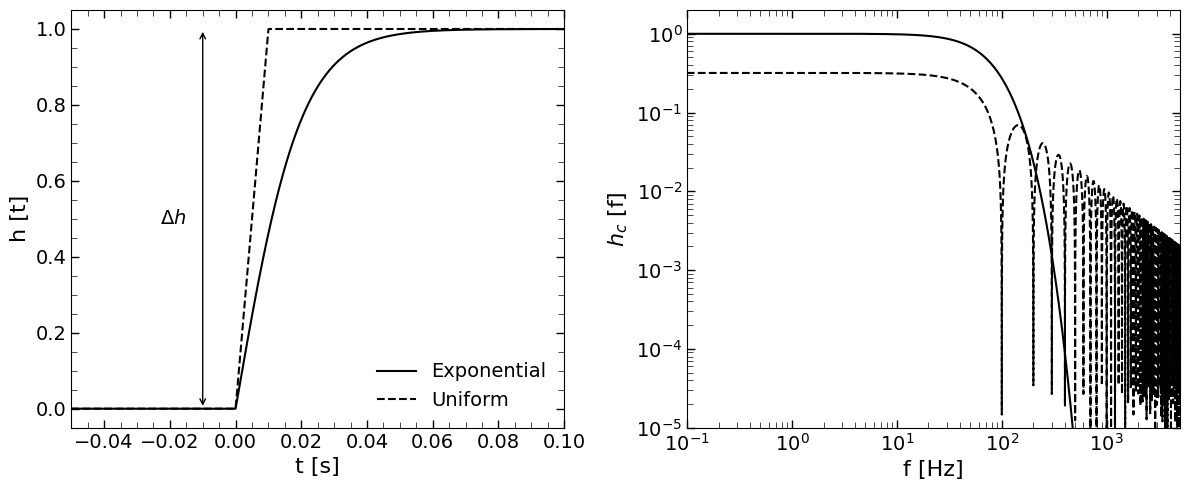

In [30]:
# Plot des 3 modèles pour tau = 0.01s
importlib.reload(up)
tau_i = 0.01
delta_h = 1
r = 1e6
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
h_exp = up.linear_memory_ejecta_masked(t, M_ej, v_ej, tau_i, r, start_s=0, model='exponential')
f_exp, fft_exp = up.fft_exp_model(delta_h, tau_i)
h_linear = up.model_linear(t, delta_h, tau_i)
f_linear, fft_linear = up.memory_fft_formula(delta_h, tau_i, plot=False)

# plot time-domain
axes[0].plot(t, h_exp, label='Exponential', color='k', ls = '-')
axes[0].plot(t, h_linear, label='Uniform', color='k', ls = '--')
# Add a arrow <-> to show the amplitude of the memory
axes[0].annotate('', xy=(-0.01, delta_h), xytext=(-0.01, 0), arrowprops=dict(arrowstyle='<->', color='k'))
axes[0].text(-0.015, delta_h/2, r'$\Delta h$', fontsize=14, color='k', va='center', ha='right')
axes[0].set_xlabel('t [s]')
axes[0].set_xlim(-0.05, 0.1)
axes[0].set_ylabel('h [t]')
axes[0].legend(loc='lower right', frameon=False, fontsize=14)
# plot frequency-domain
axes[1].loglog(f_exp, 2* f_exp* np.abs(fft_exp), label='Exponential', color='k', ls = '-')
axes[1].loglog(f_linear,  np.abs(fft_linear), label='Linear', color='k', ls = '--')
axes[1].set_xlabel('f [Hz]')
axes[1].set_ylabel(r'$h_c$ [f]')
axes[1].set_xlim(1e-1, 5e3)
axes[1].set_ylim(1e-5, 2)

plt.tight_layout()
plt.show()

Min - Max case for the dyn/wind case

Start time for the dynamical ejecta: -0.010986122886681098 s
Delta h for minimum case: 9.570831683175683e-28
Delta h for maximum case: 1.5313330693081091e-24


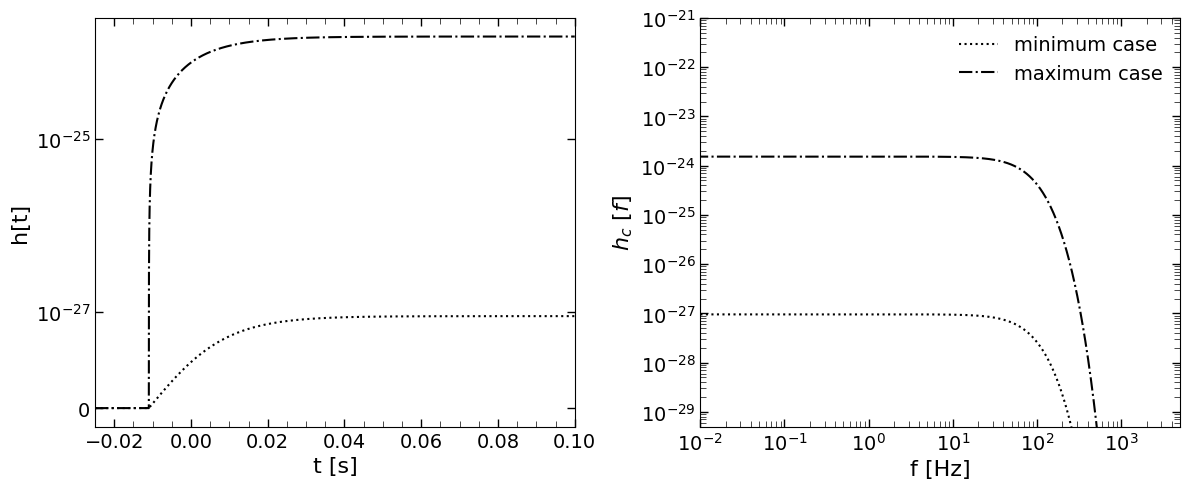

Delta h for minimum case: 9.570831683175683e-27
Delta h for maximum case: 3.828332673270273e-25


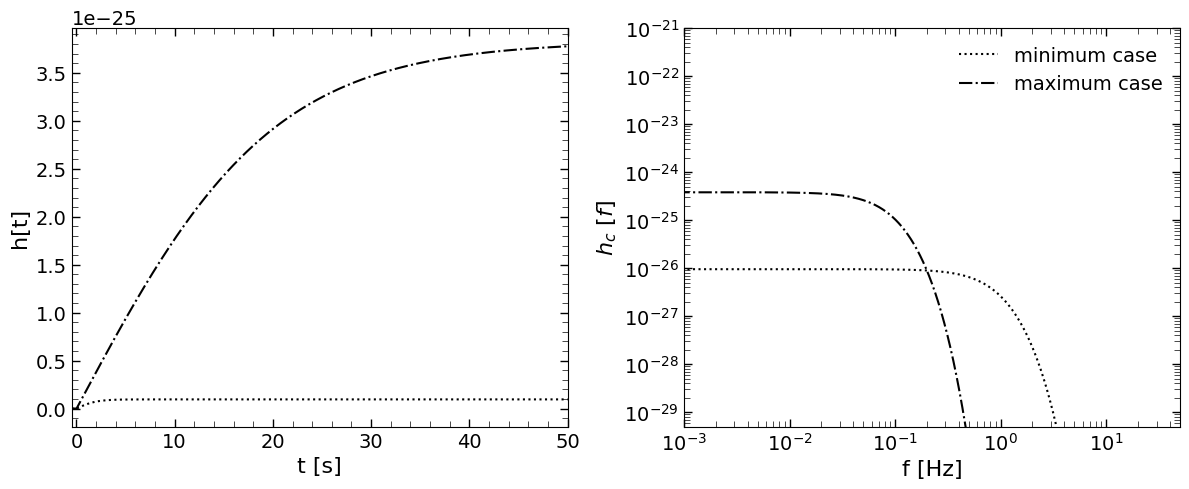

In [4]:
# Dynamical ejecta
start_dyn = np.log(1/3)* 1e-2 # time at which the memory reaches half of its maximum value (for the exponential model, it is -ln(2)*tau)
print(f"Start time for the dynamical ejecta: {start_dyn} s")
start_wind = 1e-2
dyn_params = {
    'min': {'M_ej': 0.01e-2, 'v_ej': 0.1, 'tau': 1e-2},  # min mass, min velocity, min tau
    'max': {'M_ej': 1e-2,    'v_ej': 0.4, 'tau': 1e-2},  # max mass, max velocity, max tau
}
# Wind ejecta
wind_params = {
    'min': {'M_ej': 1e-3,  'v_ej': 0.1, 'tau': 1},    # min mass, min velocity, min tau
    'max': {'M_ej': 1e-2,  'v_ej': 0.2, 'tau': 10},   # max mass, max velocity, max tau
}

r = 100e6  # 100 Mpc
t_dyn = np.linspace(-0.025, 0.1, 10000)
t_wind = np.linspace(-0.5, 50, 10000)

fig_dyn, axes_dyn = plt.subplots(1, 2, figsize=(12, 5))

for label, p, ls in zip(['minimum case', 'maximum case'], [dyn_params['min'], dyn_params['max']], ['dotted', '-.']):
    h_dyn = up.linear_memory_ejecta_masked(t_dyn, p['M_ej'], p['v_ej'], p['tau'], r, start_s=start_dyn, model='exponential')
    delta_h_dyn = up.delta_h_ejecta(p['M_ej'], p['v_ej'], r)
    print(f"Delta h for {label}: {delta_h_dyn}")
    f_dyn, fft_dyn = up.fft_exp_model(delta_h_dyn, p['tau'])
    axes_dyn[0].plot(t_dyn, h_dyn, label=f"{label}", color='k', ls=ls)
    axes_dyn[1].loglog(f_dyn, 2*f_dyn*np.abs(fft_dyn), label=f"{label}", color='k', ls=ls)


axes_dyn[0].set_xlabel('t [s]')
axes_dyn[0].set_ylabel('h[t]')
axes_dyn[0].set_yscale('symlog', linthresh=1e-27, linscale=1)
axes_dyn[0].set_xlim(-0.025, 0.1)


axes_dyn[1].set_xlabel('f [Hz]')
axes_dyn[1].set_ylabel(r'$h_c~[f]$')
axes_dyn[1].legend(frameon=False, fontsize=14)
axes_dyn[1].set_xlim(1e-2, 5e3)
axes_dyn[1].set_ylim(5e-30, 1e-21)

plt.tight_layout()
plt.show()

# --- Wind ejecta ---
fig_wind, axes_wind = plt.subplots(1, 2, figsize=(12, 5))

for label, p, ls in zip(['minimum case', 'maximum case'], [wind_params['min'], wind_params['max']], ['dotted', '-.']):
    h_wind = up.linear_memory_ejecta_masked(t_wind, p['M_ej'], p['v_ej'], p['tau'], r, start_s=start_wind, model='exponential')
    delta_h_wind = up.delta_h_ejecta(p['M_ej'], p['v_ej'], r)
    print(f"Delta h for {label}: {delta_h_wind}")
    f_wind, fft_wind = up.fft_exp_model(delta_h_wind, p['tau'])
    axes_wind[0].plot(t_wind, h_wind, label=f"{label}", color='k', ls=ls)
    axes_wind[1].loglog(f_wind, 2*f_wind*np.abs(fft_wind), label=f"{label}", color='k', ls=ls)


axes_wind[0].set_xlabel('t [s]')
axes_wind[0].set_ylabel('h[t]')
axes_wind[0].set_xlim(-0.5, 50)


axes_wind[1].set_xlabel('f [Hz]')
axes_wind[1].set_ylabel(r'$h_c~[f]$')
axes_wind[1].legend(frameon=False, fontsize=14)
axes_wind[1].set_xlim(1e-3, 5e1)
axes_wind[1].set_ylim(5e-30, 1e-21)

plt.tight_layout()
plt.show()

Angular factor

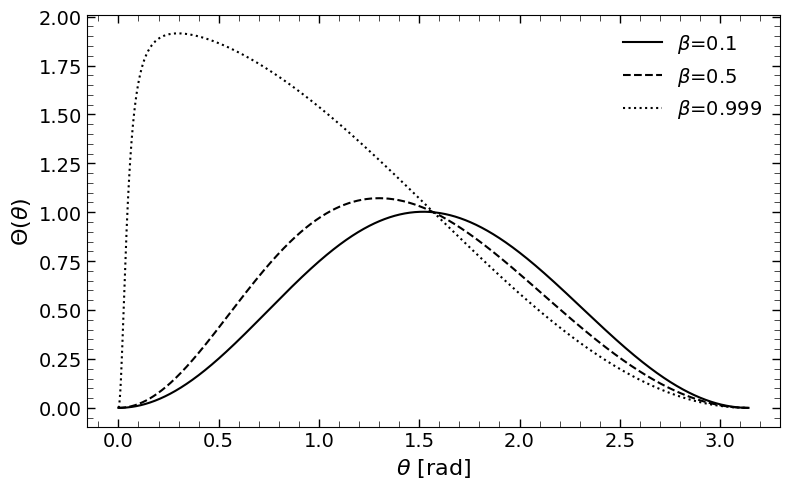

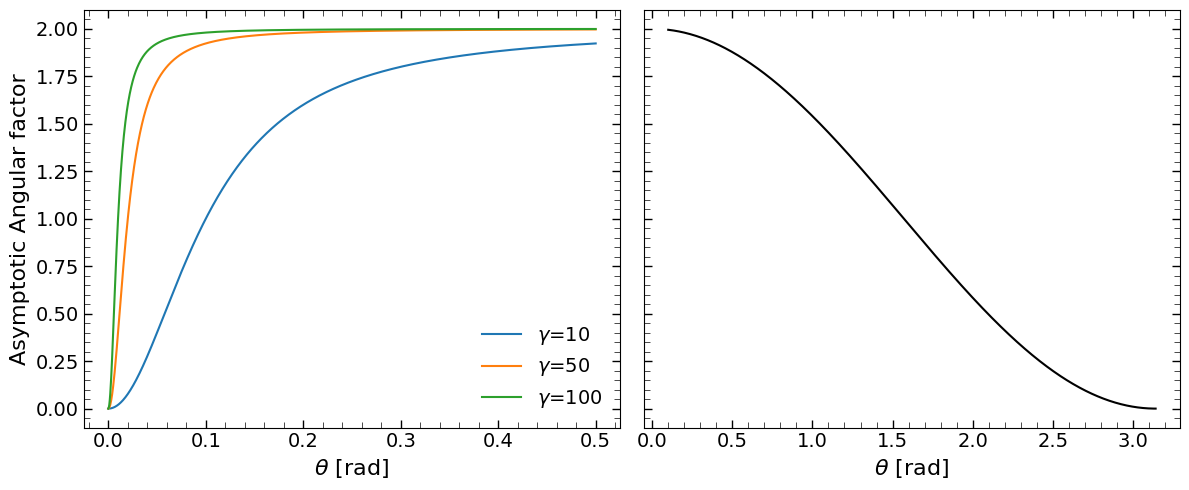

In [5]:
# Angular factor plot for different beta values
beta_values = [0.1, 0.5, 0.999]
theta = np.linspace(0, np.pi, 1000)
ls = ['solid', 'dashed', 'dotted']
fig, ax = plt.subplots(figsize=(8, 5))
def angular_factor(theta, beta):
    return (np.sin(theta)**2) / (1 - beta * np.cos(theta))
for beta, ls in zip(beta_values, ls):
    ax.plot(theta, angular_factor(theta, beta), label=rf'$\beta$={beta}', ls=ls, color='k')
ax.set_xlabel(r'$\theta$ [rad]')
ax.set_ylabel(r'$\Theta(\theta)$')
ax.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

# Asymptotic behavior of the angular factor for beta close to 1 and theta close to 0
def angular_factor_asymptotic(theta, gamma):
    return (2*theta**2) / (gamma**(-2) + theta**2)
# test 1 : \gamma >> 1 and theta << 1
gammas = [10, 50, 100]
theta_asymp = np.linspace(0, 0.5, 1000)
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 5), sharey=True)
for gamma in gammas:
    ax1.plot(theta_asymp, angular_factor_asymptotic(theta_asymp, gamma), label=rf'$\gamma$={gamma}')
ax1.set_xlabel(r'$\theta$ [rad]')
ax1.set_ylabel('Asymptotic Angular factor')
ax1.legend(frameon=False, fontsize=14)


# test 2 : \gamma >> 1 and theta >> 1/gamma
# new formula : 1+cos(theta)
gammas = [10, 100, 1000]
theta_asymp = np.linspace(0.1, np.pi, 1000)
ax2.plot(theta_asymp, 1 + np.cos(theta_asymp), color='k', ls='-')
ax2.set_xlabel(r'$\theta$ [rad]')

plt.tight_layout()
plt.show()

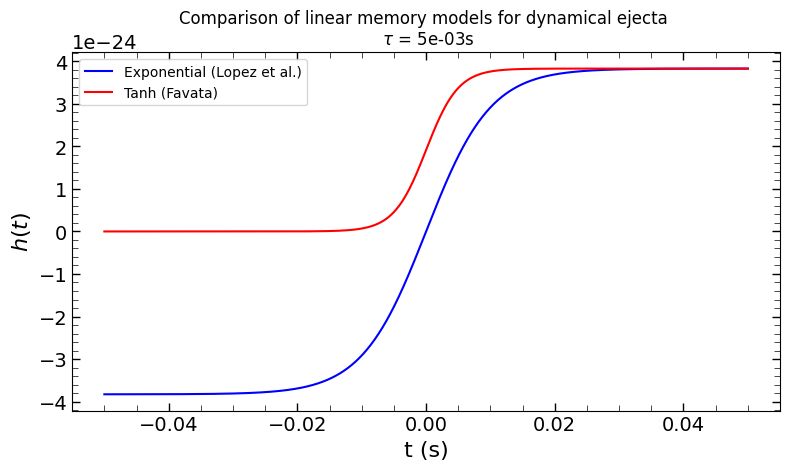

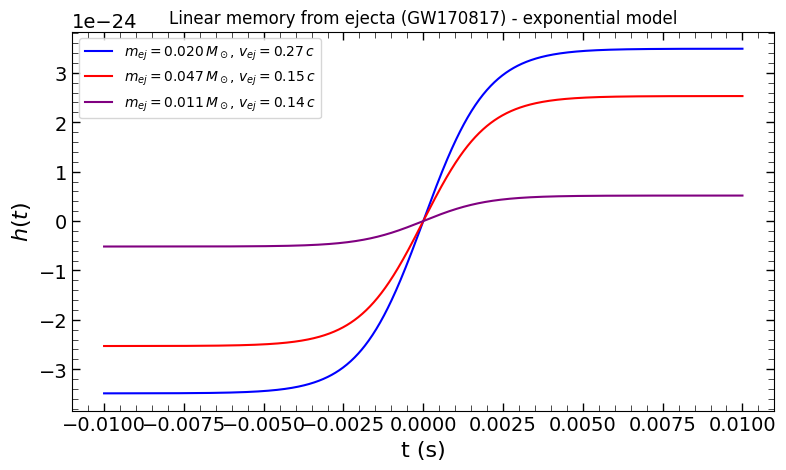

In [6]:
# 1. Plot for typical dynamical ejecta (Lopez vs Favata)
tau = 5e-3  # s
M_ej_dyn = 0.04  # solar masses
v_ej_dyn = 0.2   # m/s
r = 40e6  # Mparsecs
t = np.linspace(-0.05, 0.05, 1000)

# Exponential model
_, h_lopez = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='exponential', plot=0)
# Tanh model
_, h_favata = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='tanh', plot=0)

plt.figure(figsize=(8, 5))
plt.plot(t, h_lopez, label='Exponential (Lopez et al.)', color='blue')
plt.plot(t, h_favata, label='Tanh (Favata)', color='red')
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title(f"Comparison of linear memory models for dynamical ejecta \n $\\tau$ = {tau:.0e}s")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir + f"memory_comparison_dynamical_ejecta_tau_{tau:.0e}s.png")
plt.show()

# 2. Plot for GW170817 ejecta components (Lopez model)
M_ej_arr = np.array([0.02, 0.047, 0.011])  # solar masses
v_ej_arr = np.array([0.27, 0.15, 0.14])   # m/s
r_gw = 40e6  # parsecs
tau_gw = 0.001  # s
t_gw = np.linspace(-0.01, 0.01, 1000)
colors = ['blue', 'red', 'purple']

plt.figure(figsize=(8, 5))
for i in range(3):
    _, h = up.phenom_memory_models(tau_gw, M_ej_arr[i], v_ej_arr[i], r_gw, t_gw, model='exponential', plot=False)
    plt.plot(t_gw, h, color=colors[i],
             label=f"$m_{{ej}}={M_ej_arr[i]:.3f}\\,M_\\odot$, $v_{{ej}}={v_ej_arr[i]:.2f}\\,c$")
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title("Linear memory from ejecta (GW170817) - exponential model")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir + "memory_gw170817_ejecta_test_models.png")
plt.show()

## Plot of the dynamical, wind and total memory for a given model

To be more physcially motivated, we can apply masks to the memory evolution, so that the memory grows only during the time of activity of each ejecta component. After the end of the activity, the memory remains constant. This is done in the function `linear_memory_ejecta_masked` defined in `utils_phenom.py`. Based on the Table 1 of https://arxiv.org/pdf/1912.05659, the typical time of activity of each ejecta component is given by the following ranges:
- Dynamical ejecta: 0 to 10 ms with a caracteristic timescale of 1 ms
- Wind ejecta: 10 ms to 10 s with a caracteristic timescale of 1 s

/home/pycbc/work/Memory_Lopez/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return (2*delta_h * (1/(1 + np.exp(-t / tau))-0.5))


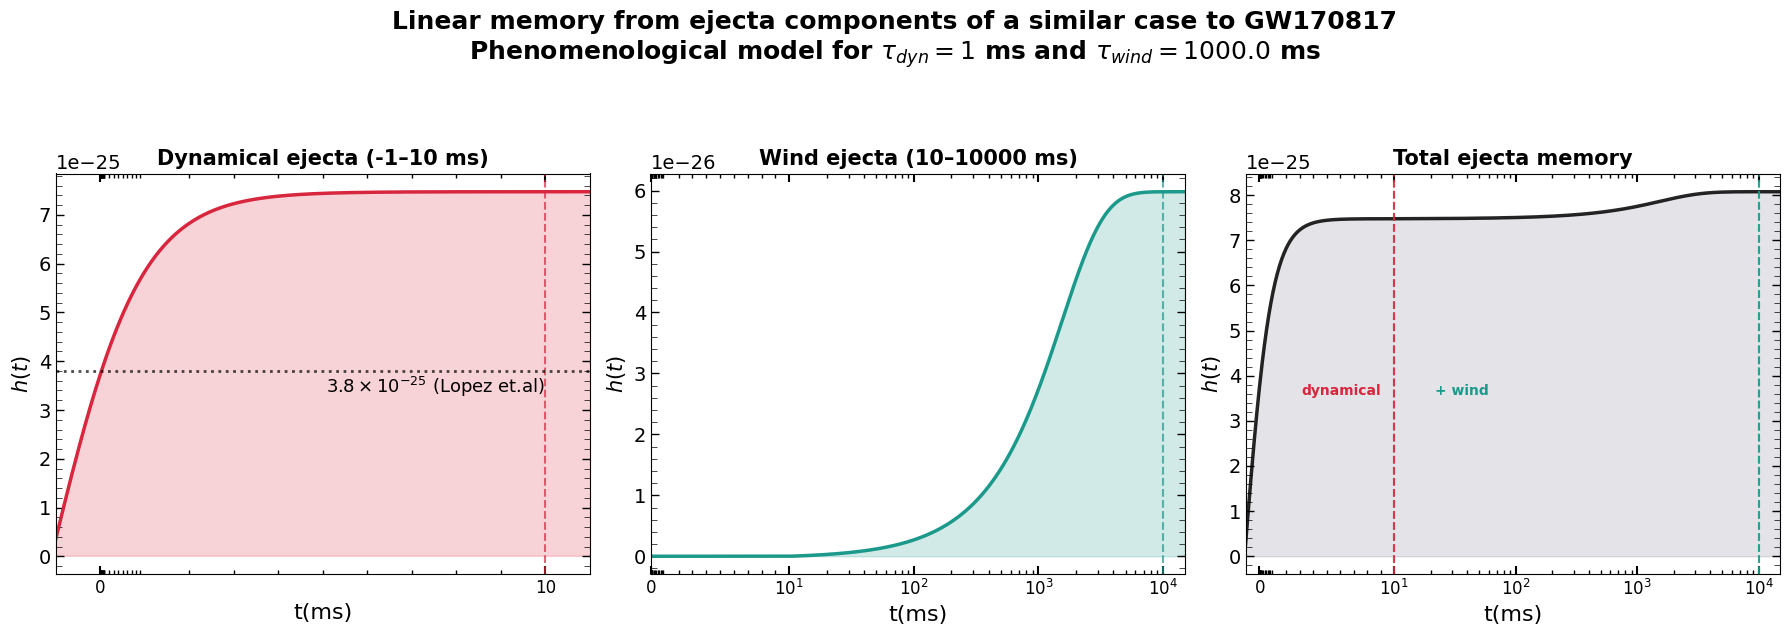

In [7]:
# Parameters 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1  

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3  

r = 40  * 1e6  
t = np.linspace(-5., 15., 500000) * 1e3  # ms

# Physically motivated time ranges for the activity of each ejecta component (to be modified according to the simulations and assumptions: EOS, mass ratio, etc)
start_dyn, end_dyn = -tau_dyn_ms * np.log(3), 10 # ms for the plot
start_wind, end_wind = 10, 10e3 
up.phenom_memory_ejecta_components(
    t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    r, model='exponential', plot=True, save=True
)

Start time for dynamical ejecta: -1.10 ms
Time to reach half of final memory: 0.01000 ms


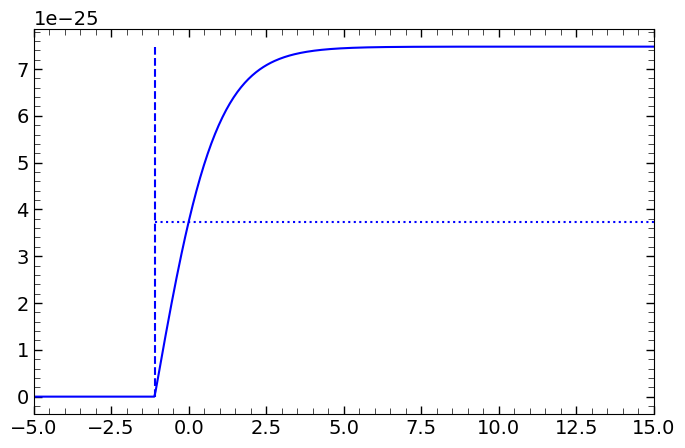

In [8]:
t_start_dyn = -tau_dyn_ms * np.log(3) 
h_t = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, r, start_s=t_start_dyn, model='exponential')
plt.figure(figsize=(8, 5))
plt.plot(t, h_t, label='Dynamical ejecta', color='blue')
plt.vlines(t_start_dyn, 0, np.max(h_t), color='blue', linestyle='--', label=f'Start time: {t_start_dyn:.2f} ms')
plt.hlines(h_t[-1]/2, t_start_dyn, t[-1], color='blue', linestyle=':', label=f'Half of final memory')
plt.xlim(-5, 15)
print(f"Start time for dynamical ejecta: {t_start_dyn:.2f} ms")
print(f"Time to reach half of final memory: {t[np.where(h_t >= h_t[-1]/2)[0][0]]:.5f} ms")

### Comparison of the different caracteristic timescales for each ejecta component

Now we can determined how the caracteristic timescale of each ejecta component impact the total memory evolution :

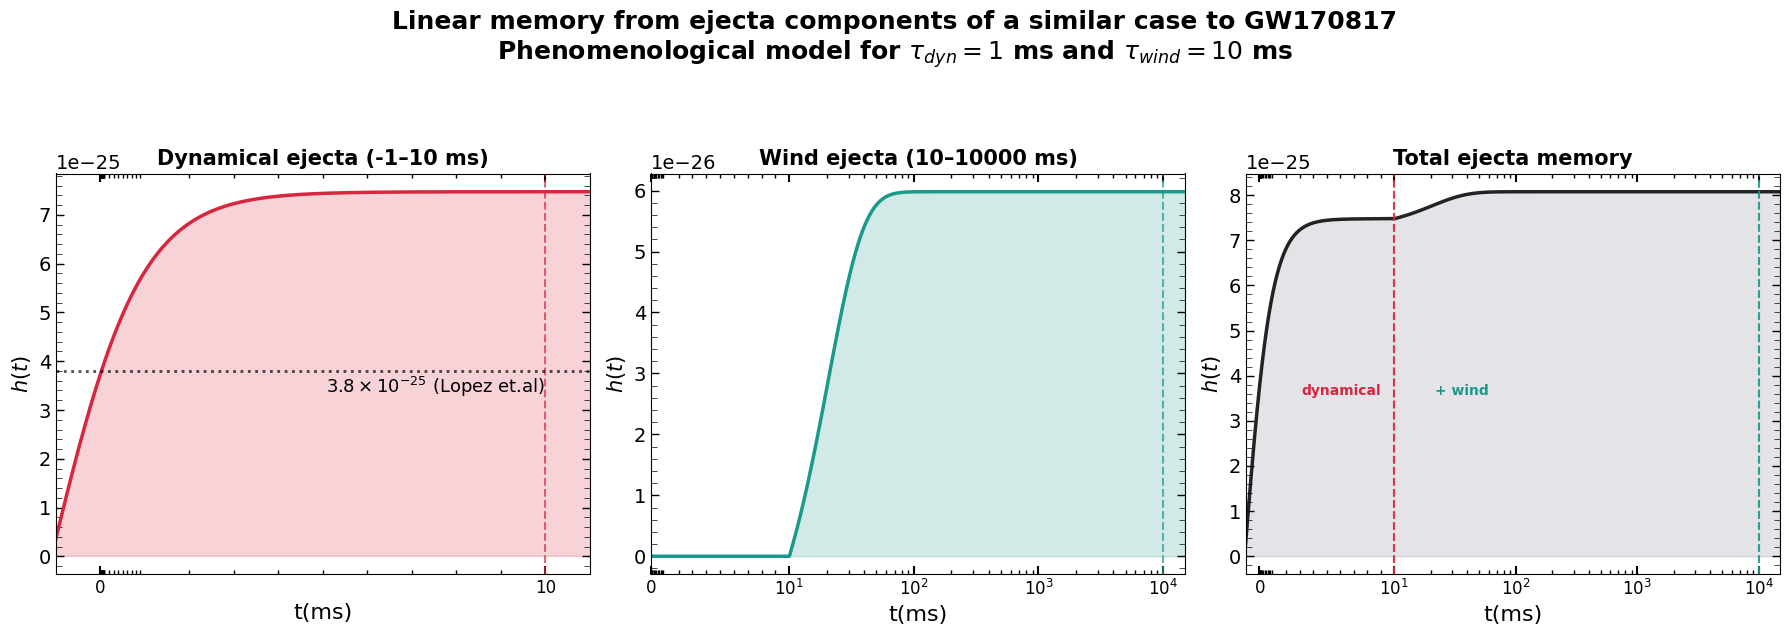

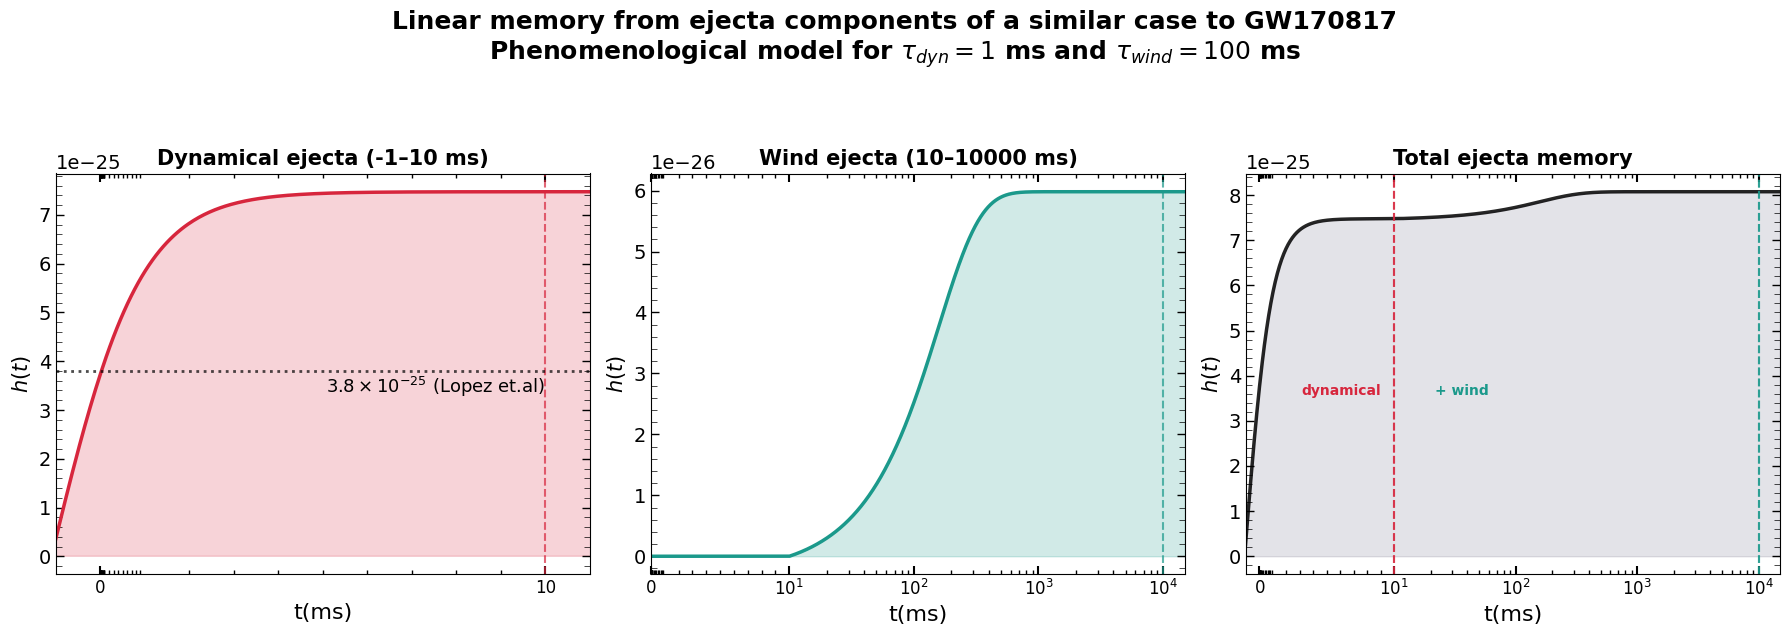

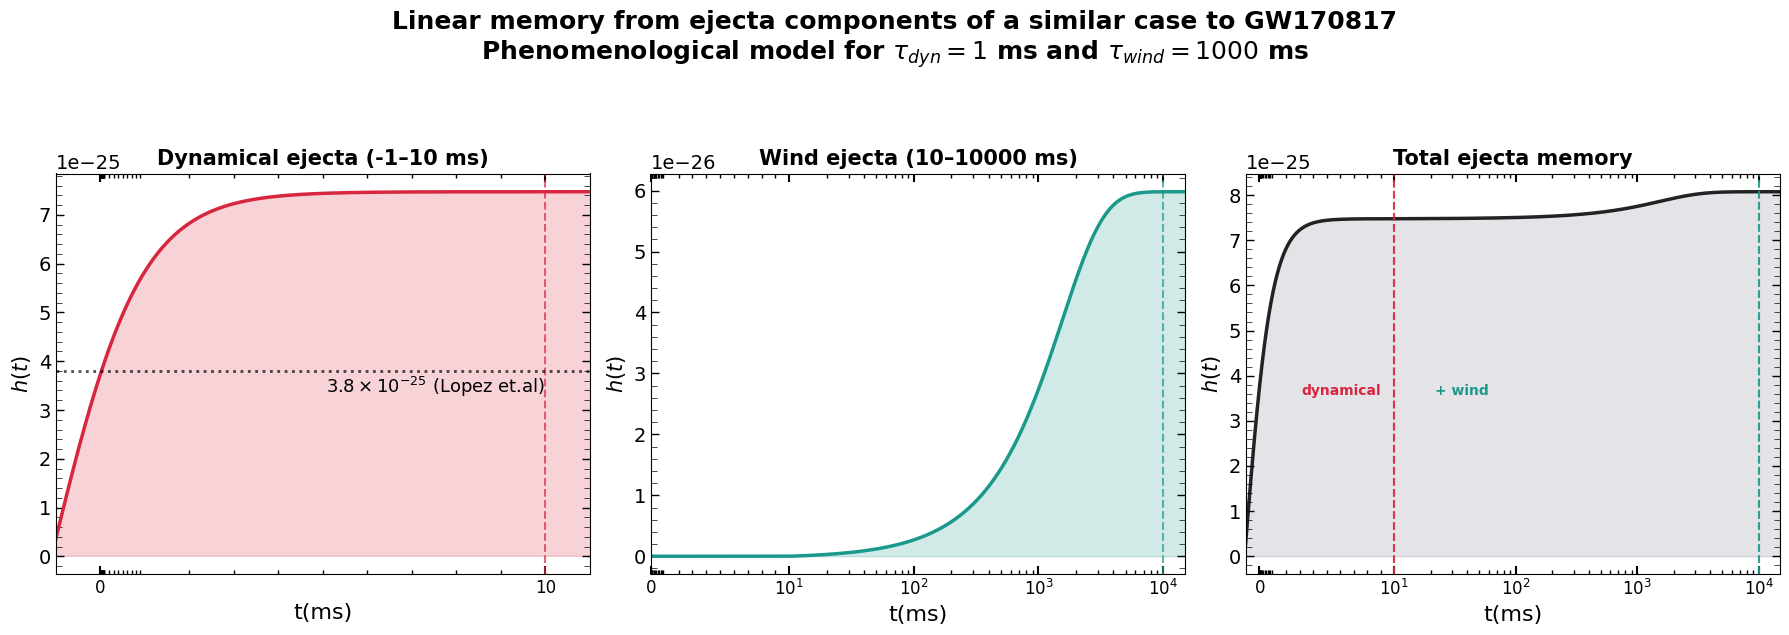

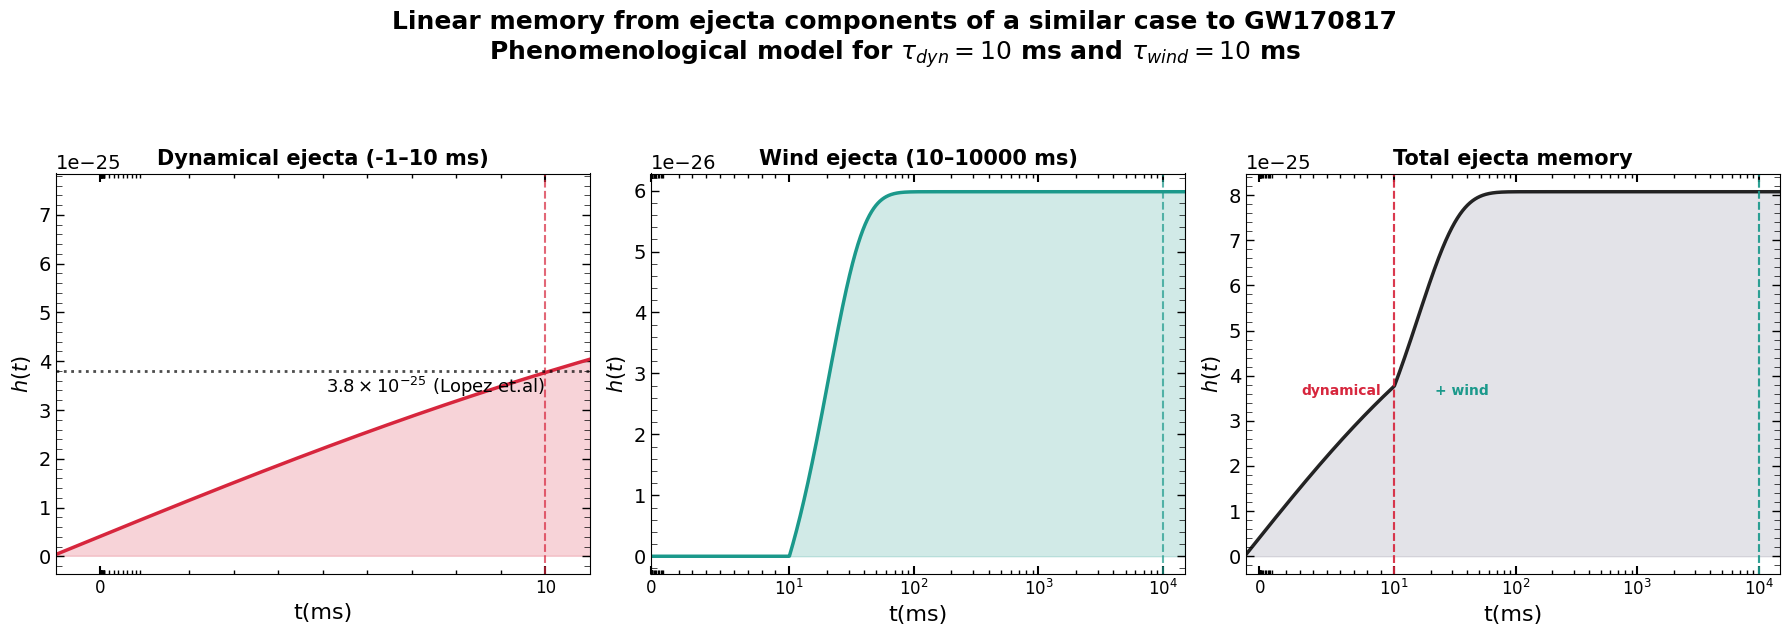

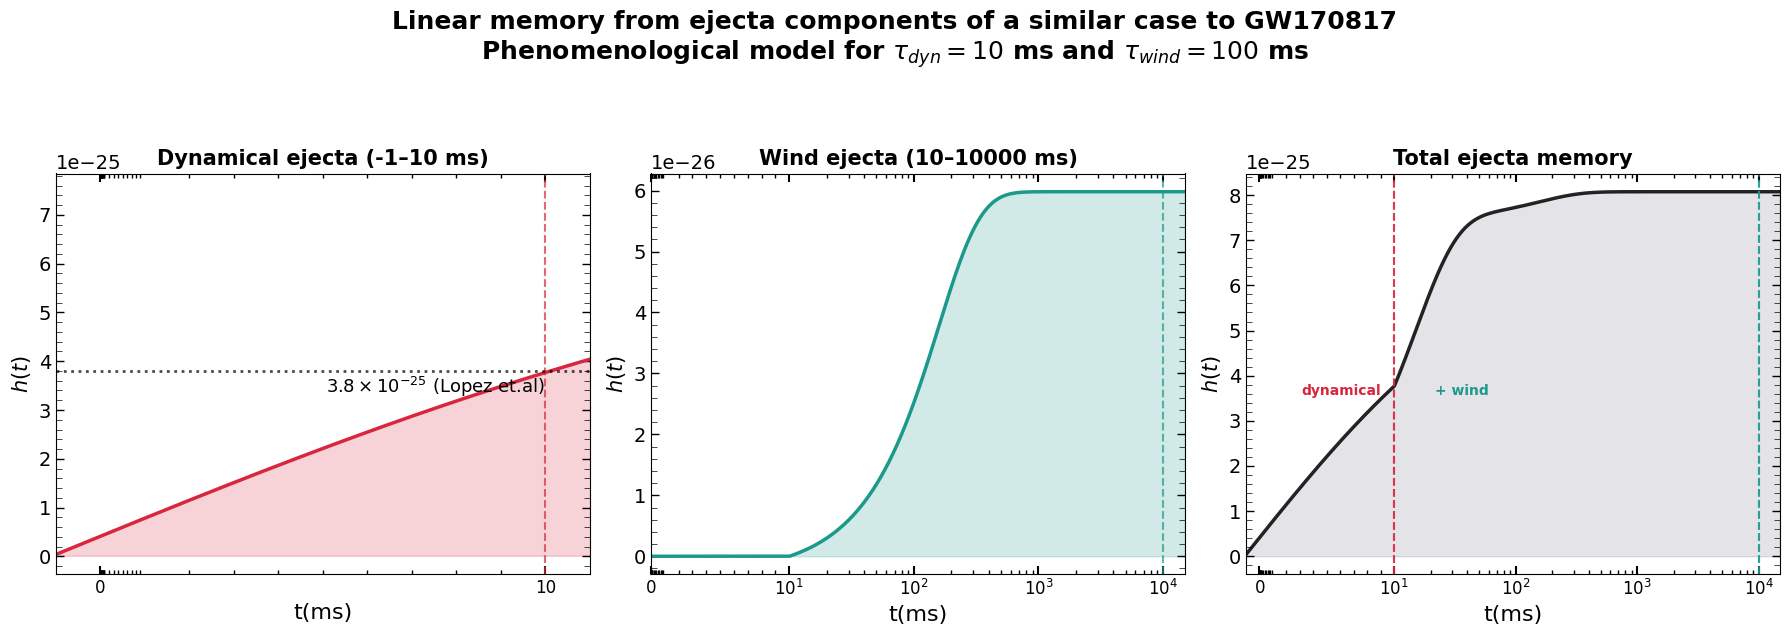

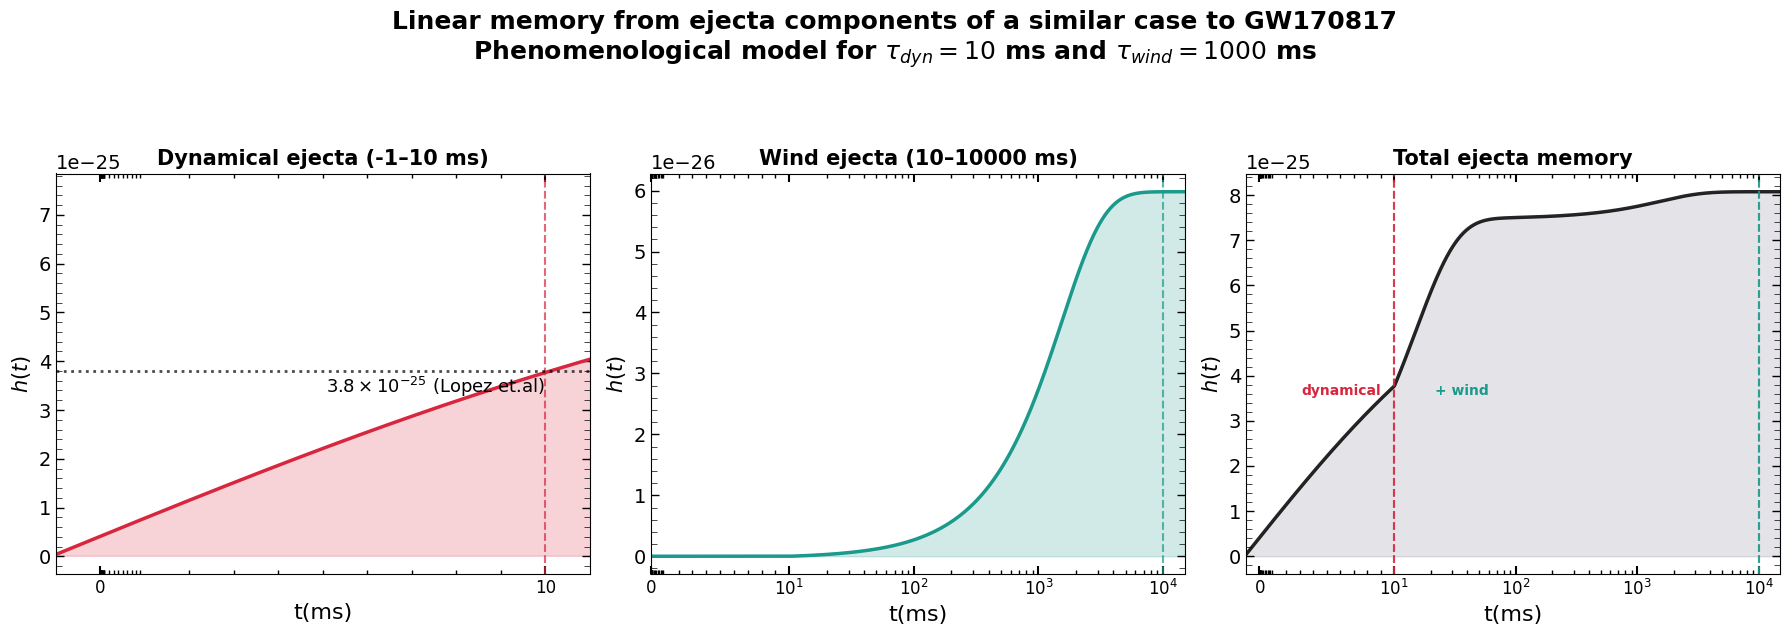

In [9]:
tau_dyn_ms = [1, 10] 
tau_wind_ms = [10,100, 1000] 
for tau_dyn in tau_dyn_ms:
    for tau_wind in tau_wind_ms:
        up.phenom_memory_ejecta_components(
            t, M_ej_dyn, v_ej_dyn, tau_dyn, start_dyn, end_dyn,
            M_ej_wind, v_ej_wind, tau_wind, start_wind, end_wind,
            r, model='exponential', plot=True, save=True)
        

GRB memory

A GRB can produce a memory signal that dependends on the release of energy $E_j$ in accelerating jets (forward and backward) with ultrarelativistic velocities. If we denode by $\beta\sim 1$ the velocity of the jets and by $\theta$ the angle between the jet axis and the line of sight, the memory signal can be estimated as  : 
$$\Delta h = \frac{2 E_j \beta^2}{r} \frac{\sin^2\theta}{1-\beta\cos\theta}$$

And it is estimated to have a caracteristic timescale of $\tau_{GRB} \sim 0.2 - 3$ ms (source ? https://arxiv.org/pdf/1201.4431 - conclusion a.), depending on the opening angle and composition of the jet(Lopez et al.). We can then apply the same phenomenological model as for the ejecta, but with this new timescale and a different amplitude. We can also add this contribution to the total memory from the ejecta. For the case of GRB170817A, the energy released in the jet is estimated to be $E_j \sim 10^{47}$ erg, which is much lower than the typical energy released in a GRB ($\sim 10^{51}$ erg). This is because GRB170817A was observed off-axis, with an angle of $\theta \sim 30$ degrees. The associated GRB is denoted as a sGRB, lasting ~2 s. 

Does the factor 2 is related to the fact that there are 2 jets (forward and backward) ?

I added a factor of $G/c^4$ in front of $\Delta h$ to make the amplitude of the GRB an adimensional strain.

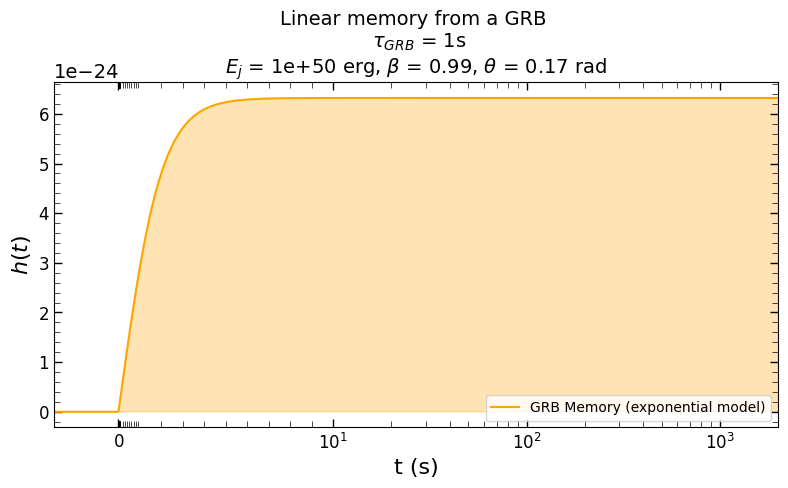

In [10]:
# Parameters for GRB memory
E_erg = 1e50  # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(10)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
r = 1  * 1e6  # parsecs
t = np.linspace(-5., 15., 500000) * 1e3  # ms
start_GRB, end_GRB = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
_= up.phenom_memory_GRB(t, E_erg, beta, theta, r, tau_grb_ms, start_GRB, end_GRB, model='exponential', plot=True)


We observe that the GRB memory has a **higher** amplitude than the ejecta memory, but a much shorter timescale. The total memory signal would then be dominated by the GRB contribution at early times, and by the ejecta contribution at later times.

The dependence in the angle $\theta$ is quite strong, so if the jet is not pointed towards us, the memory signal would be much weaker : 

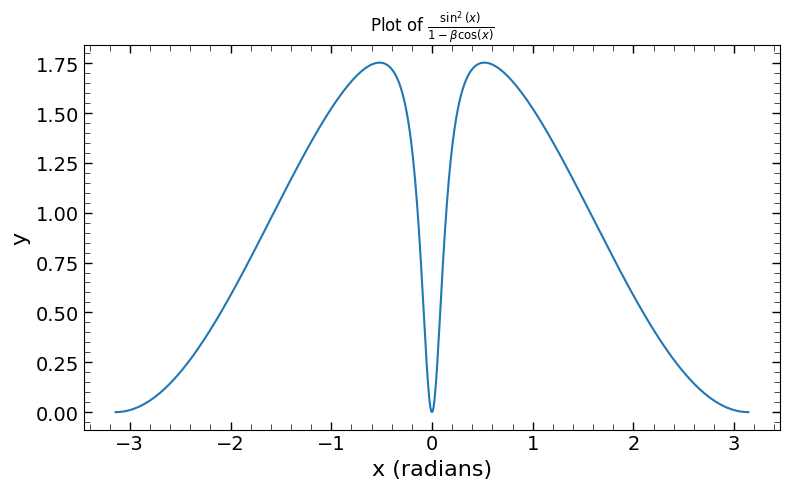

In [11]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)**2/ (1 - 0.99* np.cos(x))

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("x (radians)")
plt.ylabel("y")
plt.title(r"Plot of $\frac{\sin^2(x)}{1- \beta \cos(x)}$")
plt.tight_layout()
plt.savefig(out_dir + "angular_depedancy_grb.png")
plt.show()

Add the GRB memory to the total memory from the ejecta (dynamical + wind + GRB)

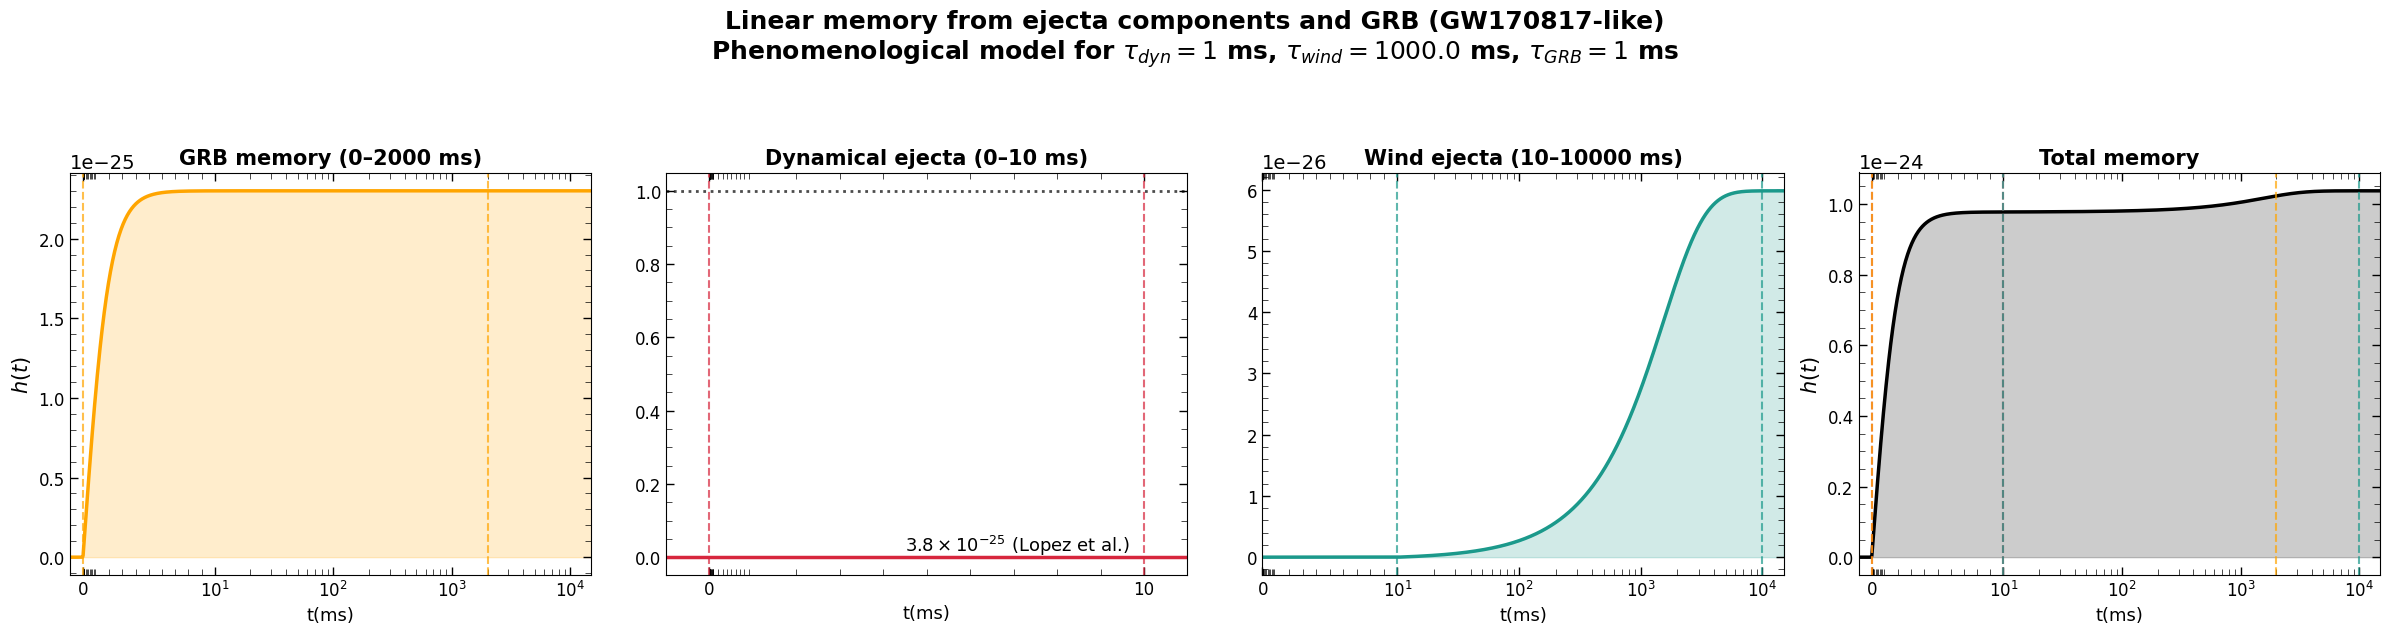

In [12]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1 

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 40  * 1e6  # 170817
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3

up.phenom_memory_ejecta_components_GRB(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb, 
    save=True
)

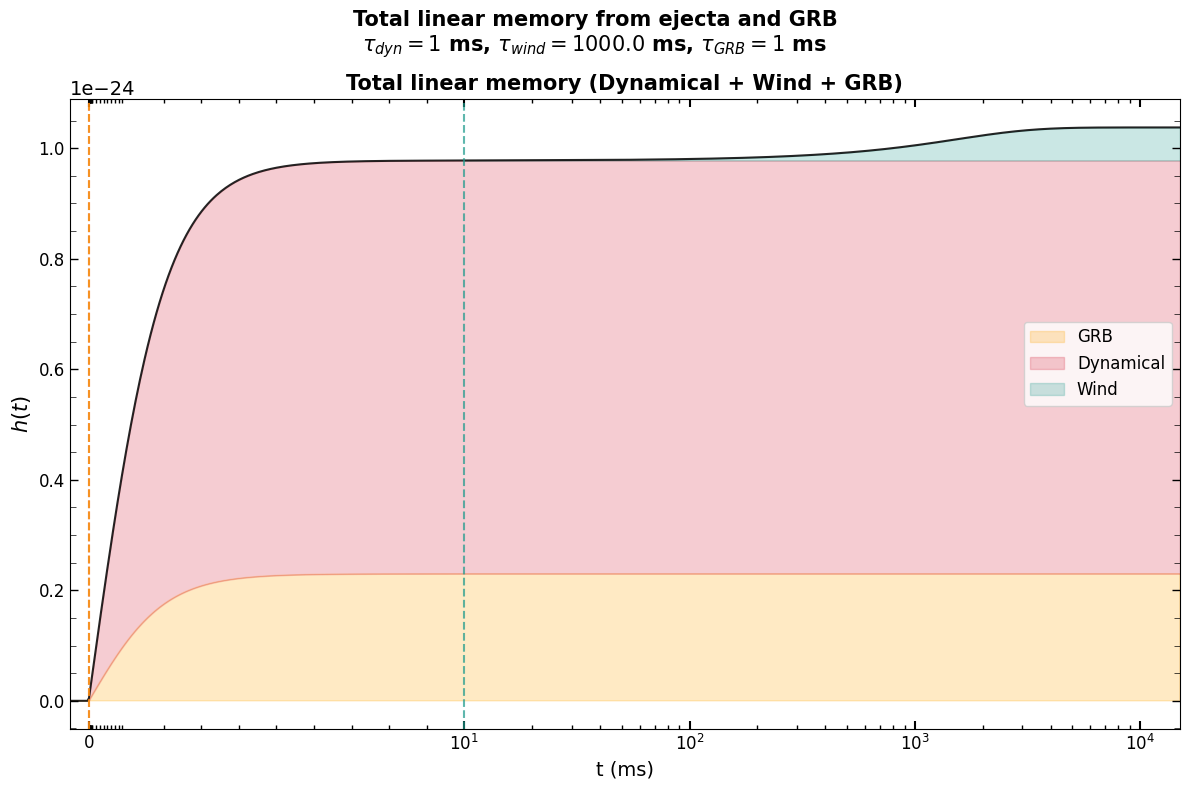

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.03753851e-24, 1.03753851e-24, 1.03753851e-24])

In [13]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 40  * 1e6  # 170817
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
up.phenom_memory_total_plot(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb,
    save = True
    
)

Test BOAT

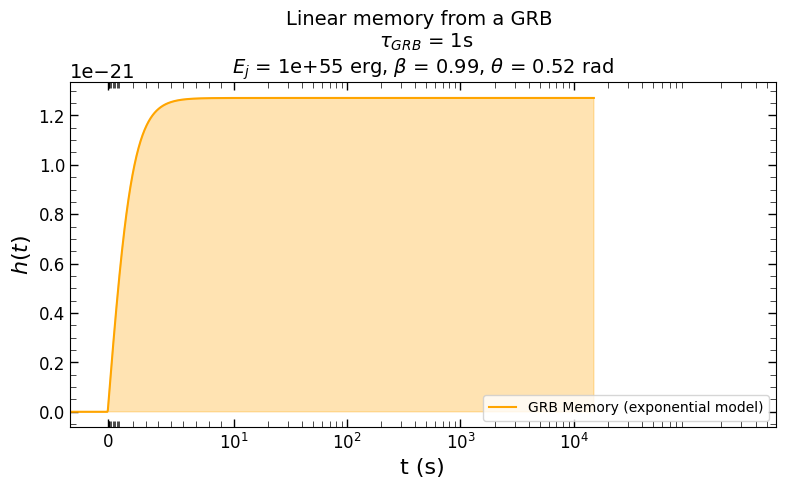

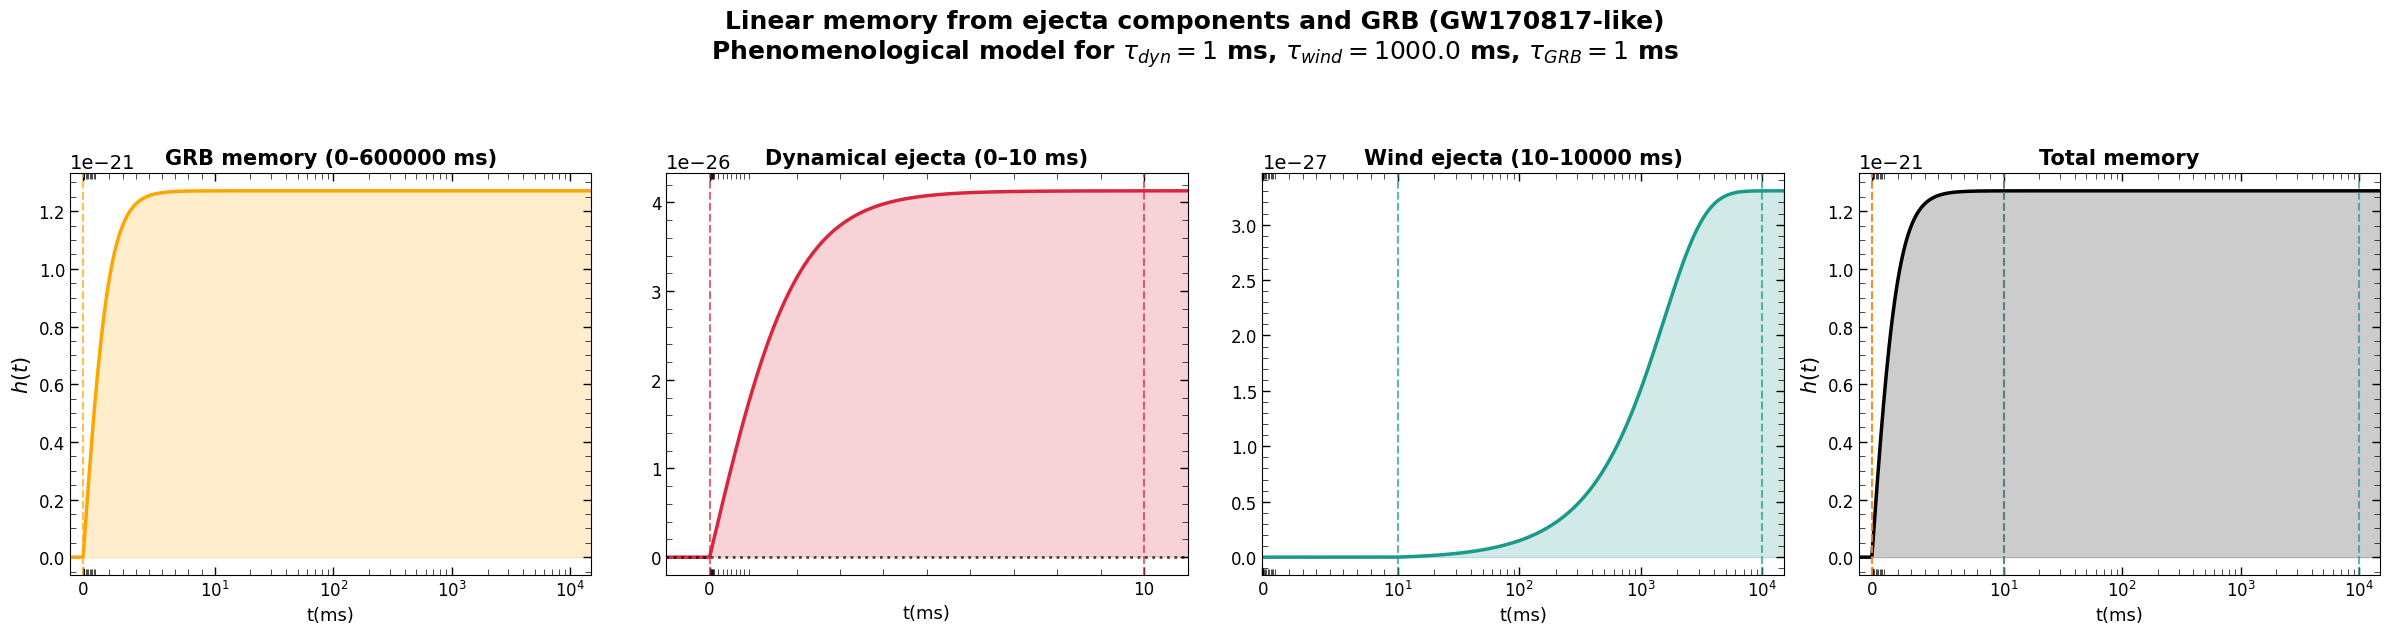

In [14]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1 

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 724  * 1e6  #BOAT
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3

up.phenom_memory_GRB(t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=True)

up.phenom_memory_ejecta_components_GRB(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb,
    delta_h_typical=False, save = True)


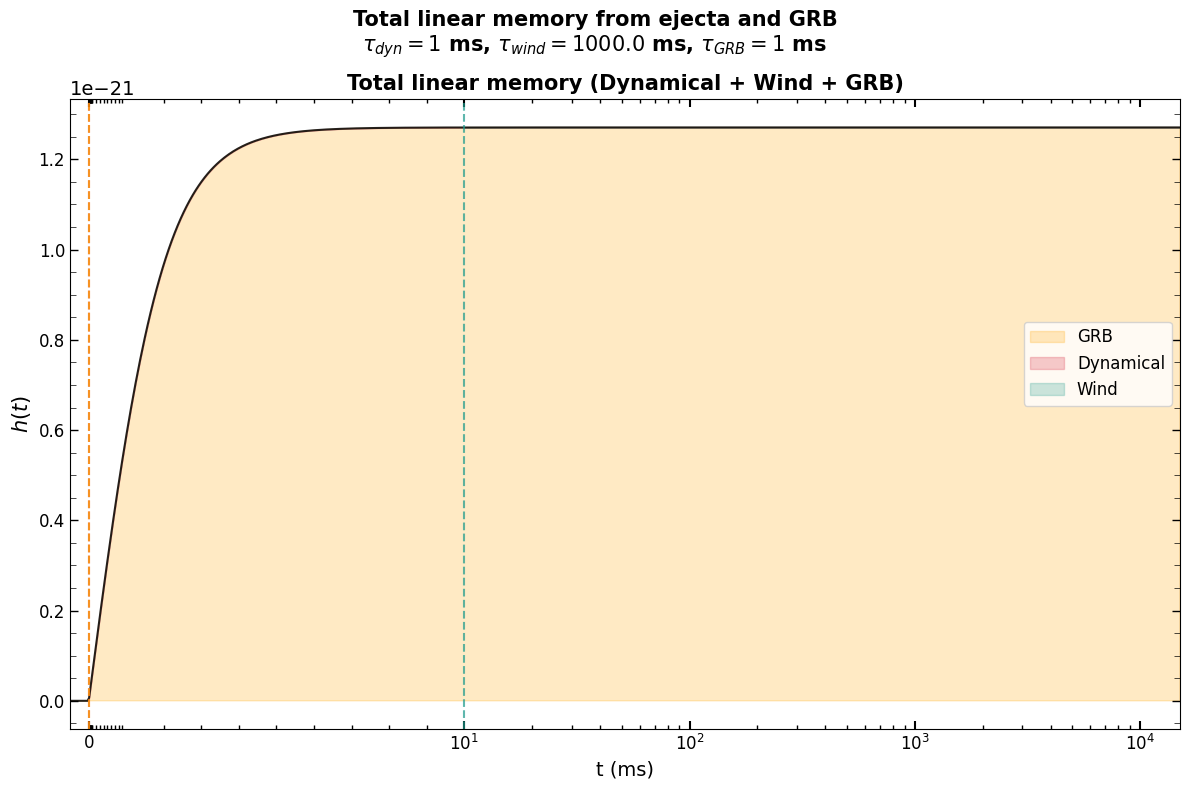

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.27076075e-21, 1.27076075e-21, 1.27076075e-21])

In [15]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r_BOAT = 724 * 1e6  # BOAT
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
up.phenom_memory_total_plot(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb,
    save = True
)

## Test with different parameters for the GRB memory

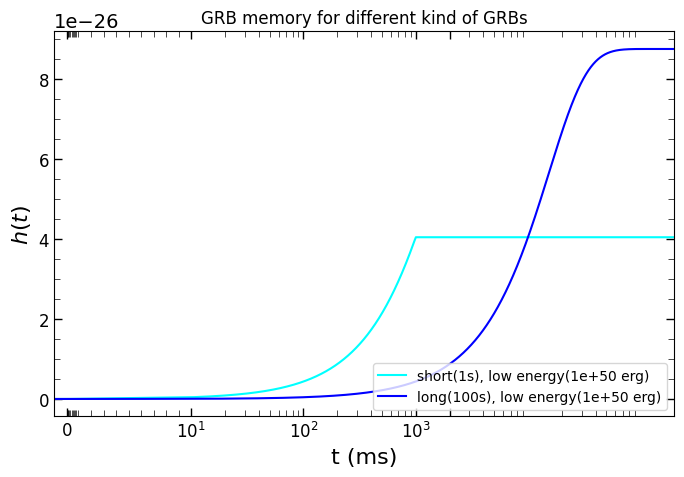

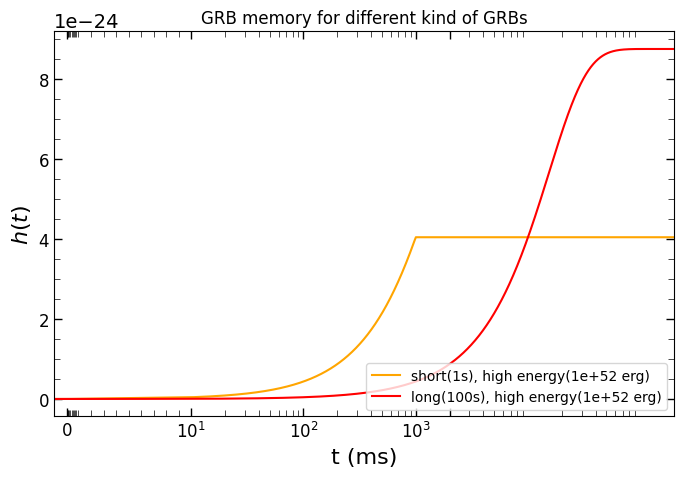

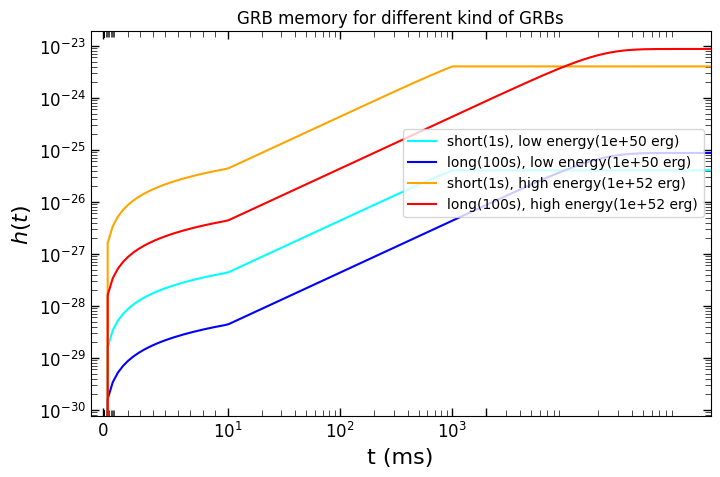

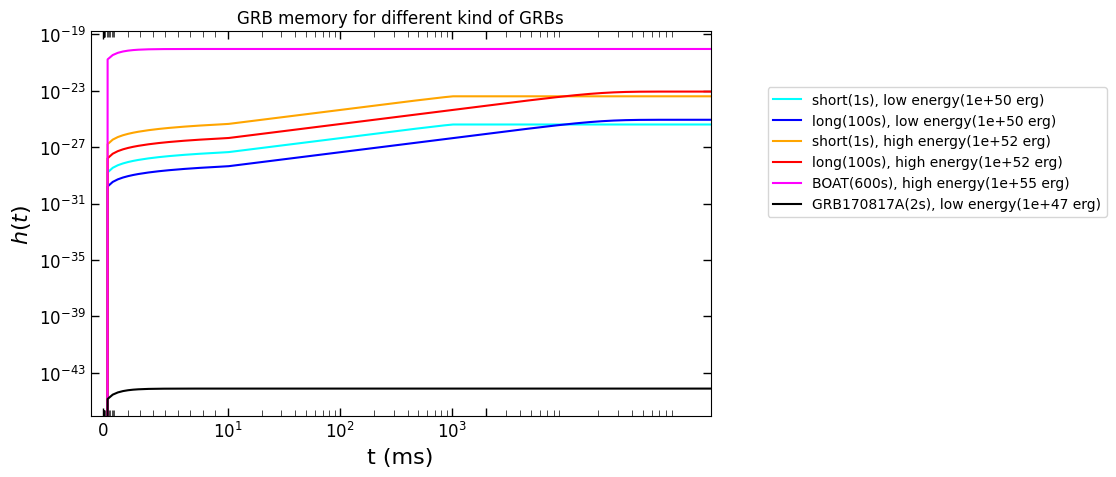

In [16]:
from matplotlib.ticker import FixedLocator, LogLocator
# test for a short low energetic GRB, short and higly energetic GRB, and a long GRB with low and high energy
# we test 4 cases 
t = np.linspace(-5., 200., 500000) * 1e3  # ms
r = 100 * 1e6  # 100 Mpc
# short : 1s -- long: 100s
end_grb = np.array([1, 100]) * 1e3 # s
# low energy: 1e49 erg -- high energy: 1e52 erg
energy = np.array([1e50, 1e52])  # erg
theta = np.deg2rad(45)  # 45 degrees off axis - tradeoff between detectability and rate
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = np.array([1, 10]) *1e3  # s
start_grb = 0
h_grb = []
cases =[
    {"energy": energy[0], "end_grb": end_grb[0], "label": "short" + f'({end_grb[0]/1000:.0f}s)'+", low energy"+ f'({energy[0]:.0e} erg)', 'color': 'cyan'},
    {"energy": energy[0], "end_grb": end_grb[1], "label": "long" + f'({end_grb[1]/1000:.0f}s)'+", low energy"+ f'({energy[0]:.0e} erg)', 'color': 'blue'},
    {"energy": energy[1], "end_grb": end_grb[0], "label": "short" + f'({end_grb[0]/1000:.0f}s)'+", high energy"+ f'({energy[1]:.0e} erg)', 'color': 'orange'},
    {"energy": energy[1], "end_grb": end_grb[1], "label": "long" + f'({end_grb[1]/1000:.0f}s)'+", high energy"+ f'({energy[1]:.0e} erg)', 'color': 'red'},
]
for e in energy:
    for end, tau in zip(end_grb, tau_grb_ms):
        h_grb.append(up.phenom_memory_GRB(
            t, e, beta, theta, r, tau, start_grb, end, model='exponential', plot=False))
        
# BOAT case 
E_j_boat = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta_boat = np.deg2rad(30)  # 30 degrees off axis
beta_boat = 0.99  # ultrarelativistic jet
tau_grb_boat_ms = 1  # ms
start_grb_boat, end_grb_boat = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
h_boat = up.phenom_memory_GRB(
    t, E_j_boat, beta_boat, theta_boat, r, tau_grb_boat_ms, start_grb_boat, end_grb_boat, model='exponential', plot=False)
# Plot short GRBs (1s, low and high energy)

# 170817 case
E_j_170817 = 1e47   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta_170817 = np.deg2rad(30)  # 30 degrees off axis
beta_170817 = 0.99  # ultrarelativistic jet
tau_grb_170817_ms = 1  # ms
start_grb_170817, end_grb_170817 = 0, 2000
r_170817 = 40 * PC_SI * 1e6  # 170817
h_170817 = up.phenom_memory_GRB(
    t, E_j_170817, beta_170817, theta_170817, r_170817, tau_grb_170817_ms, start_grb_170817, end_grb_170817, model='exponential', plot=False)

plt.figure(figsize=(8, 5))
for i in [0,1]:  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right")
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()

plt.figure(figsize=(8, 5))
for i in [2,3]:  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right")
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()


plt.figure(figsize=(8, 5))
for i in range(4):  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right", bbox_to_anchor=(1.0, 0.5))
plt.yscale('log')
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)
from matplotlib.ticker import FixedLocator, LogLocator
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()

plt.figure(figsize=(8, 5))
for i in range(4):  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.plot(t, h_boat, label='BOAT' + f'({end_grb_boat/1000:.0f}s)'+", high energy"+ f'({E_j_boat:.0e} erg)', color='magenta')
plt.plot(t, h_170817, label='GRB170817A' + f'({end_grb_170817/1000:.0f}s)'+", low energy"+ f'({E_j_170817:.0e} erg)', color='black')
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right", bbox_to_anchor=(1.65, 0.5))
plt.yscale('log')
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)
from matplotlib.ticker import FixedLocator, LogLocator
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()



## FFT of the different memory contributions

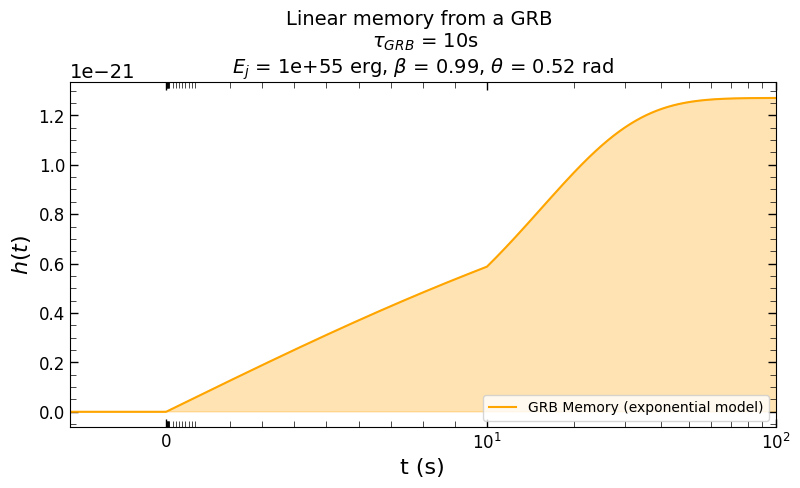

In [17]:
# BOAT case : 
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j_boat = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta_boat = np.deg2rad(30)  # 30 degrees off axis
beta_boat = 0.99  # ultrarelativistic jet
tau_grb_boat_s = 10 # s
r_boat = 724 * 1e6  # BOAT
start_grb_boat, end_grb_boat = 0, 600*1e3 # end GRB at 600s 

up.phenom_memory_GRB(t, E_j_boat, beta_boat, theta_boat, r_boat, tau_grb_boat_s, start_grb_boat, 1e2, model='exponential', plot=True)
h_BOAT = up.phenom_memory_GRB(
    t, E_j_boat, beta_boat, theta_boat, r_boat, tau_grb_boat_s, start_grb_boat, end_grb_boat, model='exponential', plot=False)

In [18]:
# GW170817 case
E_j_170817 = 1e47   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta_170817 = np.deg2rad(30)  # 30 degrees off axis
beta_170817 = 0.99  # ultrarelativistic jet
tau_grb_170817_ms = 1  # ms
start_grb_170817, end_grb_170817 = 0, 2000
r_170817 = 40 * 1e6 

# Ejecta parameters for GW170817
M_ej_dyn = 0.04  # solar masses
v_ej_dyn = 0.2   # m/s
tau_dyn_ms = 1  # ms

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
h_170817_grb = up.phenom_memory_GRB(
    t, E_j_170817, beta_170817, theta_170817, r_170817, tau_grb_170817_ms,
    start_grb_170817, end_grb_170817, model='exponential', plot=False)
h_170817_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn,tau_dyn_ms, r_170817, start_dyn, model='exponential')
h_170817_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_ms, r_170817, start_wind, model='exponential')
h_170817_total = h_170817_grb + h_170817_dyn + h_170817_wind


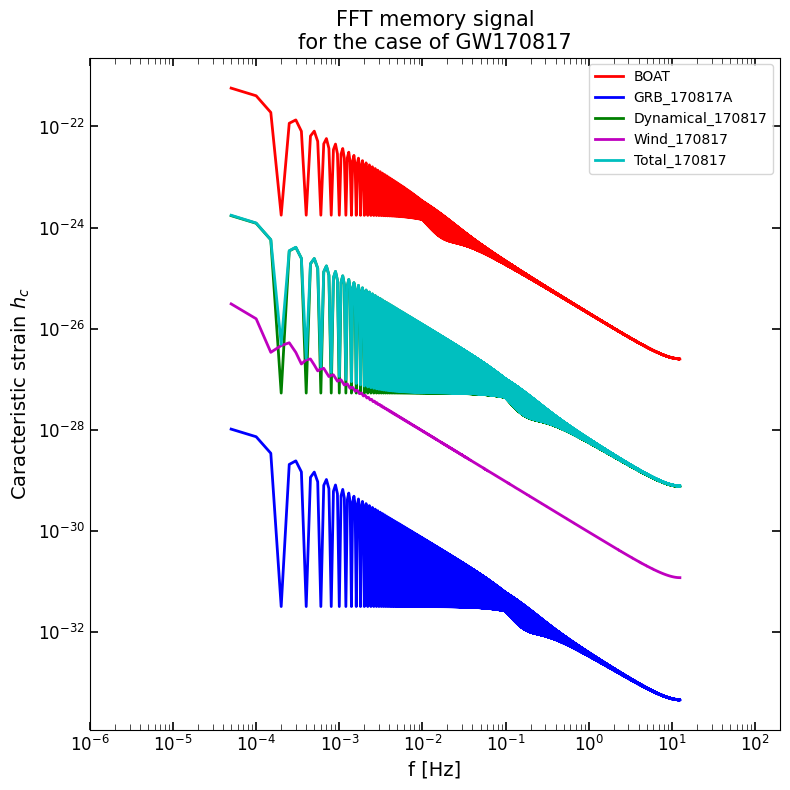

In [19]:
# FFT plot
h_list = [h_BOAT, h_170817_grb, h_170817_dyn, h_170817_wind, h_170817_total]
labels = ['BOAT', 'GRB_170817A', 'Dynamical_170817', 'Wind_170817', 'Total_170817']
up.memory_fft_phenom(t, h_list, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817')


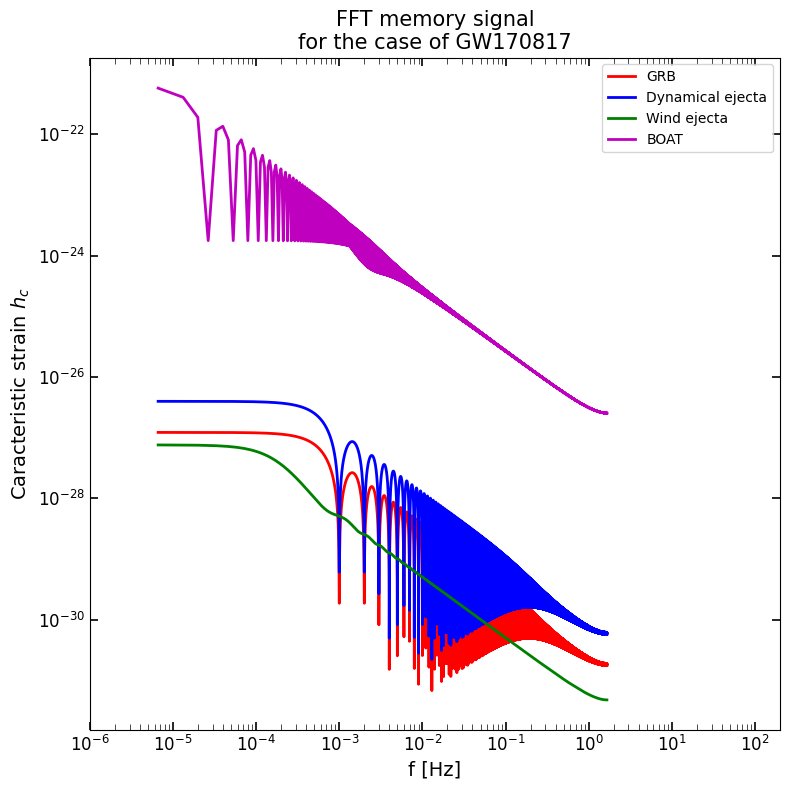

In [20]:
# Let's generate different GRB memory and dynamical/wind ejecta memory

t = np.linspace(-1., 150., 500000) * 1e3  # ms

E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000  
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 100  * 1e6  
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3


h_grb = up.phenom_memory_GRB(
    t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=False)
h_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, r, start_dyn, model='exponential')
h_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_ms, r, start_wind, model='exponential')

# FFT plot
h_list = [h_grb, h_dyn, h_wind, h_BOAT]
labels = ['GRB', 'Dynamical ejecta', 'Wind ejecta', 'BOAT']
up.memory_fft_phenom(t, h_list, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817')



Now applying a window

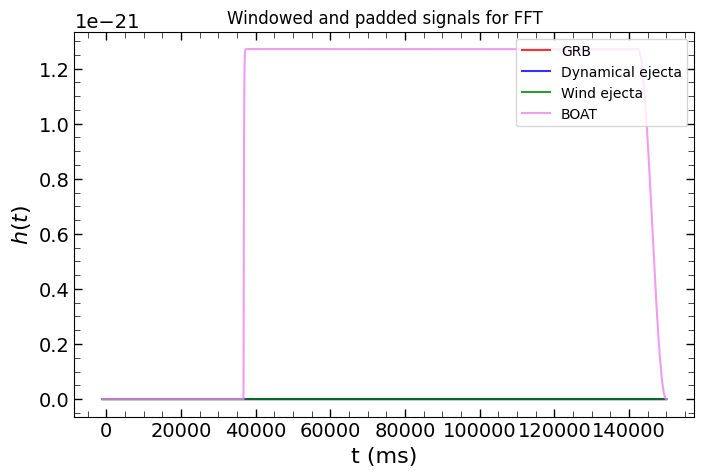

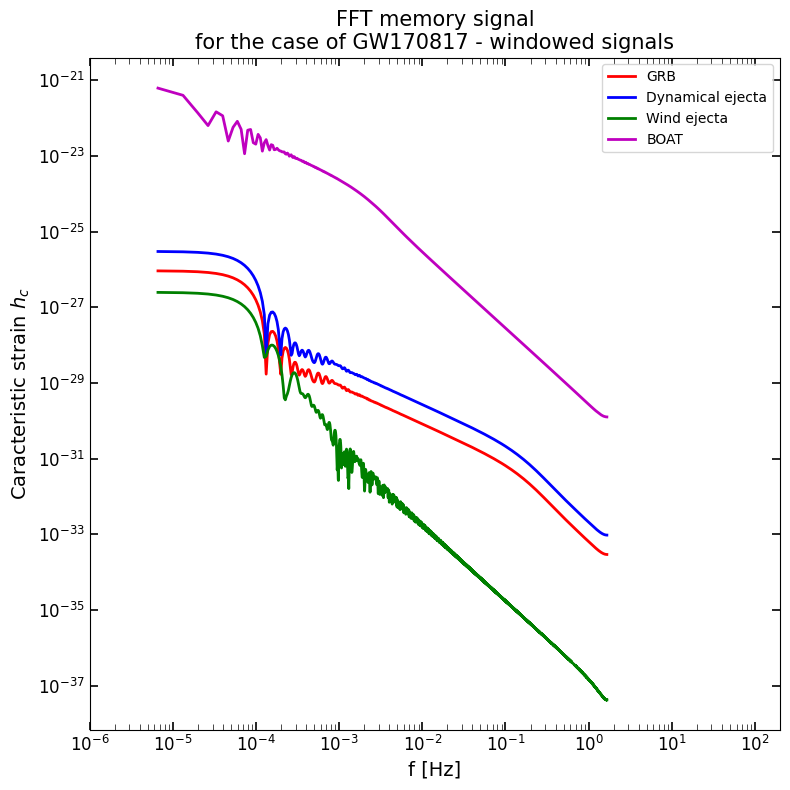

In [21]:
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
plt.figure(figsize=(8, 5))
for idx, h in enumerate(h_list):
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)
    plt.plot(t, h_w, label=labels[idx],c = colors[idx], alpha=0.8)
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("Windowed and padded signals for FFT")
plt.legend(loc= 'upper right')
plt.show()

up.memory_fft_phenom(t, h_windowed, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817 - windowed signals')


LISA sensitivity curve found on https://github.com/eXtremeGravityInstitute/LISA_Sensitivity and associated paper https://arxiv.org/pdf/1803.01944

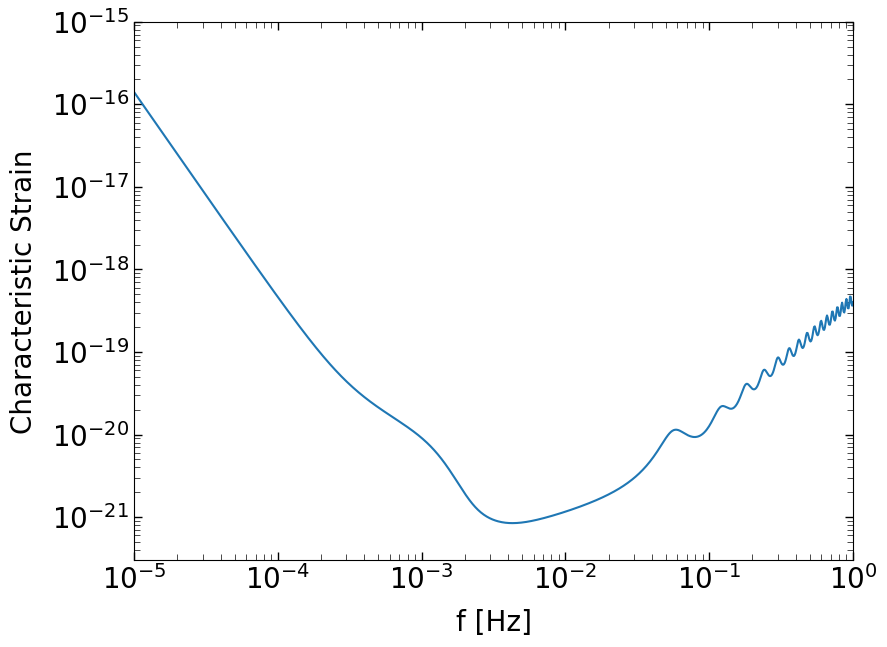

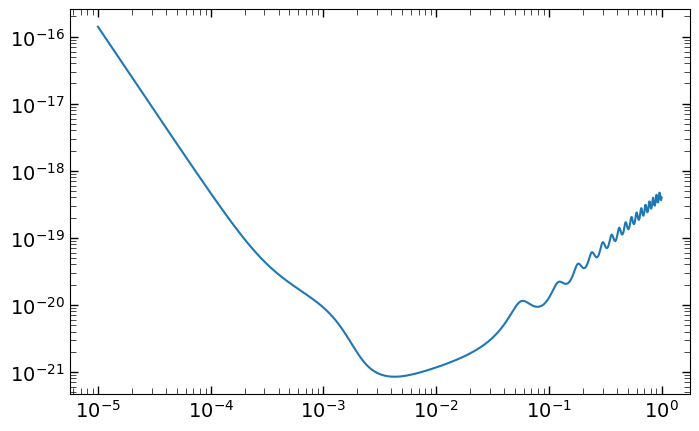

In [22]:
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e0), 1000)
Sn = lisa.Sn(f)
# Plot with the function from LISA module
li.PlotSensitivityCurve(f, Sn)
# Or we can do it ourselves - The same way as in the LISA.py
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f, np.sqrt(f*Sn))

Now we add the sensitivity curve and check if the memory signal is above the sensitivity curve of LISA. for the case of 170817

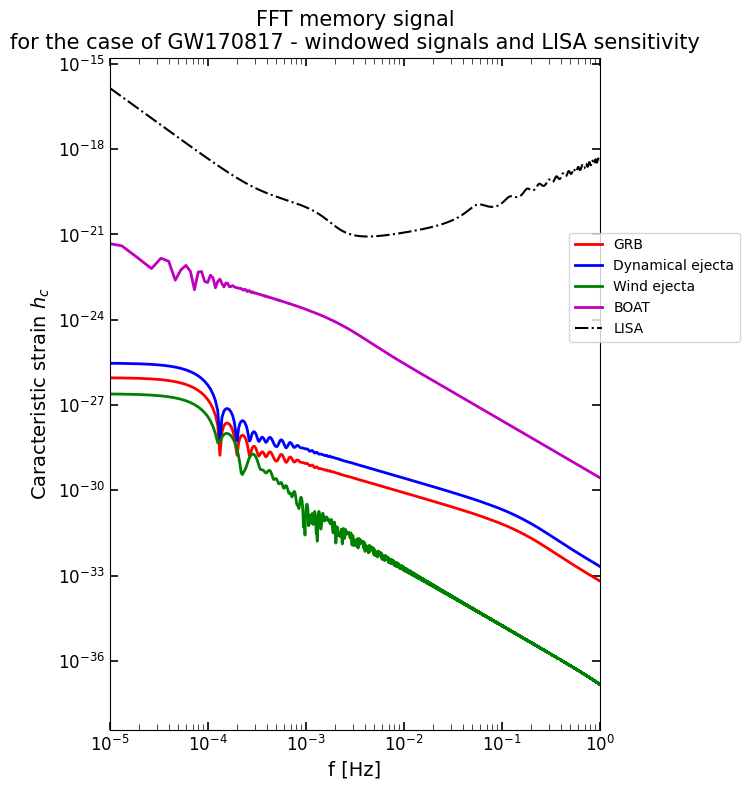

In [23]:
# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
fig.tight_layout()
fig.savefig(out_dir + "fft_memory_phenom_with_LISA.png")
plt.show()

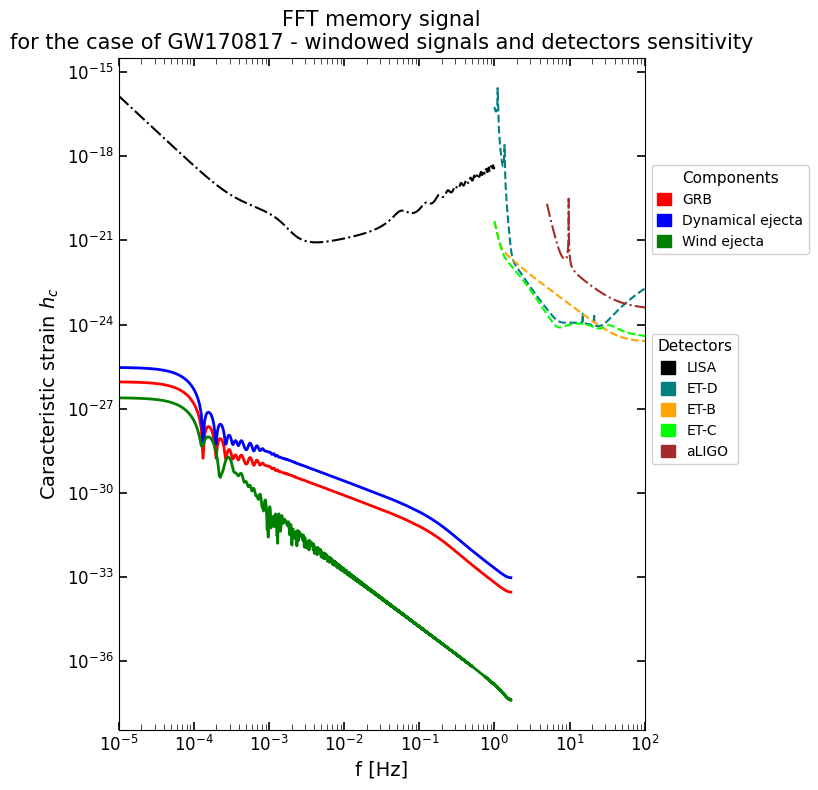

In [24]:
h_list = [h_grb, h_dyn, h_wind]
labels = ['GRB', 'Dynamical ejecta', 'Wind ejecta', 'LISA sensitivity']


# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and detectors sensitivity',
    return_fig=True
)
# ---
# HERE IT IS NEW 
# ---
# Remove the legend to make a new one
ax.get_legend().remove()

# handles for the components represented by a square in the legend
import matplotlib.patches as mpatches

# Créer les handles pour les composantes avec des carrés (patches)
component_handles = [
    mpatches.Patch(color='r', label='GRB'),
    mpatches.Patch(color='b', label='Dynamical ejecta'),
    mpatches.Patch(color='g', label='Wind ejecta')
]

# LISA
ax.loglog(f, np.sqrt(f*Sn), color='k', linestyle='-.', linewidth=1.5)

# ET sensitivity curves for 3 configurations
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}
et_colors = {'ET-D': 'teal', 'ET-B': 'orange', 'ET-C': 'lime'}
for label, data in et_sensitivities.items():
    ax.loglog(data[:, 0], data[:, 1], linestyle='--', color=et_colors[label], linewidth=1.5)

# aLIGO sensitivity curve
aligo_sensitivity = np.loadtxt('aLIGO_sensi.txt')
ax.loglog(aligo_sensitivity[:, 0], aligo_sensitivity[:, 1], linestyle='-.', color='brown', linewidth=1.5)

# handles for the detectors
detector_handles = [
    mpatches.Patch(color='k', label='LISA'),
    mpatches.Patch(color='teal', label='ET-D'),
    mpatches.Patch(color='orange', label='ET-B'),
    mpatches.Patch(color='lime', label='ET-C'),
    mpatches.Patch(color='brown', label='aLIGO')
]
# First one for the components

# Second for the detectors
legend1 = ax.legend(handles=detector_handles, loc='upper left',
                   bbox_to_anchor=(1., 0.6), title='Detectors',
                   fontsize=10, title_fontsize=11, framealpha=0.9,
                    handlelength=1.0, handleheight=1.0)

ax.add_artist(legend1)

legend2 = ax.legend(handles=component_handles, loc='upper left', 
                   bbox_to_anchor=(1., 0.85), title='Components',
                   fontsize=10, title_fontsize=11, framealpha=0.9,
                    handlelength=1.0, handleheight=1.0)
ax.set_xlim(1e-5, 1e2)
fig.tight_layout()
fig.savefig(out_dir + "fft_memory_phenom_with_LISA_ET_aLIGO.png")
plt.show()

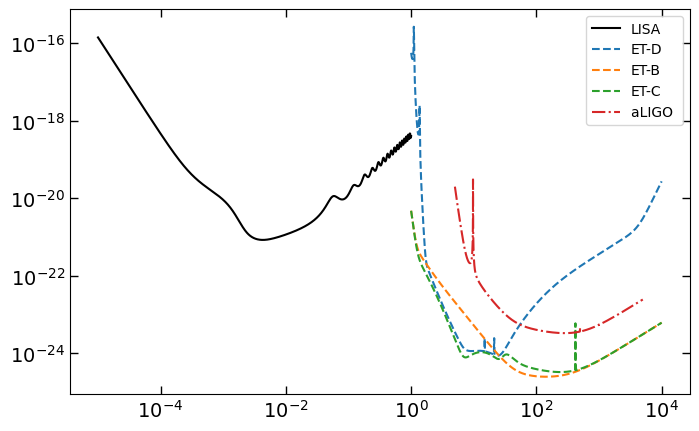

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k')
# ET sensitivity curves for 3 configurations
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}
for label, data in et_sensitivities.items():
    ax.loglog(data[:, 0], data[:, 1], label=label, linestyle='--')
# aLIGO sensitivity curve
aligo_sensitivity = np.loadtxt('aLIGO_sensi.txt')
ax.loglog(aligo_sensitivity[:, 0], aligo_sensitivity[:, 1], label='aLIGO ', linestyle='-.')
ax.legend(loc='upper right')

plt.show()

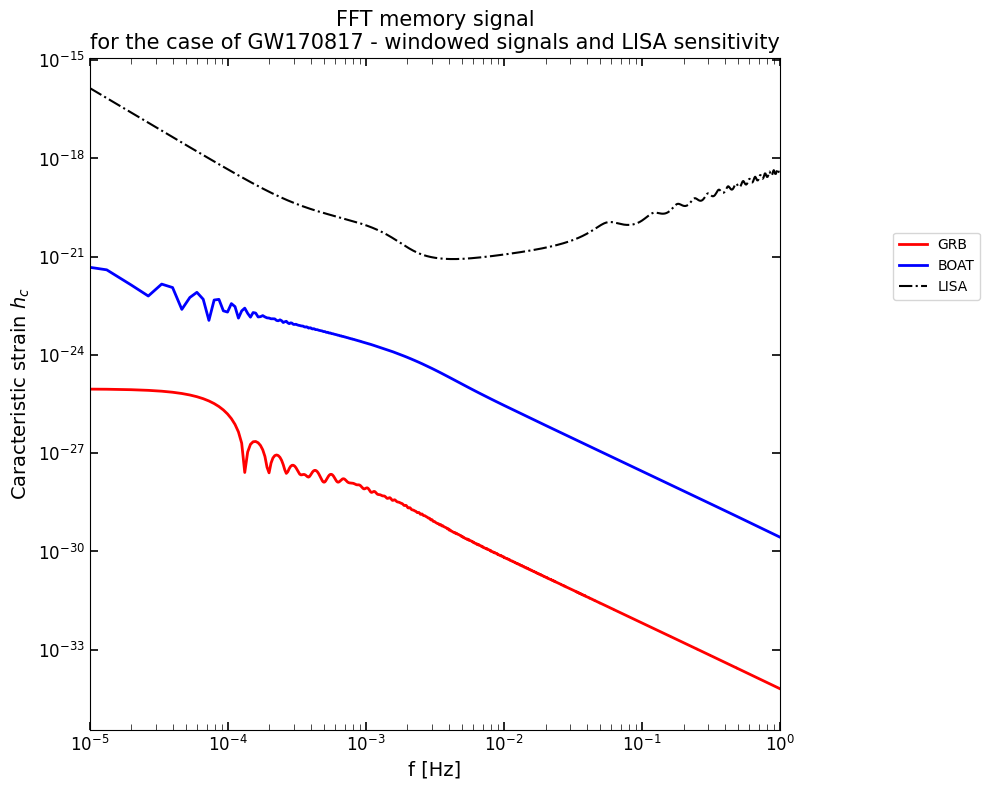

In [26]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms

E_j = 1e51  # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  
beta = 0.99  
tau_grb_ms = 100  # ms
start_grb, end_grb = 0, 30e3 #end at 30s 

h_grb = up.phenom_memory_GRB(t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=False)

h_list = [h_grb, h_BOAT]
labels = ['GRB', 'BOAT']


# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
plt.show()

Try to reproduce plots of https://arxiv.org/pdf/gr-qc/0405067

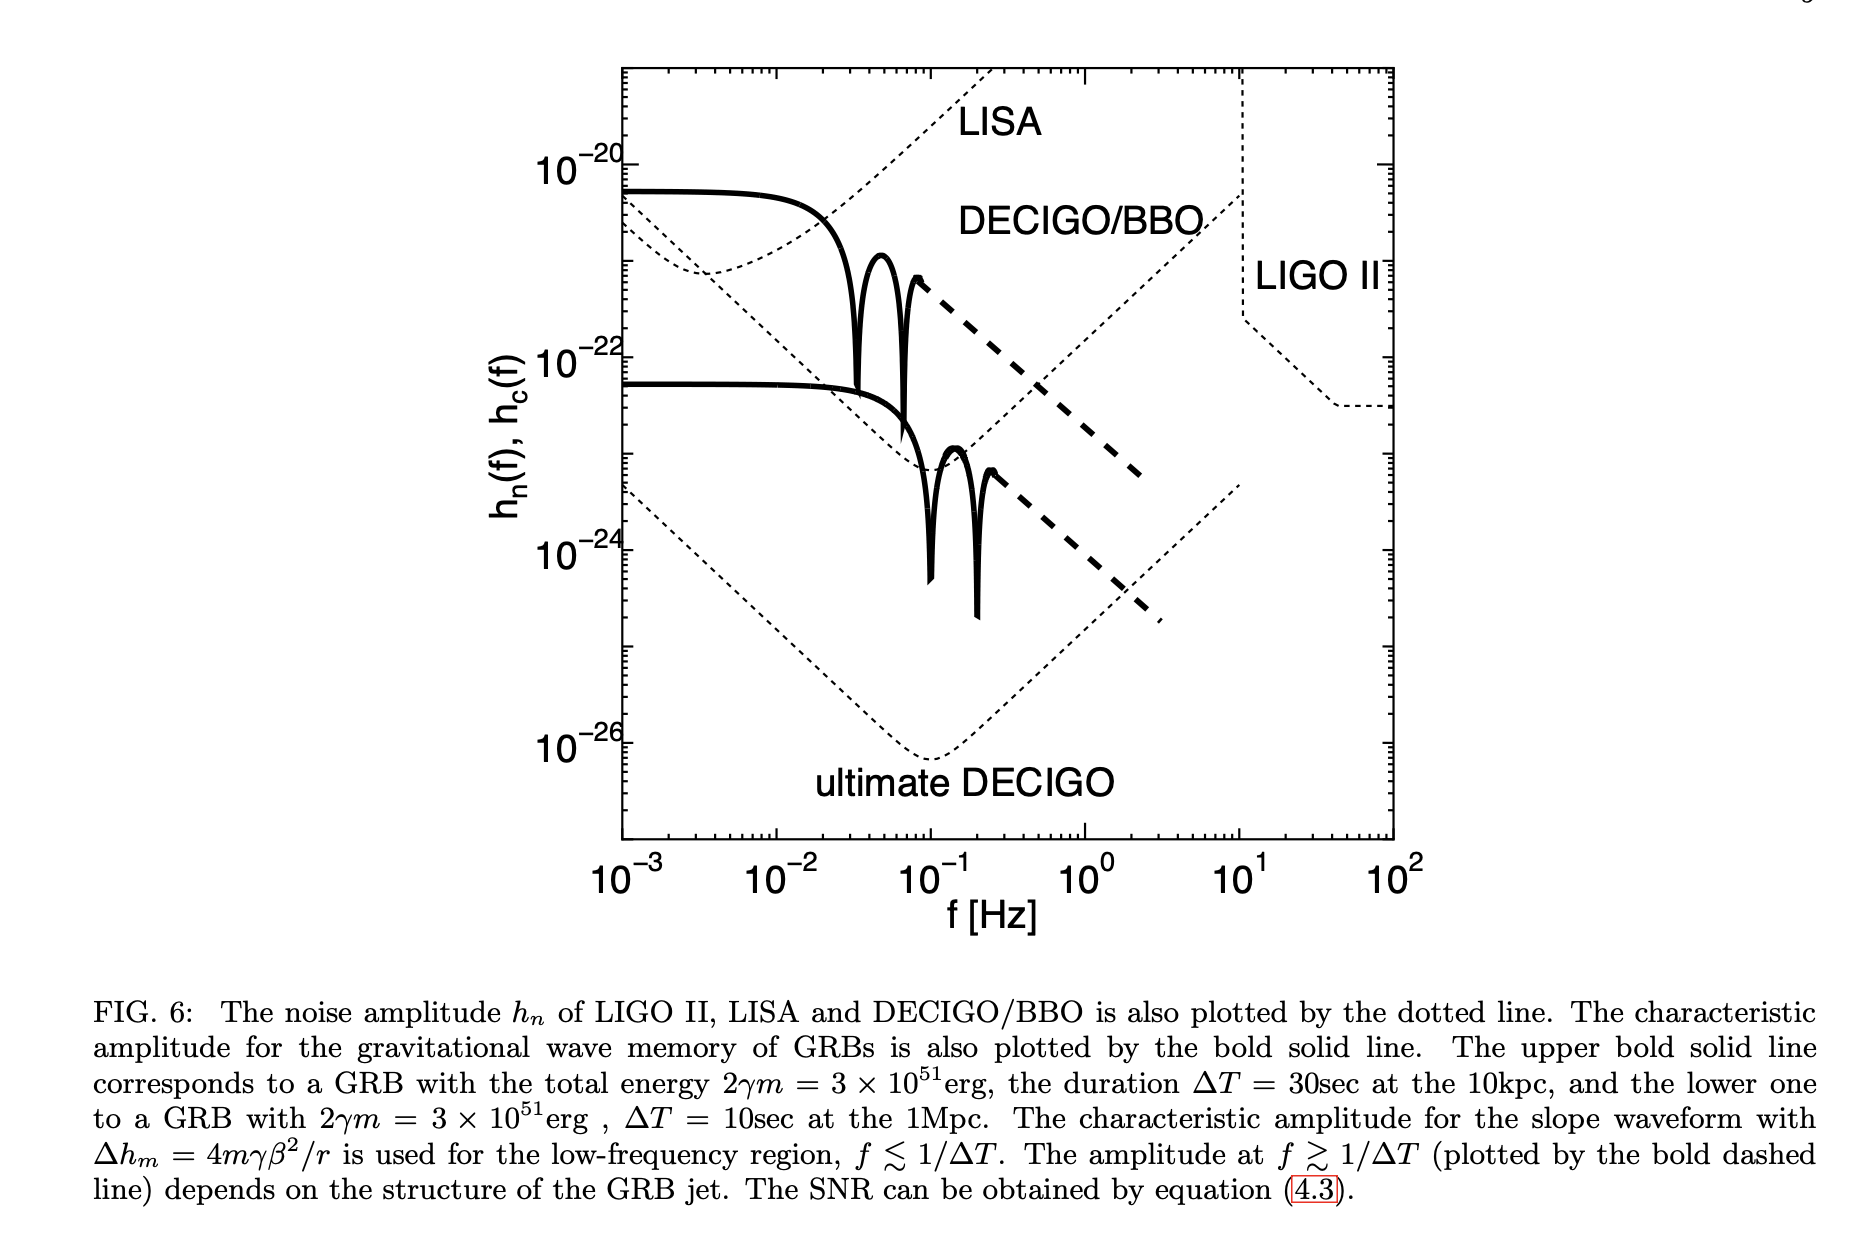

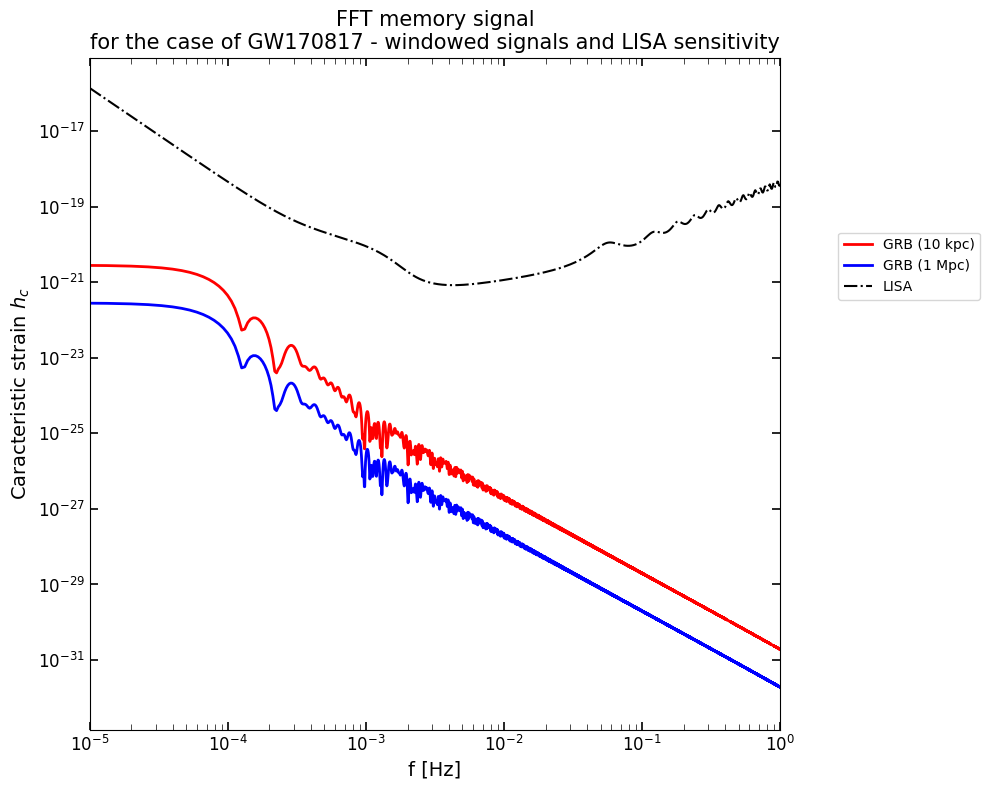

In [27]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms
theta = np.deg2rad(30)
h_grb_1 = up.phenom_memory_GRB(t, 3e51, beta, theta, 10e3, 1e3, start_grb, 30e3, model='exponential', plot=False) # 10 kpc case
h_grb_2 = up.phenom_memory_GRB(t, 3e52, beta, theta, 1e6, 1e3, start_grb, 10e3, model='exponential', plot=False) # 1 Mpc case

h_list = [h_grb_1, h_grb_2]
labels = ['GRB (10 kpc)', 'GRB (1 Mpc)']
# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g']
for idx, h in enumerate(h_list): 
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)
    
# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')

ax.tick_params(axis='both', labelsize=12, which='both', direction='in', top=True, right=True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
plt.show()

## Test of a new formula for the FFT of the memory signal based on formula (4.2) provided by https://arxiv.org/pdf/gr-qc/0405067

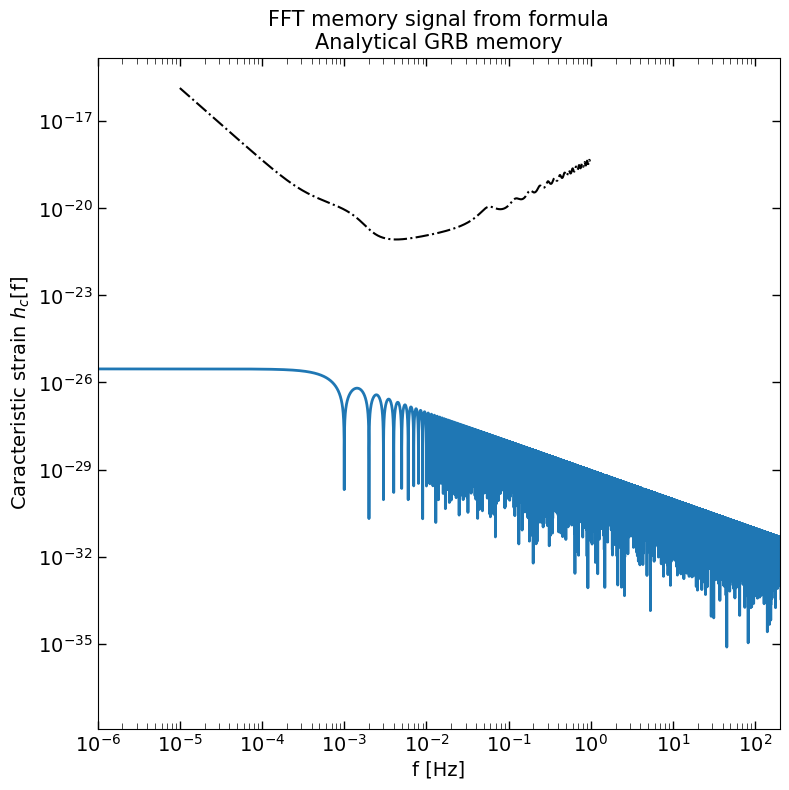

In [28]:
E_j = 1e50   
beta = 0.99
theta = np.deg2rad(30)
r = 100 * 1e6 # 100 Mpc
delta_h_grb = up.delta_h_GRB(E_j, beta, theta, r)
tau_grb = 1e3  # ms
_,_=up.memory_fft_formula(
    delta_h_grb, tau_grb, plot=True, show=True, add_info_title='Analytical GRB memory', LISA= True)


Now we can compare with my method for the 2 cases mentioned above

<Figure size 800x800 with 0 Axes>

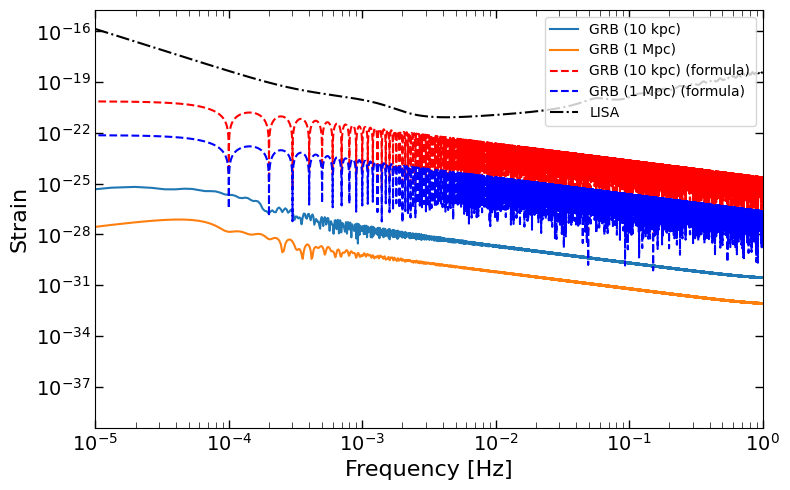

In [29]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms
theta = np.deg2rad(60)
E_1, E_2 = 3e51, 3e51
beta = 0.99
tau_grb_ms = 10e3
r_1, r_2 = 10e3, 1e6
start_grb = 0
end_1, end_2 = 30e3, 10e3
h_list =[]
# Compute the memory amplitude for both cases
delta_h_1 = up.delta_h_GRB(E_1, beta, theta, r_1)
delta_h_2 = up.delta_h_GRB(E_2, beta, theta, r_2)

# Compute GRB memory signals for two cases
h_grb_1 = up.phenom_memory_GRB(t, E_1, beta, theta, r_1, end_1, start_grb, end_1, model='exponential', plot=False)
h_grb_2 = up.phenom_memory_GRB(t, E_2, beta, theta, r_2, end_2, start_grb, end_2, model='exponential', plot=False)

# Apply Tukey window
h_windowed = [
    using.apply_window(h_grb_1, window_type='tukey', alpha=0.1),
    using.apply_window(h_grb_2, window_type='tukey', alpha=0.1)
]
labels = ['GRB (10 kpc)', 'GRB (1 Mpc)']
colors = ['r', 'b']

# Compute FFT for windowed signals
results = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=False, show=False, return_fft=True
)

# Analytical FFTs
freq_1, fft_1 = up.memory_fft_formula(delta_h_1, tau_grb_ms, plot=False, show=False)
freq_2, fft_2 = up.memory_fft_formula(delta_h_2, tau_grb_ms, plot=False, show=False)

# Final plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (freq, fft) in enumerate(results):
    plt.plot(freq, fft, label=labels[i])
ax.loglog(freq_1, np.abs(fft_1), label=f'{labels[0]} (formula)', color=colors[0], linestyle='--')
ax.loglog(freq_2, np.abs(fft_2), label=f'{labels[1]} (formula)', color=colors[1], linestyle='--')
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax.legend(loc='upper right')
ax.set_xlim(1e-5, 1)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain')
plt.tight_layout()
plt.show()

### Analytical fft only for the GRB memory

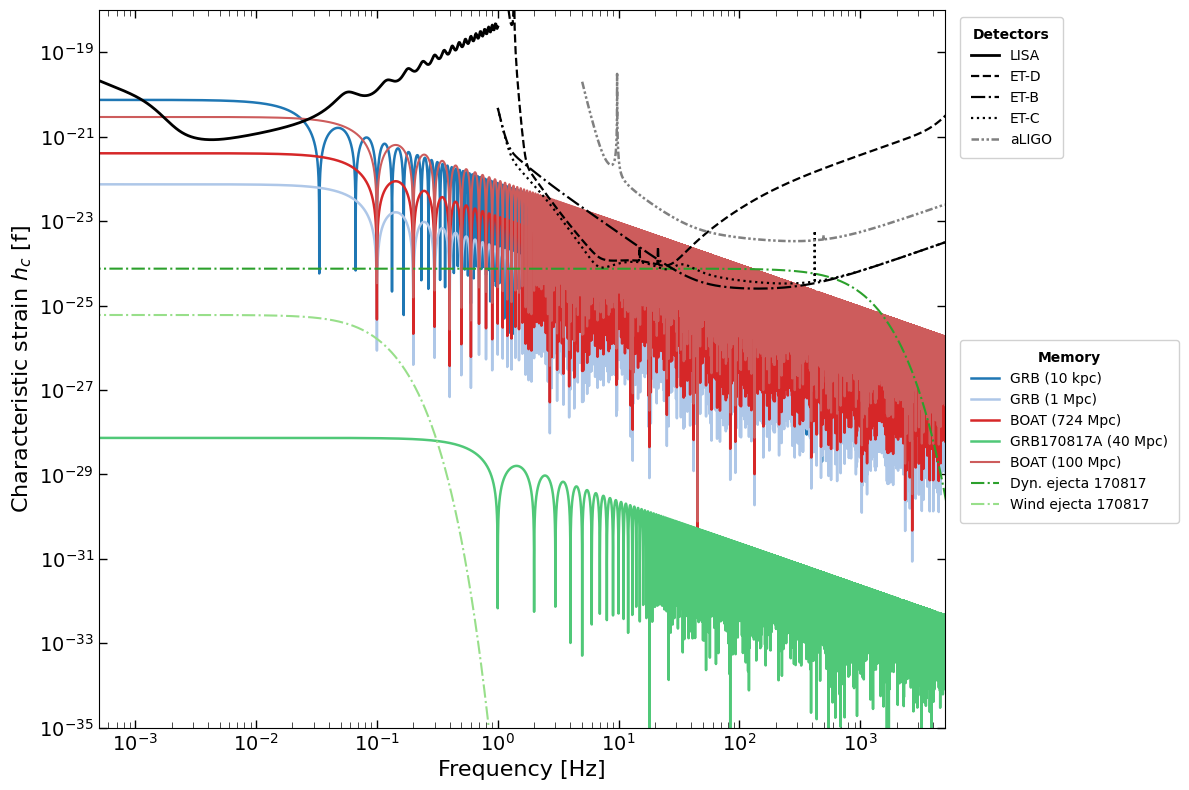

In [30]:
delta_h_BOAT = up.delta_h_GRB(E_j_boat, beta_boat, np.deg2rad(30), r_boat)
delta_h_BOAT_100MPC = up.delta_h_GRB(E_j_boat, beta_boat, np.deg2rad(30), 100*1e6)
delta_h_170817 = up.delta_h_GRB(E_j_170817, beta_170817, theta_170817, r_170817)
delta_h_170817_dyn = up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r_170817)
delta_h_170817_wind = up.delta_h_ejecta(M_ej_wind, v_ej_wind, r_170817)
delta_h_all = [delta_h_1, delta_h_2, delta_h_BOAT, delta_h_170817, delta_h_BOAT_100MPC, delta_h_170817_dyn, delta_h_170817_wind]

labels = ['GRB (10 kpc)', 'GRB (1 Mpc)', 'BOAT (724 Mpc)', 'GRB170817A (40 Mpc)', 'BOAT (100 Mpc)', 'Dyn. ejecta 170817', 'Wind ejecta 170817']
tau_grbs = [30, 10, 10, 1, 10, 1e-3, 10]

# --- Signal colors: grouped by physical origin ---
signal_colors = [
    '#1f77b4',  # GRB 10 kpc  - blue
    '#aec7e8',  # GRB 1 Mpc   - light blue
    '#d62728',  # BOAT        - red
    '#50C878', # GRB170817A - lime green
    '#CD5C5C',  # BOAT 100Mpc 
    '#2ca02c',  # Dyn ejecta  - green
    '#98df8a',  # Wind ejecta - light green
]
ls_list = ['-', '-', '-', '-', '-', '-.', '-.']
lw_list = [1.8, 1.8, 1.8, 1.8, 1.5, 1.5, 1.5]

freq_fft_list = []
i=0
for delta_h, tau_grb in zip(delta_h_all, tau_grbs):
    if i <5:
        f_test, fft = up.memory_fft_formula(delta_h, tau_grb, plot=False, show=False, LISA=False)
        freq_fft_list.append((f_test, np.abs(fft)))
    else:
        f_test, fft = up.fft_exp_model(delta_h, tau_grb)
        freq_fft_list.append((f_test, 2*f_test*np.abs(fft)))
    i+=1

# --- Detector sensitivity curves ---
det_styles = {
    'LISA':  {'color': 'black', 'ls': '-',   'lw': 2.0},
    'ET-D':  {'color': 'black', 'ls': '--',  'lw': 1.6},
    'ET-B':  {'color': 'black', 'ls': '-.',  'lw': 1.6},
    'ET-C':  {'color': 'black', 'ls': ':',   'lw': 1.6},
    'aLIGO': {'color': 'grey', 'ls': (0, (3, 1, 1, 1, 1, 1)), 'lw': 1.8},  # dash-dot-dot
}

fig, ax = plt.subplots(figsize=(12,8))

# --- Plot signals ---
signal_handles = []
for i, (f_test, fft) in enumerate(freq_fft_list):
    line, = ax.loglog(f_test, fft,
                      color=signal_colors[i],
                      linestyle=ls_list[i],
                      linewidth=lw_list[i],
                      label=labels[i])
    signal_handles.append(line)

# --- Plot detectors ---
det_handles = []

# LISA
line, = ax.loglog(f, np.sqrt(f * Sn),
                  color=det_styles['LISA']['color'],
                  linestyle=det_styles['LISA']['ls'],
                  linewidth=det_styles['LISA']['lw'],
                  label='LISA')
det_handles.append(line)

# ET configurations
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt'),
}
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    line, = ax.loglog(data[:, 0], data[:, 1],
                      color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                      label=det_label)
    det_handles.append(line)

# aLIGO
aligo_sensitivity = np.loadtxt('aLIGO_sensi.txt')
s = det_styles['aLIGO']
line, = ax.loglog(aligo_sensitivity[:, 0], aligo_sensitivity[:, 1],
                  color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                  label='aLIGO')
det_handles.append(line)

# Two separate legends 
legend_det = ax.legend(
    handles=det_handles,
    title='Detectors',
    title_fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    framealpha=0.9,
    borderpad=0.8,
)
legend_det.get_title().set_fontweight('bold')

# GW memory signals legend → en bas
legend_signals = ax.legend(
    handles=signal_handles,
    title='Memory',
    title_fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.01, 0.55),
    frameon=True,
    framealpha=0.9,
    borderpad=0.8,
)
legend_signals.get_title().set_fontweight('bold')
ax.add_artist(legend_det)  # re-add la première après le second appel


# --- Axes styling ---
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'Characteristic strain $h_c$ [f]')
ax.set_xlim(5e-4, 5e3)
ax.set_ylim(1e-35, 1e-18)



plt.tight_layout()
plt.savefig(out_dir + "fft_memory_phenom_all_cases_with_LISA_analytical_f.png", bbox_inches='tight', dpi=150)
plt.show()

/tmp/ipykernel_1138/1297526371.py:3: RuntimeWarning: invalid value encountered in divide
  y = (np.sin(x)**2 / (1 - beta * np.cos(x)))


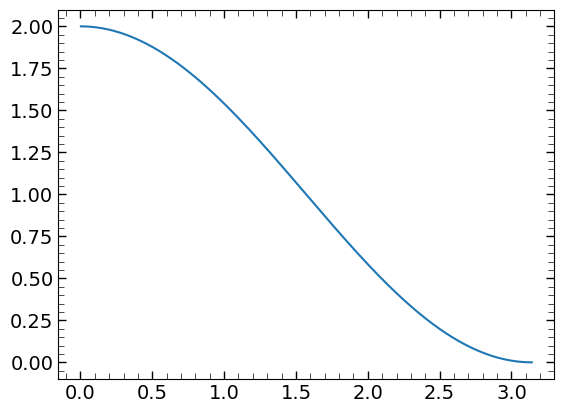

In [31]:
x = np.linspace(0,np.pi, 1000)
beta = 1
y = (np.sin(x)**2 / (1 - beta * np.cos(x)))
plt.plot(x, y)


Figure to depict the impact of the factors on the memory signal and its FFT

In [32]:
t = np.linspace(-1., 150., 500000) 
beta = 1
theta = np.deg2rad(30) # viewing angle of 30 degrees with respect to the jet axis
duration = 10 # s
E_typical = 1e50 # erg
r_typical = 1e6 # 1 Mpc
tau_grb = 1e-3 # short timescale as mentionned by Lopez (so a caracteristic frequency of 1 kHz ~ LIGO band)

h_typical = up.phenom_memory_GRB(t, E_typical, beta, theta, r_typical, 1e3, 0, 30e3, model='exponential', plot=False)

In [33]:
print(f'{1/(2e3):.1e}')

5.0e-04


Afterglow parameters: 1e+49 200.0 0.17453292519943295 1000000.0 0.99 1e+51 2000.0
delta_h_min_aft 2.4052619307957897e-25 delta_h_max_aft 2.40526193079579e-22


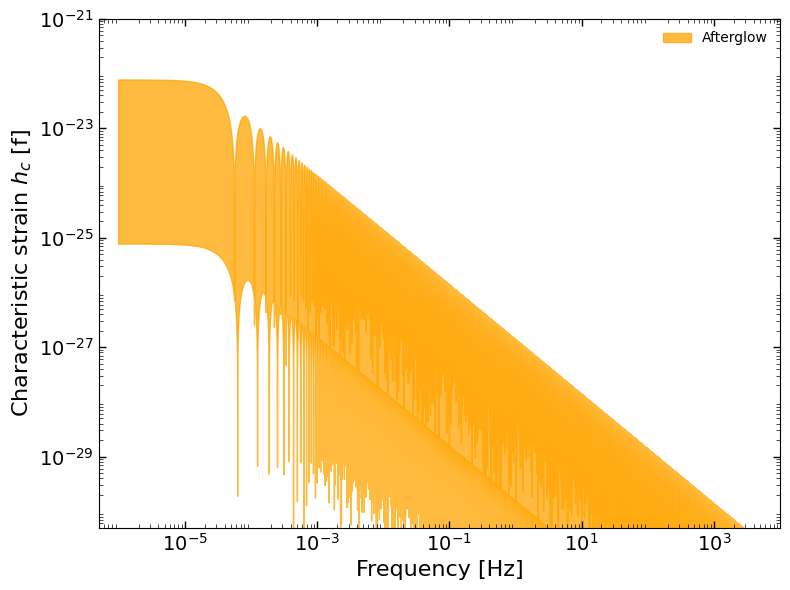

In [34]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

r = 1 * 1e6  # 1 Mpc
beta = 0.99
theta_v_jet = 2 * np.deg2rad(5) # Twice opnenig angle 
theta_opening_jet = np.deg2rad(5)

# Paramètres min/max pour chaque composant
E_jet_min, E_jet_max = 1e50, 1e52
tau_GRB_min, tau_GRB_max = 1e-3, 10e-3

P_aft_min, P_aft_max = 1e49, 1e51
tau_aft_min, tau_aft_max = 2e2, 2e3 # SGRB - LGRB afterglow timescales

M_dyn_min, M_dyn_max = 0.1e-2, 1e-2
v_dyn_min, v_dyn_max = 0.1, 0.3
tau_dyn_min, tau_dyn_max = 1e-3, 10e-3

M_wind_min, M_wind_max = 0.01, 0.1
v_wind_min, v_wind_max = 0.1, 0.2
tau_wind_min, tau_wind_max = 1e1, 1e2

# FFT pour chaque composant
# GRB 
delta_h_min = up.delta_h_GRB(E_jet_min, beta, theta_v_jet, r)
delta_h_max = up.delta_h_GRB(E_jet_max, beta, theta_v_jet, r)
fft_min = up.memory_fft_formula(delta_h_min, tau_GRB_min, plot=False, show=False, LISA=False)
fft_max = up.memory_fft_formula(delta_h_max, tau_GRB_max, plot=False, show=False, LISA=False)

# Afterglow 
print("Afterglow parameters:", P_aft_min, tau_aft_min, theta_v_jet, r, beta, P_aft_max, tau_aft_max)
delta_h_min_aft = up.memory_afterglow_injection(P_aft_min, tau_aft_min, theta_v_jet, theta_opening_jet, r, beta)
delta_h_max_aft = up.memory_afterglow_injection(P_aft_max, tau_aft_max, theta_v_jet, theta_opening_jet, r, beta)
print("delta_h_min_aft", delta_h_min_aft, "delta_h_max_aft", delta_h_max_aft)
fft_min_aft = up.new_fft(0, delta_h_min_aft, tau_aft_min, theta_v_jet)
fft_max_aft = up.new_fft(0, delta_h_max_aft, tau_aft_max, theta_v_jet)

# Dynamical ejecta
delta_h_min_dyn = up.delta_h_ejecta(M_dyn_min, v_dyn_min, r)
delta_h_max_dyn = up.delta_h_ejecta(M_dyn_max, v_dyn_max, r)
fft_min_dyn = up.memory_fft_formula(delta_h_min_dyn, tau_dyn_min, plot=False, show=False, LISA=False)
fft_max_dyn = up.memory_fft_formula(delta_h_max_dyn, tau_dyn_max, plot=False, show=False, LISA=False)

# Wind ejecta
delta_h_min_wind = up.delta_h_ejecta(M_wind_min, v_wind_min, r)
delta_h_max_wind = up.delta_h_ejecta(M_wind_max, v_wind_max, r)
fft_min_wind = up.memory_fft_formula(delta_h_min_wind, tau_wind_min, plot=False, show=False, LISA=False)
fft_max_wind = up.memory_fft_formula(delta_h_max_wind, tau_wind_max, plot=False, show=False, LISA=False)

# Sort by max(fft_max) to have the most important component on top in the plot
components = [
    {"GRB":  fft_max},
    {"Afterglow": fft_max_aft},
    {"Dynamical ejecta": fft_max_dyn},
    {"Wind ejecta": fft_max_wind}
]
# Sort the components by the maximum value of their fft_max to ensure the most important component is plotted on top
components.sort(key=lambda x: list(x.values())[0][1].max(), reverse=True)
zorder_dict = {list(comp.keys())[0]: idx for idx, comp in enumerate(components)}

fig, ax = plt.subplots(figsize=(8, 6))

# ax.fill_between(fft_min[0], fft_min[1], fft_max[1], color='red', alpha=0.75, label='GRB', zorder=zorder_dict['GRB'])
ax.fill_between(fft_min_aft[0], 2*fft_min_aft[0] * fft_min_aft[1], 2*fft_min_aft[0] * fft_max_aft[1], color='orange', alpha=0.75, label='Afterglow', zorder=zorder_dict['Afterglow'])
# ax.fill_between(fft_min_dyn[0], fft_min_dyn[1], fft_max_dyn[1], color='blue', alpha=0.75, label='Dynamical ejecta', zorder=zorder_dict['Dynamical ejecta'])
# ax.fill_between(fft_min_wind[0], fft_min_wind[1], fft_max_wind[1], color='green', alpha=0.75, label='Wind ejecta', zorder=zorder_dict['Wind ejecta'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'Characteristic strain $h_c$ [f]')
ax.legend(loc='upper right', frameon=False)

# Minor ticks for log axes
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(axis='both', which='major', direction='in', length=5, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5, top=True, right=True)

ax.set_xlim(5e-7, 1e4)
ax.set_ylim(5e-31, 1e-21)
plt.tight_layout()
plt.show()


In [35]:
def rectangular_fft(fft_max, tau, f):
    fft = np.zeros_like(f)
    mask_low = f < 1/tau
    mask_high = f >= 1/tau
    fft[mask_low] = fft_max
   
    fft[mask_high] = fft_max * (1/tau) / f[mask_high]
    return fft

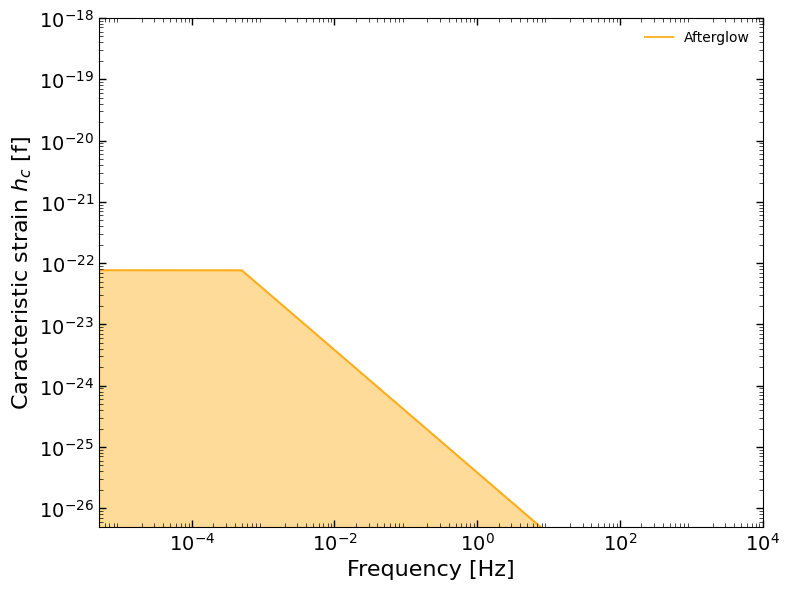

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(fft_max[0], rectangular_fft(max(fft_max[1]), tau_GRB_max, fft_max[0]), color='red', alpha=0.8, label='GRB', zorder = zorder_dict['GRB'])
# ax.fill_between(fft_max[0], 0, rectangular_fft(max(fft_max[1]), tau_GRB_max, fft_max[0]), color='red', alpha=0.4, zorder = zorder_dict['GRB'])

ax.plot(fft_min_aft[0], rectangular_fft(max( 2*fft_min_aft[0] * fft_max_aft[1]), tau_aft_max, fft_min_aft[0]), color='orange', alpha=0.8, label='Afterglow', zorder = zorder_dict['Afterglow'])
ax.fill_between(fft_min_aft[0], 0, rectangular_fft(max( 2*fft_min_aft[0] * fft_max_aft[1]), tau_aft_max, fft_min_aft[0]), color='orange', alpha=0.4, zorder = zorder_dict['Afterglow'])

# ax.plot(fft_min_dyn[0], rectangular_fft(max(fft_max_dyn[1]), tau_dyn_max, fft_min_dyn[0]), color='blue', alpha=0.8, label='Dynamical ejecta', zorder = zorder_dict['Dynamical ejecta'])
# ax.fill_between(fft_min_dyn[0], 0, rectangular_fft(max(fft_max_dyn[1]), tau_dyn_max, fft_min_dyn[0]), color='blue', alpha=0.4, zorder = zorder_dict['Dynamical ejecta'])

# ax.plot(fft_min_wind[0], rectangular_fft(max(fft_max_wind[1]), tau_wind_max, fft_min_wind[0]), color='green', alpha=0.8, label='Wind ejecta', zorder = zorder_dict['Wind ejecta'])
# ax.fill_between(fft_min_wind[0], 0, rectangular_fft(max(fft_max_wind[1]), tau_wind_max, fft_min_wind[0]), color='green', alpha=0.4, zorder = zorder_dict['Wind ejecta'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'Caracteristic strain $h_c$ [f]')
ax.legend(loc='upper right', frameon=False)

# Minor ticks for log axes
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(axis='both', which='major', direction='in', length=5, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5, top=True, right=True)

ax.set_xlim(5e-6, 1e4)
ax.set_ylim(5e-27, 1e-18)
plt.tight_layout()
plt.show()

To find the f_min, we have to know the total duration of the asssociated event. Thus the memory signal is not present for f < 1/T, where T is the total duration of the event. 

---

## Test of GRB + afterglow memory from https://arxiv.org/pdf/2301.12590

Initial memory amplitude from the GRB: 2.90e-23
Inverse of the rise time of the afterglow memory: 5.00e-03 Hz
Memory amplitude from the afterglow injection: 1.10e-26
Inverse of the rise time of the afterglow memory: 5.00e-03 Hz
Memory amplitude from the afterglow injection: 1.10e-25
Inverse of the rise time of the afterglow memory: 5.00e-03 Hz
Memory amplitude from the afterglow injection: 1.10e-24


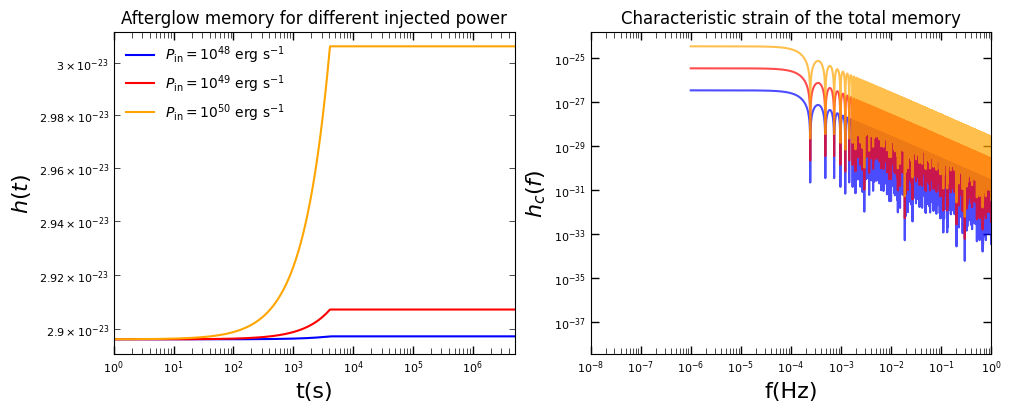

In [37]:
importlib.reload(up)
cases = [
    (r'$P_\mathrm{in} = 10^{48}$ erg s$^{-1}$', 1e48, 'blue'),
    (r'$P_\mathrm{in} = 10^{49}$ erg s$^{-1}$', 1e49, 'red'),
    (r'$P_\mathrm{in} = 10^{50}$ erg s$^{-1}$', 1e50, 'orange'),
]
# GRB memory 
E_j = 1e51 # <-- problem with the GRB amplitude : too high compare to other methods
theta_j = np.deg2rad(5) # jet opening angle
theta_v = np.deg2rad(2.5) # Viewing angle 
theta_ej = 2*theta_v
phi_ej = 0
beta = 0.99
r = 1 * 1e6 # 1 Mpc

h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
print(f"Initial memory amplitude from the GRB: {h_in:.2e}")
t = np.linspace(-1, 5e6, int(5e6)) # -1 s to 1e6 s
t_end = 2e2 # 200 s for SGRB
# Afterglow memory
fig, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for label, P_in, color in cases:
    # Waveform
    h_afterglow = up.memory_afterglow_injection(P_in, t_end, theta_ej, theta_j, r,  beta)
    print(f"Inverse of the rise time of the afterglow memory: {1/t_end:.2e} Hz")
    print(f"Memory amplitude from the afterglow injection: {h_afterglow:.2e}")
    h_t, t_m = up.memory_total_waveform(t, h_in, h_afterglow, t_end, theta_ej)
    ax_1.loglog(t, h_t, label=label, color=color)

    # FFT
    f, fft = up.new_fft(0, h_afterglow, t_end, theta_ej)
    ax_2.loglog(f, 2*f*np.abs(fft), label=label, color=color, alpha = 0.7) # Plot of the characteristic strain

ax_1.set_xlabel('t(s)')
#ax_1.hlines(h_in, t[0], t[-1], label='Initial memory', color='k', linestyle='--')
#ax_1.vlines(t_m, h_in, h_t[-1], color='grey', linestyle= 'dotted', alpha=0.7, label=f'{t_m:.2e}  end time') 
ax_1.set_ylabel(r'$h(t)$')
ax_1.set_title('Afterglow memory for different injected power')

ax_1.set_xlim(1e0, t[-1])
ax_1.legend(loc = 'upper left', frameon= False)
ax_1.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

ax_2.set_xlabel('f(Hz)')
ax_2.set_ylabel(r'$h_c(f)$')
ax_2.set_title('Characteristic strain of the total memory')
ax_2.set_xlim(1e-8, 1e0)

ax_2.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

plt.show()


In [38]:
# GRB memory 
E_j = 1e51
theta_j = np.deg2rad(5) # jet opening angle
theta_v = np.deg2rad(5) # Viewing angle 
theta_ej = 2*theta_v
phi_ej = 0
beta = 0.99
r = 1 * 1e6 # 1 Mpc

h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)

# Afterglow memory
P_in = 1e50
t_end = 2e2 # 200 s for SGRB
h_afterglow = up.memory_afterglow_injection(P_in, t_end, theta_ej, theta_j, r,  beta)

print(f"Initial memory amplitude: {h_in:.2e}, Afterglow memory amplitude: {h_afterglow:.2e}, Ratio: {h_in/h_afterglow:.2f}")

Initial memory amplitude: 6.32e-23, Afterglow memory amplitude: 2.41e-24, Ratio: 26.28


Test BOAT & GW170817

1.580204402164714e-28 6.013154826989475e-26


/home/pycbc/work/Memory_Lopez/LISA.py:105: RuntimeWarning: overflow encountered in exp
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))
/home/pycbc/work/Memory_Lopez/LISA.py:105: RuntimeWarning: invalid value encountered in multiply
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))
/tmp/ipykernel_1138/1237998436.py:107: RuntimeWarning: invalid value encountered in sqrt
  ax3.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')


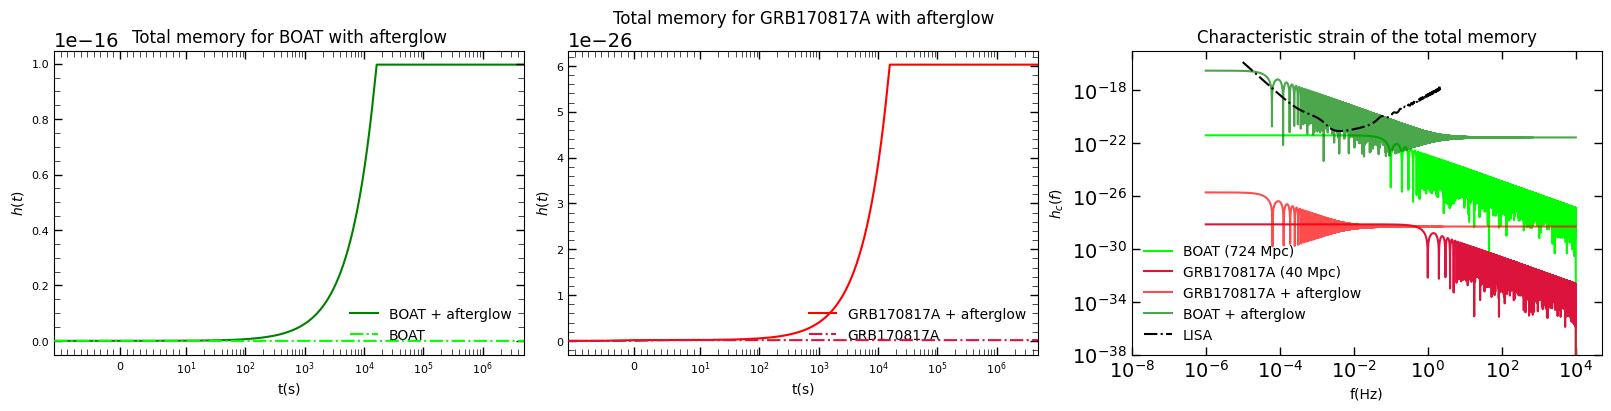

In [39]:
from matplotlib.ticker import  SymmetricalLogLocator
t = np.linspace(-10, 5e6, int(1e6)) # -1 s to 5e6 s
# BOAT case
prop_BOAT = {
    'E_j': 1e55,   # brightest object
    'theta_j': np.deg2rad(5), # jet opening angle
    'theta_v': np.deg2rad(5), # Viewing angle
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 724 * 1e6, # BOAT
    'tau_grb_s': 10e-3, # s rise time of the GRB
    'end_grb_s': 600, # end GRB at 600s
    'P_in': 1e60, # Assumed a very high injected power for the afterglow, since we don't have any information about it for BOAT -> clear sign on the fft
}

E_j_boat = prop_BOAT['E_j']
theta_j = prop_BOAT['theta_j']
theta_v = prop_BOAT['theta_v']
theta_ej = prop_BOAT['theta_ej']
phi_ej = prop_BOAT['phi_ej']
beta = prop_BOAT['beta']
r_boat = prop_BOAT['r']
tau_grb_boat_s = prop_BOAT['tau_grb_s'] 
end_grb_boat = prop_BOAT['end_grb_s']
P_in = prop_BOAT['P_in']

h_t_BOAT_old = up.phenom_memory_GRB(
    t, E_j_boat, beta, theta_ej, r_boat, tau_grb_boat_s, 0, end_grb_boat, model='exponential', plot=False)

h_in_BOAT = up.memory_initial_acceleration_GRB(E_j_boat, theta_ej, phi_ej, r_boat, beta)
t_end_BOAT = 600 # 600s for BOAT
h_afterglow_BOAT = up.memory_afterglow_injection(P_in, t_end_BOAT, theta_ej, theta_j, r_boat,  beta)


h_tot_BOAT, _ = up.memory_total_waveform(t, h_in_BOAT, h_afterglow_BOAT, t_end_BOAT, theta_ej)

f_BOAT, fft_BOAT = up.new_fft(h_in_BOAT, h_afterglow_BOAT, t_end_BOAT, theta_ej)

# 170817 case
prop_170817 = {
    'E_j': 1e47,   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
    'theta_j': np.deg2rad(5), # jet opening angle
    'theta_v': np.deg2rad(5), # Viewing angle 
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 40 * 1e6, # 40 Mpc
    'tau_grb_170817_s': 1e-3, # s rise time of the GRB
    'end_grb_170817_s': 200, # end GRB at 200s
    'P_in': 1e52, # injected power for the afterglow
}

E_j_170817 = prop_170817['E_j']
theta_j = prop_170817['theta_j']
theta_v = prop_170817['theta_v']
theta_ej = prop_170817['theta_ej']
phi_ej = prop_170817['phi_ej']
beta = prop_170817['beta']
r_170817 = prop_170817['r']
tau_grb_170817_s = prop_170817['tau_grb_170817_s']
end_grb_170817 = prop_170817['end_grb_170817_s']
P_in = prop_170817['P_in']

h_t_170817_old = up.phenom_memory_GRB(
    t, E_j_170817, beta, theta_ej, r_170817, tau_grb_170817_s, 0, end_grb_170817, model='exponential', plot=False)

h_in_170817 = up.memory_initial_acceleration_GRB(E_j_170817, theta_ej, phi_ej, r_170817, beta)
t_end_170817 = 2 # 2s for 170817
h_afterglow_170817 = up.memory_afterglow_injection(P_in, t_end_170817, theta_ej, theta_j, r_170817, beta)
print(h_in_170817, h_afterglow_170817)
h_tot_170817, _ = up.memory_total_waveform(t, h_in_170817, h_afterglow_170817, t_end_170817, theta_ej)

f_170817, fft_170817 = up.new_fft(h_in_170817, h_afterglow_170817, t_end_170817, theta_ej)

fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
ax1.plot(t, h_tot_BOAT, label='BOAT + afterglow', color='green', zorder = 1)
ax1.plot(t, h_t_BOAT_old, label='BOAT', color='lime', ls='-.', zorder = 10)
ax2.plot(t, h_tot_170817, label='GRB170817A + afterglow', color='red', zorder = 1)
ax2.plot(t, h_t_170817_old, label='GRB170817A', color='crimson', ls='-.', zorder = 10)
for ax in [ax1, ax2]:
    ax.set_xlabel('t(s)', fontsize=10)
    ax.set_xscale('symlog', linthresh=10, linscale=1.0)
    ax.set_ylabel(r'$h(t)$', fontsize=10)
    ax.set_title('Total memory for ' + ('BOAT' if ax == ax1 else 'GRB170817A') + ' with afterglow')
    ax.set_xlim(-10, t[-1])
    ax.legend(loc = 'lower right', frameon= False)
    ax.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True) 
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(
        SymmetricalLogLocator(linthresh=1, base=10, subs=[x for x in range(1, 10)]))
    
colors = ['lime', 'crimson']
for i, (f_test, fft) in enumerate(freq_fft_list):
    if i == 2 or i== 3 : # only plot the analytical FFT for BOAT and 170817
        ax3.loglog(f_test, fft, label=labels[i], color=colors[i-2])
ax3.loglog(f_170817, 2 * f_170817 *np.abs(fft_170817), label='GRB170817A + afterglow', color='red', alpha = 0.7)
ax3.loglog(f_BOAT, 2 * f_BOAT * np.abs(fft_BOAT), label='BOAT + afterglow', color='green', alpha = 0.7)

#LISA sensitivity curve
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e4), 10000)
Sn = lisa.Sn(f)

ax3.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax3.set_xlabel('f(Hz)', fontsize=10)
ax3.set_ylabel(r'$h_c(f)$', fontsize=10)
ax3.set_title('Characteristic strain of the total memory')
ax3.set_ylim(1e-38, 1e-15)
ax3.set_xlim(1e-8, 5e4)

ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax3.legend(loc = 'lower left', frameon= False)
plt.savefig(out_dir + "total_memory_afterglow_BOAT_170817.png")
plt.show()


### Test of the impact of h_afterglow on the total memory signal (temporal + spectral)

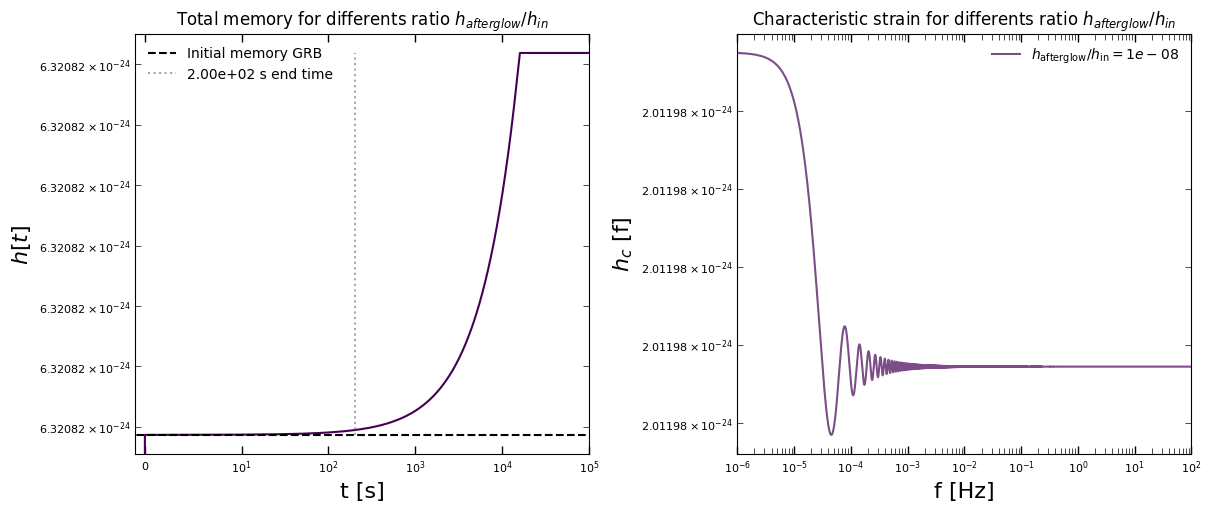

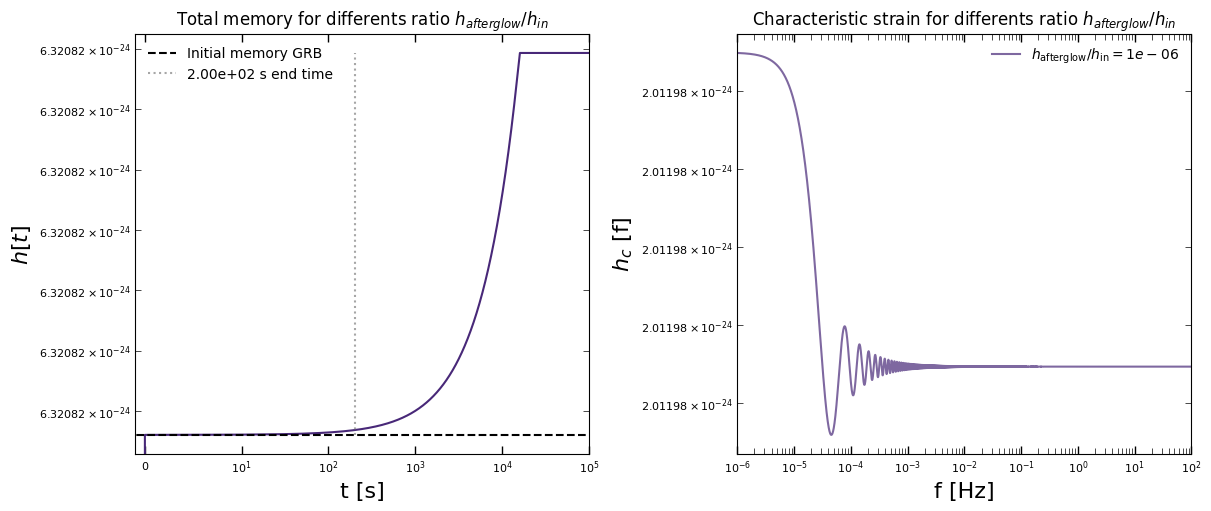

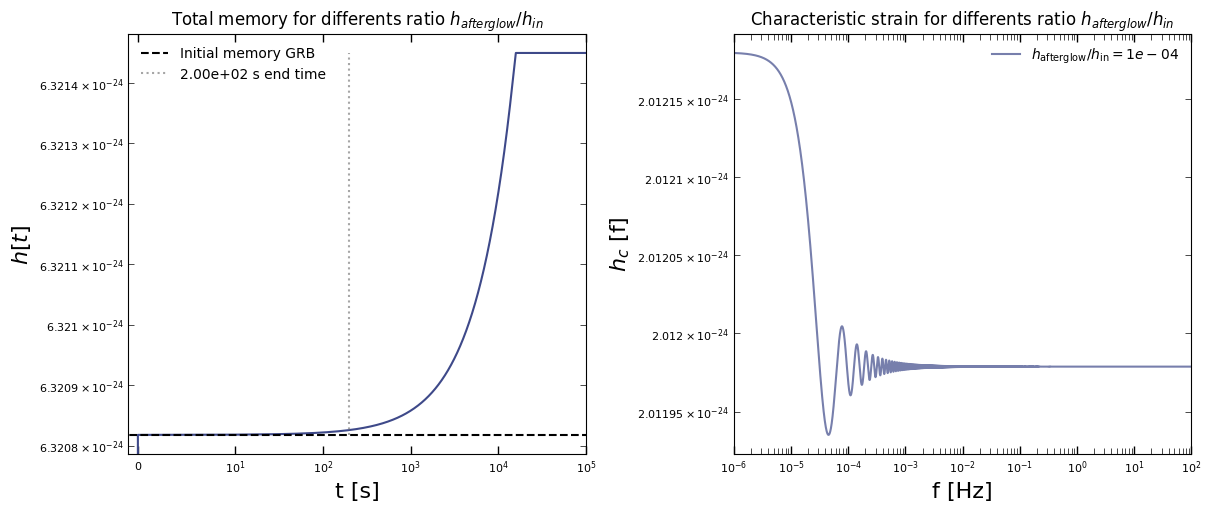

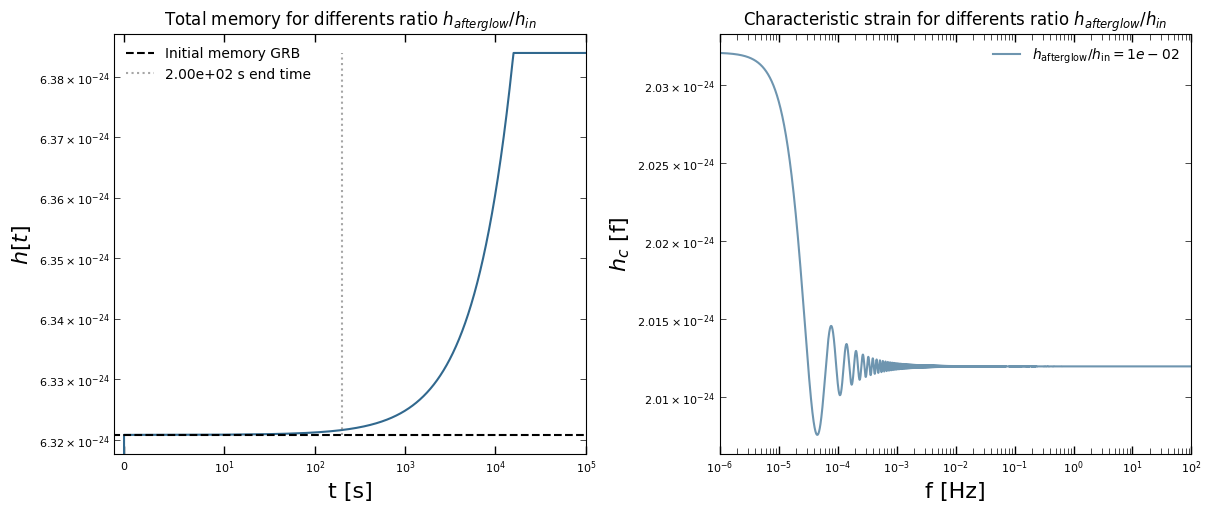

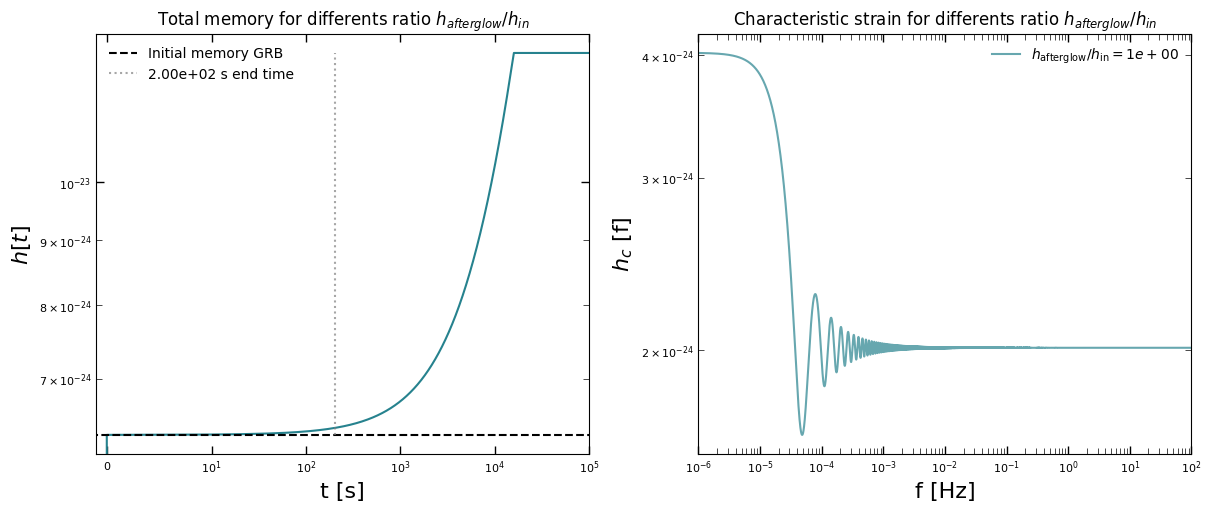

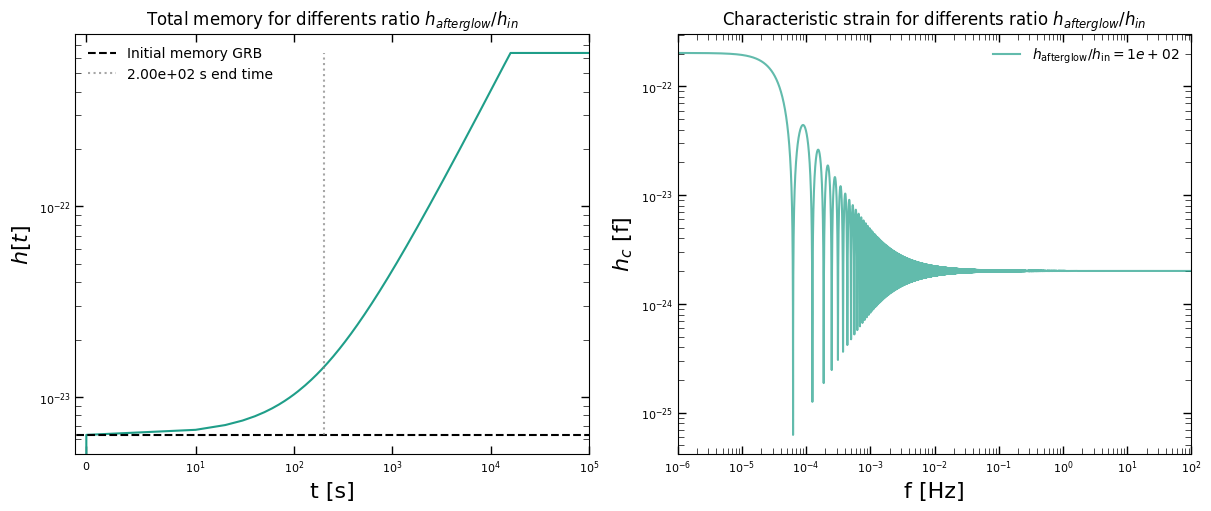

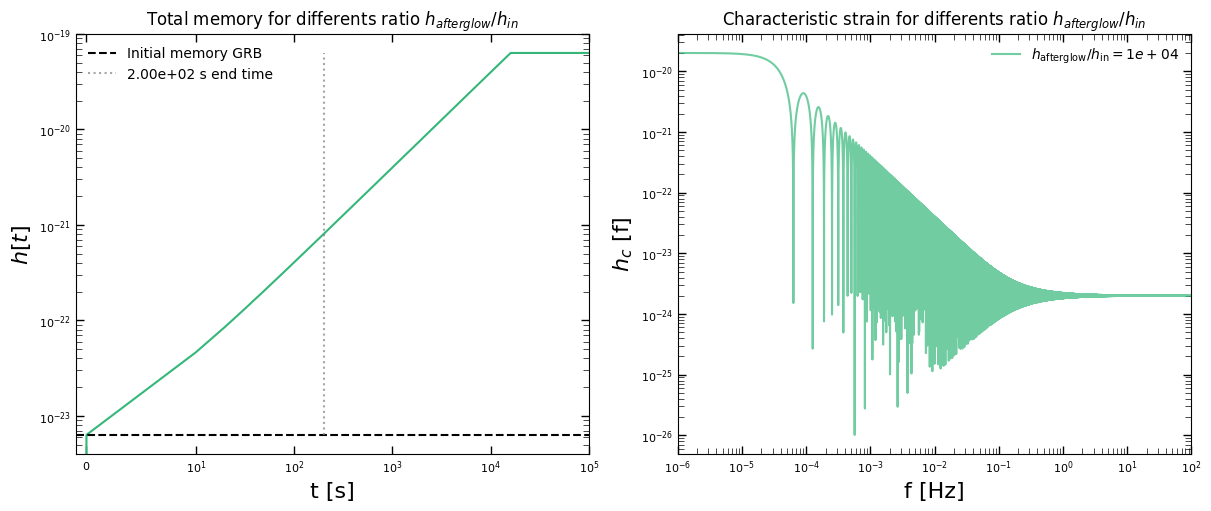

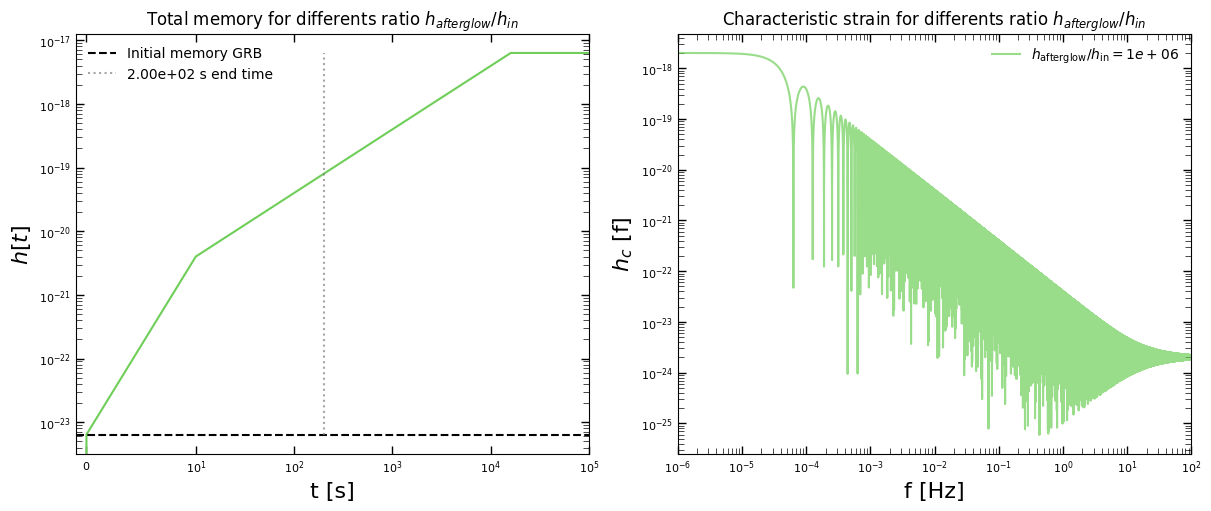

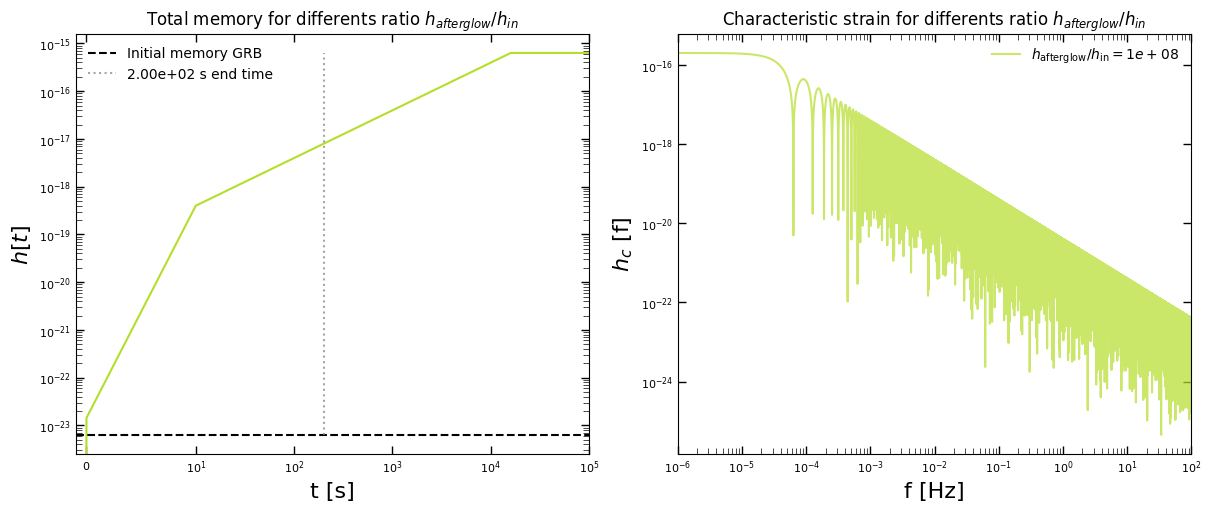

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import SymmetricalLogLocator
import numpy as np
import utils_phenom as up

# Paramètres du cas unique
case = {
    'E_j': 1e50,  
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s,
}
# ratios between 1e-4 to 1e4 to cover a wide range of possible afterglow contributions to the total memory
ratios = np.logspace(-8, 8, 17)
# only take 1 value out of 2 to avoid having too many curves on the plot
ratios = ratios[::2]
t = np.linspace(-10, 1e6, int(1e5))  # -10 s à 1000 s

theta_j = case['theta_j']
theta_v = case['theta_v']
theta_ej = case['theta_ej']
phi_ej = case['phi_ej']
beta = case['beta']
r = case['r']
tau_grb_s = case['tau_grb_s']
end_grb_s = case['end_grb_s']
E_j = case['E_j']

for idx, ratio in enumerate(ratios):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
    if ratio == 0:
        h_afterglow = 0
    else:
        h_afterglow = h_in * ratio
    h_tot, _ = up.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej)
    f, fft = up.new_fft(h_in, h_afterglow, end_grb_s, theta_ej)
    label = f'$h_{{\\mathrm{{afterglow}}}}/h_{{\\mathrm{{in}}}}={ratio:.0e}$'
    ax1.plot(t, h_tot, color=plt.cm.viridis(idx / len(ratios)))
    ax1.hlines(h_in, t[0], t[-1], label='Initial memory GRB', color='k', linestyle='--')
    ax1.vlines(end_grb_s, h_in, h_tot[-1], color='grey', linestyle='dotted', alpha=0.7, label=f'{end_grb_s:.2e} s end time')
    
    ax2.loglog(f, 2*f*np.abs(fft), label=label, color=plt.cm.viridis(idx / len(ratios)) , alpha=0.7)

    ax1.set_xlabel('t [s]')
    ax1.set_xscale('symlog', linthresh=10, linscale=1.0)
    ax1.set_yscale('log')
    ax1.minorticks_on()
    ax1.set_ylabel(r'$h [t]$')
    ax1.set_title('Total memory for differents ratio $h_{afterglow}/h_{in}$')
    ax1.legend(loc='best', frameon=False)
    ax1.set_xlim(-1, 1e5)
    ax1.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

    ax2.set_xlabel('f [Hz]')
    ax2.set_ylabel(r'$h_c$ [f]')
    ax2.set_title('Characteristic strain for differents ratio $h_{afterglow}/h_{in}$')
    ax2.set_xlim(1e-6, 1e2)
    ax2.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
    ax2.legend(loc='upper right', frameon=False)

    plt.show()

All on one plot (more clear to see the impact of the afterglow memory on the total memory signal in frequency domain)

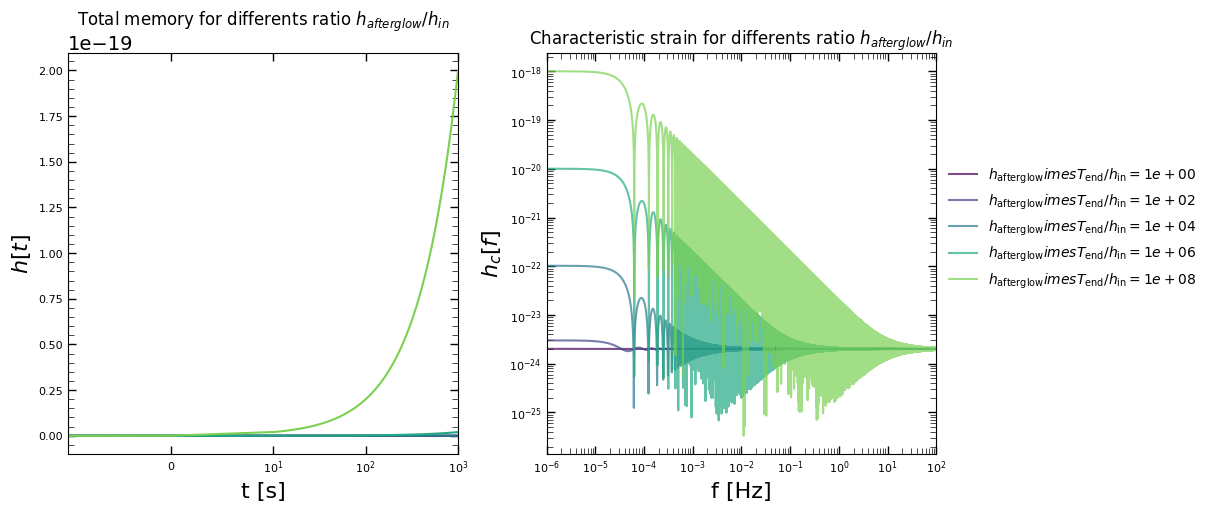

In [41]:

# Paramètres du cas unique
case = {
    'E_j': 1e50,  
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': np.deg2rad(10),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s,
}
# ratios between 1e-4 to 1e4 to cover a wide range of possible afterglow contributions to the total memory
ratios = np.logspace(0, 8, 9)
# only take 1 value out of 2 to avoid having too many curves on the plot
ratios = ratios[::2]
t = np.linspace(-10, 1e3, int(1e5))  # -10 s à 1000 s

theta_j = case['theta_j']
theta_v = case['theta_v']
theta_ej = case['theta_ej']
phi_ej = case['phi_ej']
beta = case['beta']
r = case['r']
tau_grb_s = case['tau_grb_s']
end_grb_s = case['end_grb_s']
E_j = case['E_j']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for idx, ratio in enumerate(ratios):
    h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
    if ratio == 0:
        h_afterglow = 0
    else:
        h_afterglow = (h_in * ratio) / end_grb_s # divide by end_grb_s to have the same order of magnitude for the memory amplitude 
    h_tot, _ = up.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej)
    f, fft = up.new_fft(h_in, h_afterglow, end_grb_s, theta_ej)
    label = f'$h_{{\\mathrm{{afterglow}}}} \times T_{{\\mathrm{{end}}}}/h_{{\\mathrm{{in}}}}={ratio:.0e}$'
    ax1.plot(t, h_tot, label=label, color=plt.cm.viridis(idx / len(ratios)))
    ax2.loglog(f, 2*f*np.abs(fft), label=label, alpha=0.7, color=plt.cm.viridis(idx / len(ratios)))

ax1.set_xlabel('t [s]')
ax1.set_xscale('symlog', linthresh=10, linscale=1.0)
ax1.set_ylabel(r'$h [t]$')
ax1.set_title('Total memory for differents ratio $h_{afterglow}/h_{in}$')
ax1.set_xlim(-10, t[-1])

ax1.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

ax2.set_xlabel('f [Hz]')
ax2.set_ylabel(r'$h_c[f]$')
ax2.set_title('Characteristic strain for differents ratio $h_{afterglow}/h_{in}$')
ax2.set_xlim(1e-6, 1e2)
ax2.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
ax2.legend(loc='upper left', frameon=False, bbox_to_anchor=(1.0, 0.75))

plt.show()

Same but here we directly modify E_in (GRB energy) to see the impact of the afterglow memory on the total memory signal in frequency domain 

Associated timescale for the propagation of the FS afterglow with a radius of 0.01 pc: 1.56e+04 s
Time of the transition between the GRB memory and the afterglow memory: 1.58e+04 s


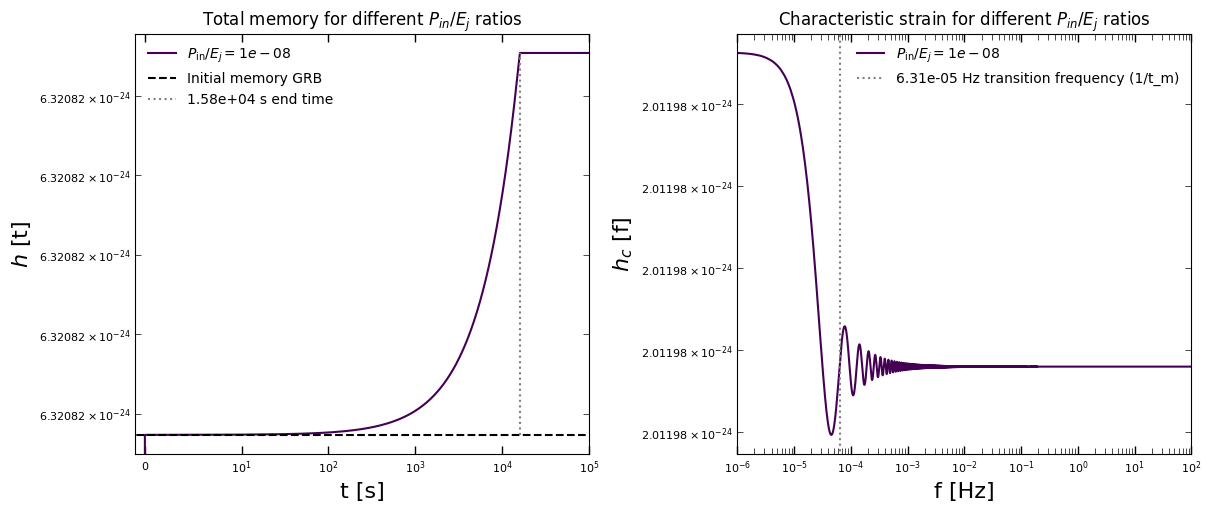

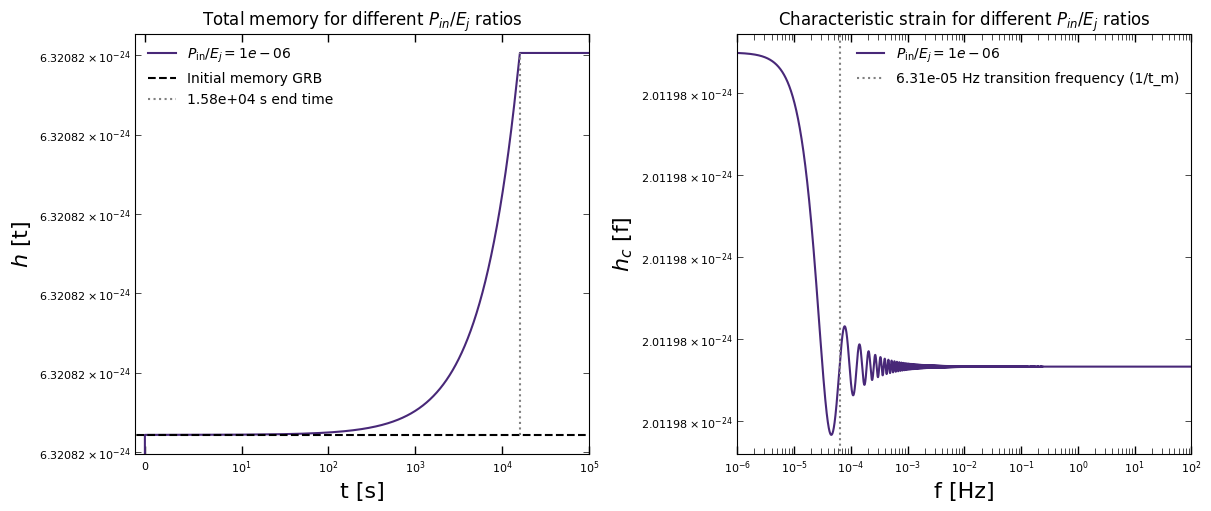

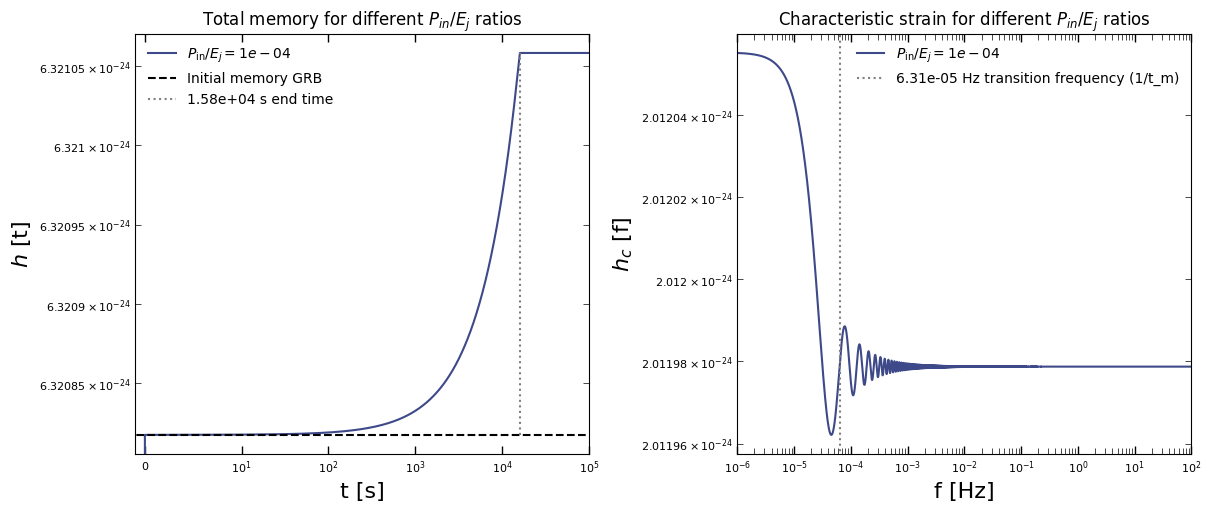

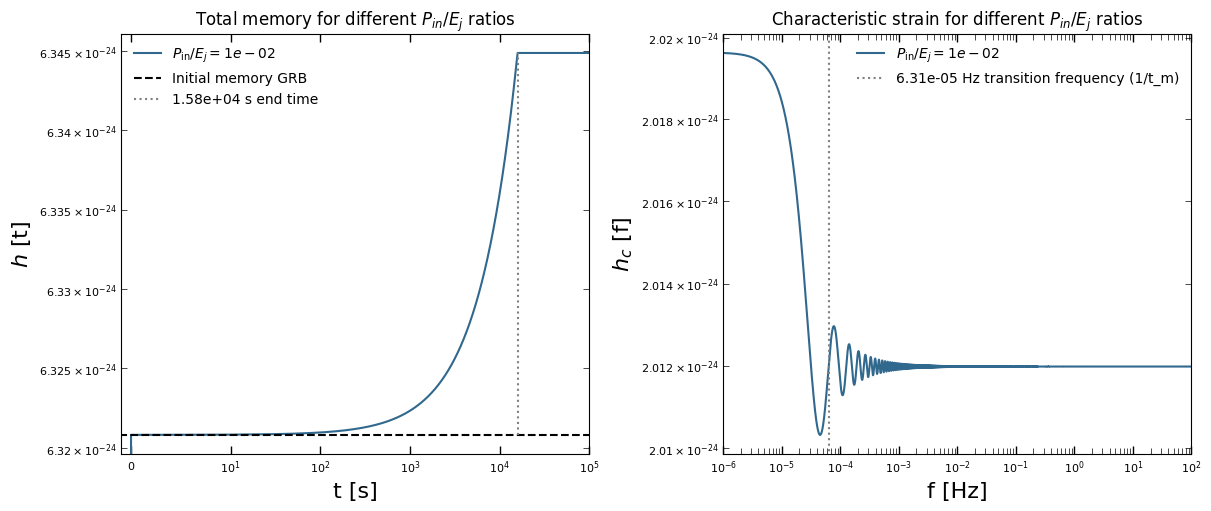

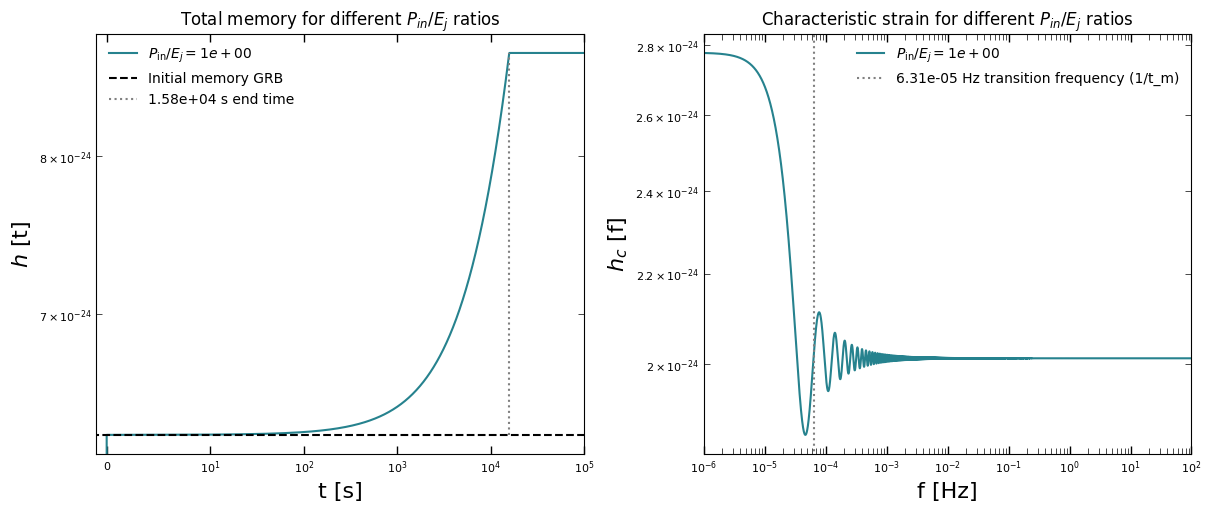

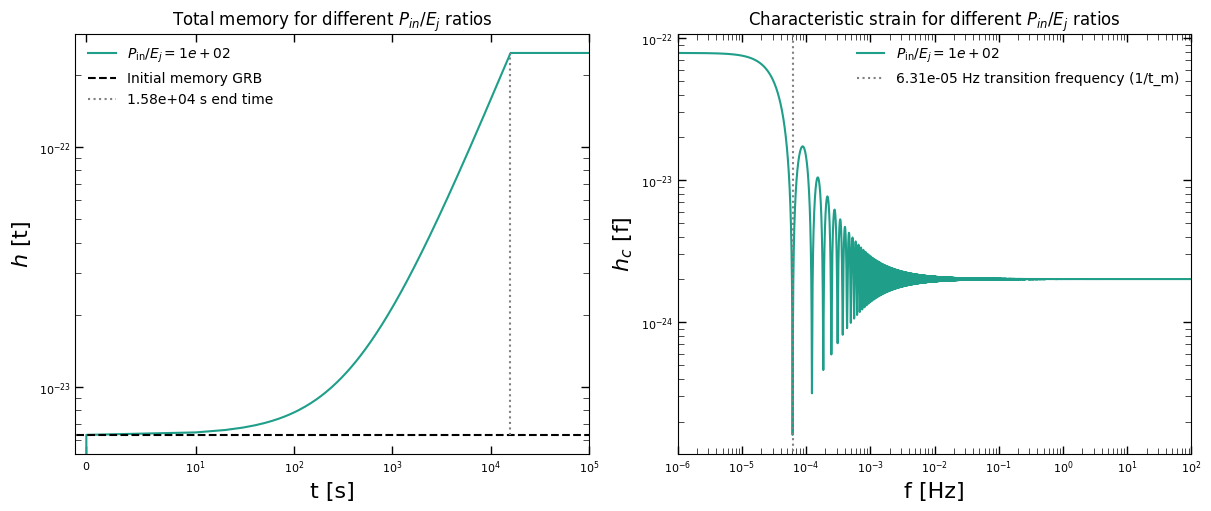

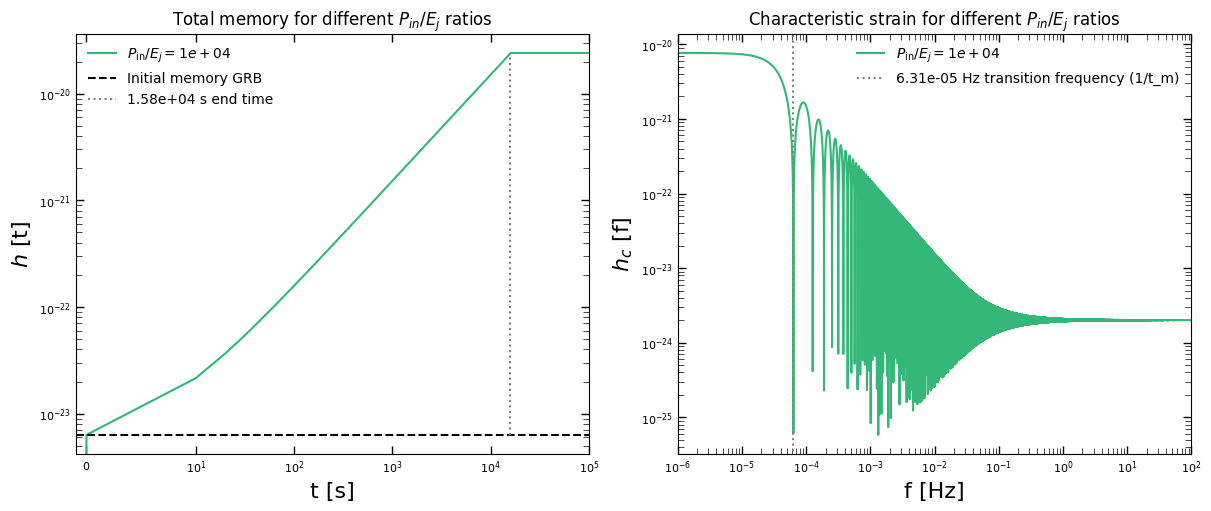

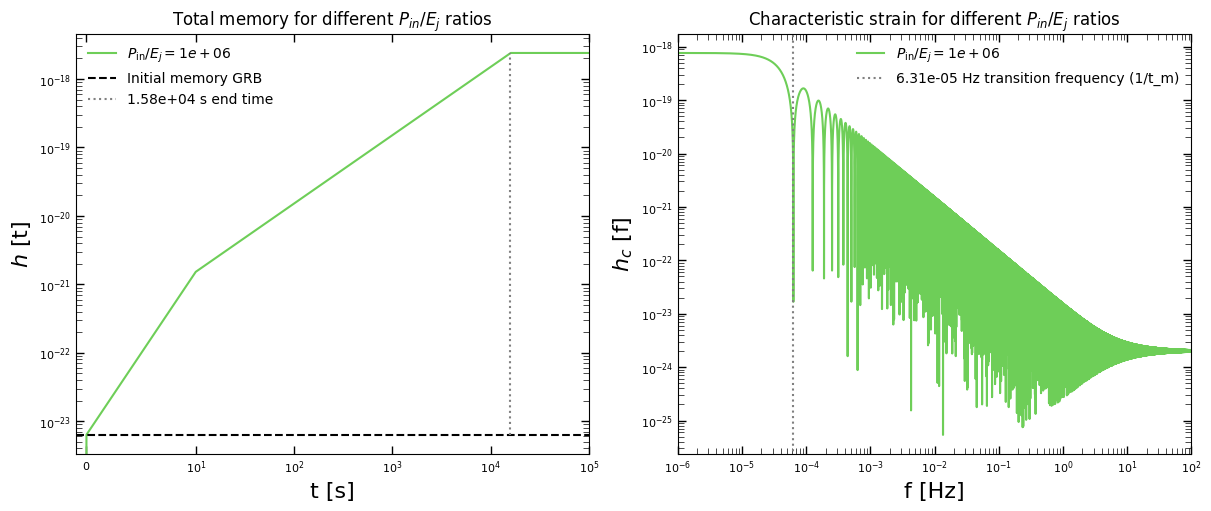

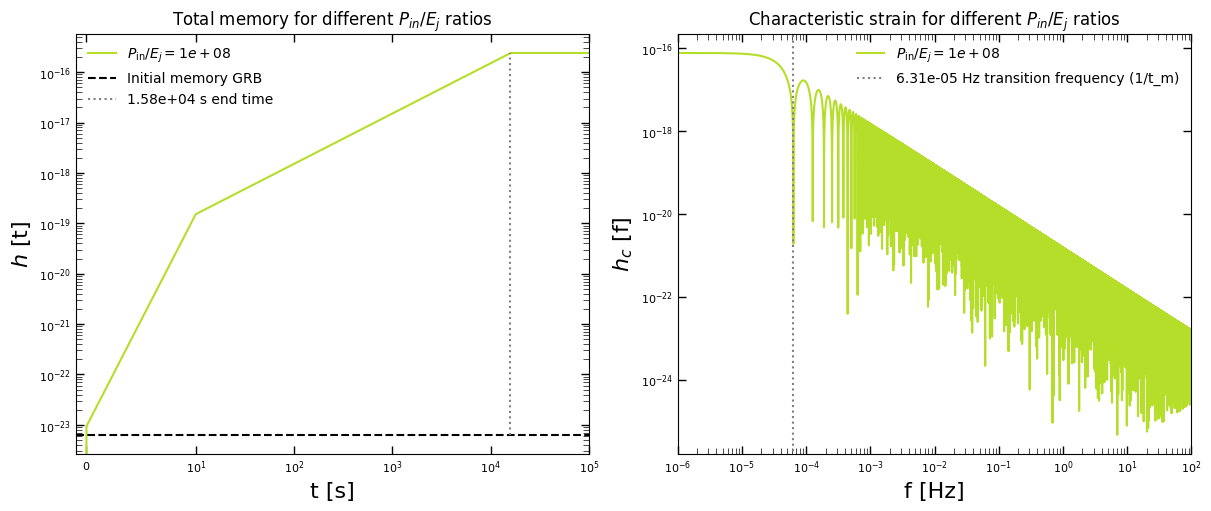

In [42]:
# Paramètres du cas unique
case = {
    'E_j': 1e50,  
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s,
}
# Ratios for P_in / E_j (afterglow power as a fraction of GRB energy per second)
ratios = np.logspace(-8, 8, 9)
t = np.linspace(-10, 1e6, int(1e5))  # -10 s à 1e6 s

theta_j = case['theta_j']
theta_v = case['theta_v']
theta_ej = case['theta_ej']
phi_ej = case['phi_ej']
beta = case['beta']
r = case['r']
tau_grb_s = case['tau_grb_s']
end_grb_s = case['end_grb_s']
E_j = case['E_j']

t_end_afterglow_prop = ( (0.01 * PC_SI) * (1-np.cos(theta_ej)) )/ C_SI
print(f"Associated timescale for the propagation of the FS afterglow with a radius of 0.01 pc: {t_end_afterglow_prop:.2e} s")
t_m = end_grb_s + t_end_afterglow_prop
print(f"Time of the transition between the GRB memory and the afterglow memory: {t_m:.2e} s")
for idx, ratio in enumerate(ratios):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
    # Afterglow power as a fraction of E_j per second
    P_in = E_j * ratio
    # Afterglow memory amplitude
    h_afterglow = up.memory_afterglow_injection(P_in, end_grb_s, theta_ej, theta_j, r, beta)
    h_tot, _ = up.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej)
    f, fft = up.new_fft(h_in, h_afterglow, end_grb_s, theta_ej)
    label = f'$P_{{\\mathrm{{in}}}}/E_j={ratio:.0e}$'
    ax1.plot(t, h_tot, color=plt.cm.viridis(idx / len(ratios)), label=label)
    ax1.hlines(h_in, t[0], t[-1], label='Initial memory GRB', color='k', linestyle='--')
    ax1.vlines(t_m, h_in, h_tot[-1], color='grey', linestyle='dotted', label=f'{t_m:.2e} s end time')
    
    ax2.loglog(f, 2*f*np.abs(fft), label=label, color=plt.cm.viridis(idx / len(ratios)))
    ax2.vlines(1/t_m, 1e-30, 1e-15, color='grey', linestyle='dotted', label=f'{1/t_m:.2e} Hz transition frequency (1/t_m)')
    ax1.set_xlabel('t [s]')
    ax1.set_xscale('symlog', linthresh=10, linscale=1.0)
    ax1.set_yscale('log')
    ax1.minorticks_on()
    ax1.set_ylabel(r'$h$ [t]')
    ax1.set_title('Total memory for different $P_{in}/E_j$ ratios')
    ax1.set_xlim(-1, 1e5)
    ax1.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

    ax2.set_xlabel('f [Hz]')
    ax2.set_ylabel(r'$h_c$ [f]')
    ax2.set_title('Characteristic strain for different $P_{in}/E_j$ ratios')
    ax2.set_xlim(1e-6, 1e2)
    ax2.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

    ax1.legend(loc='best', frameon=False)
    ax2.legend(loc='upper right', frameon=False)

    plt.show()

Associated timescale for the propagation of the FS afterglow with a radius of 0.01 pc: 1.56e+04 s
Time of the transition between the GRB memory and the afterglow memory: 1.58e+04 s
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24


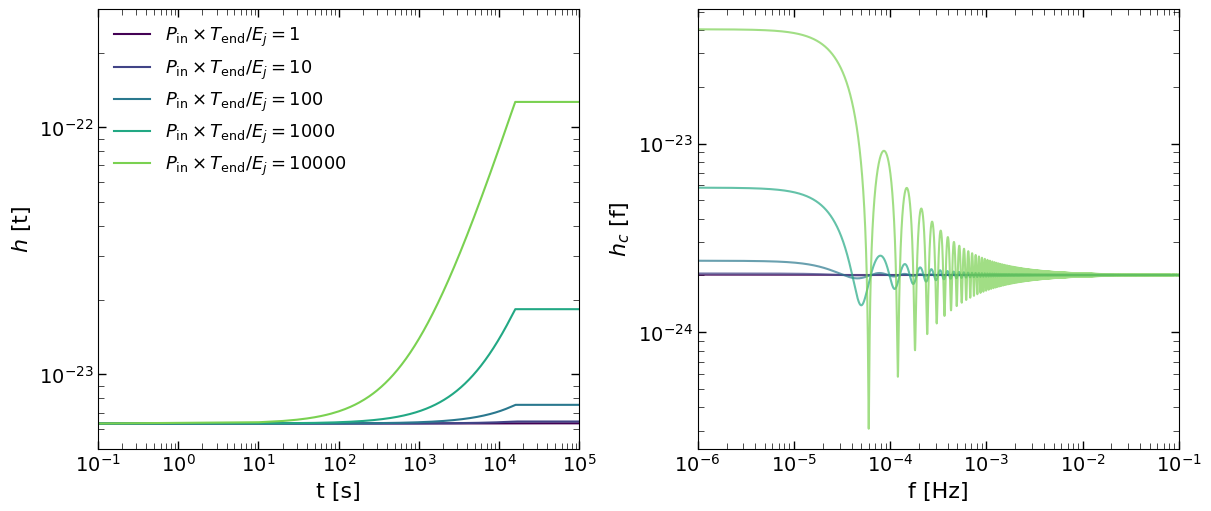

In [64]:
# Paramètres du cas unique
case = {
    'E_j': 1e50,  
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': np.deg2rad(10),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s,
}
# Ratios for P_in / E_j (afterglow power as a fraction of GRB energy per second)
ratios = np.logspace(0, 4, 5)
t = np.linspace(0.1, 1e6, int(1e5))  

theta_j = case['theta_j']
theta_v = case['theta_v']
theta_ej = case['theta_ej']
phi_ej = case['phi_ej']
beta = case['beta']
r = case['r']
tau_grb_s = case['tau_grb_s']
end_grb_s = case['end_grb_s']
E_j = case['E_j']

t_end_afterglow_prop = ( (0.01 * PC_SI) * (1-np.cos(theta_ej)) )/ C_SI
print(f"Associated timescale for the propagation of the FS afterglow with a radius of 0.01 pc: {t_end_afterglow_prop:.2e} s")
t_m = end_grb_s + t_end_afterglow_prop
print(f"Time of the transition between the GRB memory and the afterglow memory: {t_m:.2e} s")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for idx, ratio in enumerate(ratios):
    h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
    print(f"Initial memory amplitude from the GRB: {h_in:.2e}")
    # Afterglow power as a fraction of E_j per second
    P_in = E_j * ratio / end_grb_s # divide by end_grb_s to have the same order of magnitude for the memory amplitude
    # Afterglow memory amplitude
    h_afterglow = up.memory_afterglow_injection(P_in, end_grb_s, theta_ej, theta_j, r, beta)
    h_tot, _ = up.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej)
    f, fft = up.new_fft(h_in, h_afterglow, end_grb_s, theta_ej)
    label = f'$P_{{\\mathrm{{in}}}} \\times T_{{\\mathrm{{end}}}}/E_j={ratio:.0f}$'
    ax1.plot(t, h_tot, color=plt.cm.viridis(idx / len(ratios)), label=label)
    ax2.loglog(f, 2*f*np.abs(fft), label=label, color=plt.cm.viridis(idx / len(ratios)), alpha=0.7)
    
ax1.set_xlabel('t [s]')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(5e-24, 3e-22)
ax1.minorticks_on()
ax1.set_ylabel(r'$h$ [t]')

ax1.set_xlim(0.1, 1e5)

ax2.set_xlabel('f [Hz]')
ax2.set_ylabel(r'$h_c$ [f]')

ax2.set_xlim(1e-6, 1e-1)

ax1.legend(loc='upper left', frameon=False, fontsize = 13)

plt.show()

In [44]:
# Pratical units for the grb memory in cgs units
G = 6.67430e-8  # cm^3 g^-1 s^-2
c = 2.99792458e10  # cm/s
E_j = 1e50  # erg
r = 100 * 1e6 * 3.086e18  # 100 Mpc in cm
delta_h = (2 * G * E_j) / (c**4 * r)
print(f"Characteristic strain of the GRB memory for E_j={E_j} erg at r={r} cm: {delta_h:.2e}")

Characteristic strain of the GRB memory for E_j=1e+50 erg at r=3.086e+26 cm: 5.35e-26


We also see the importance of the **radius at which the afterglow memory is produced** (``t_end_afterglow_prop``), as it impacts the amplitude of the afterglow memory signal. If the assumed that the associated radius is smaller, the afterglow memory would saturate sooner and thus have a lower associated frequency, and so the afterglow memory would be more difficult to detect with LISA. 

As LISA has a best sensitivity around 1e-2 Hz, the afterglow memory would be detectable if the associated time is $\lesssim$ 100 s.

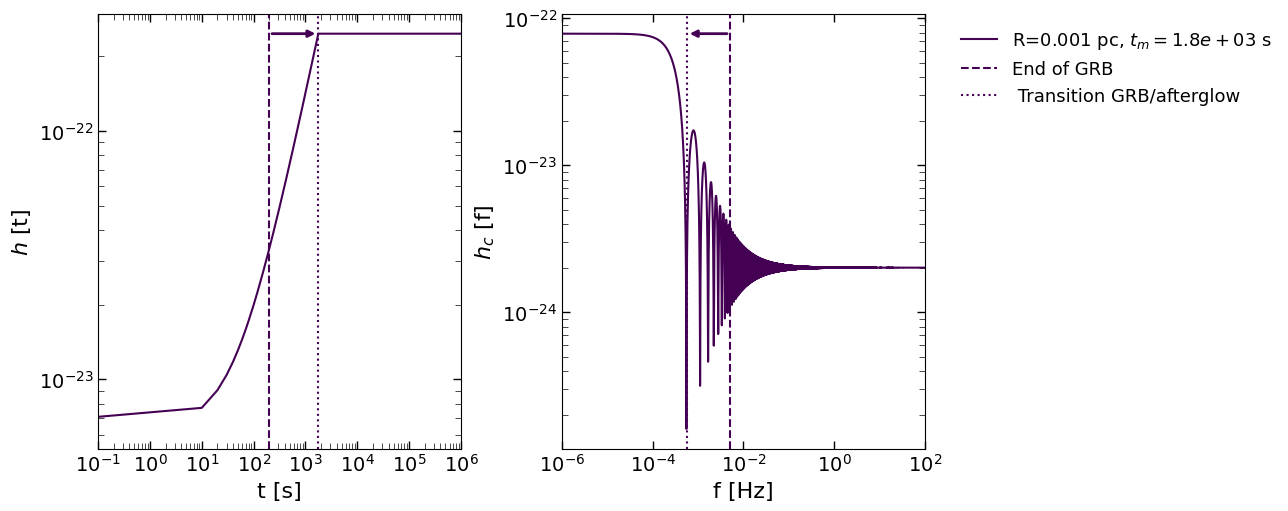

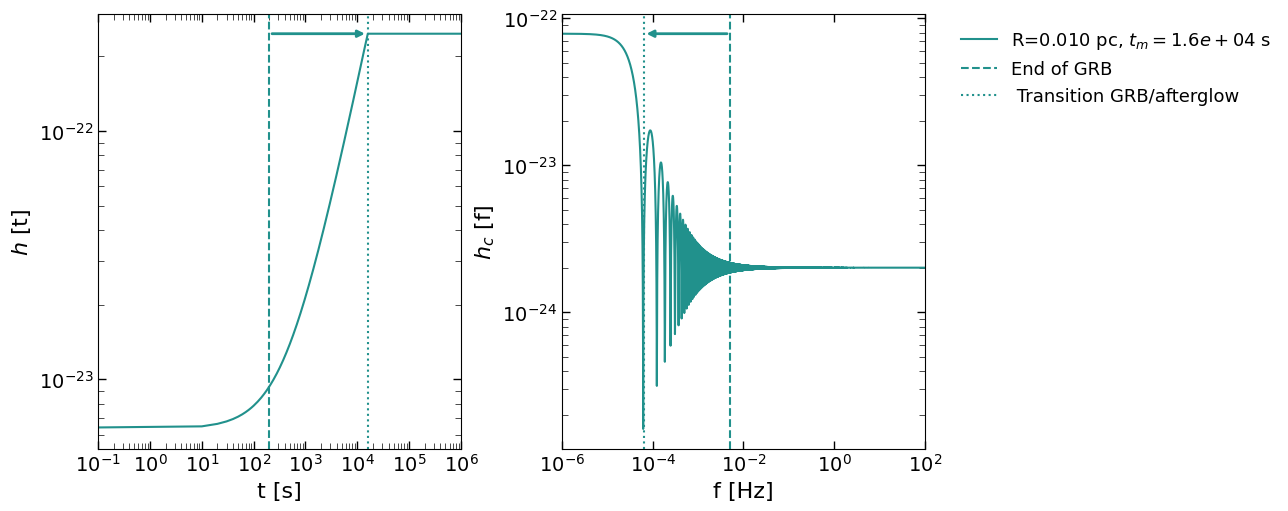

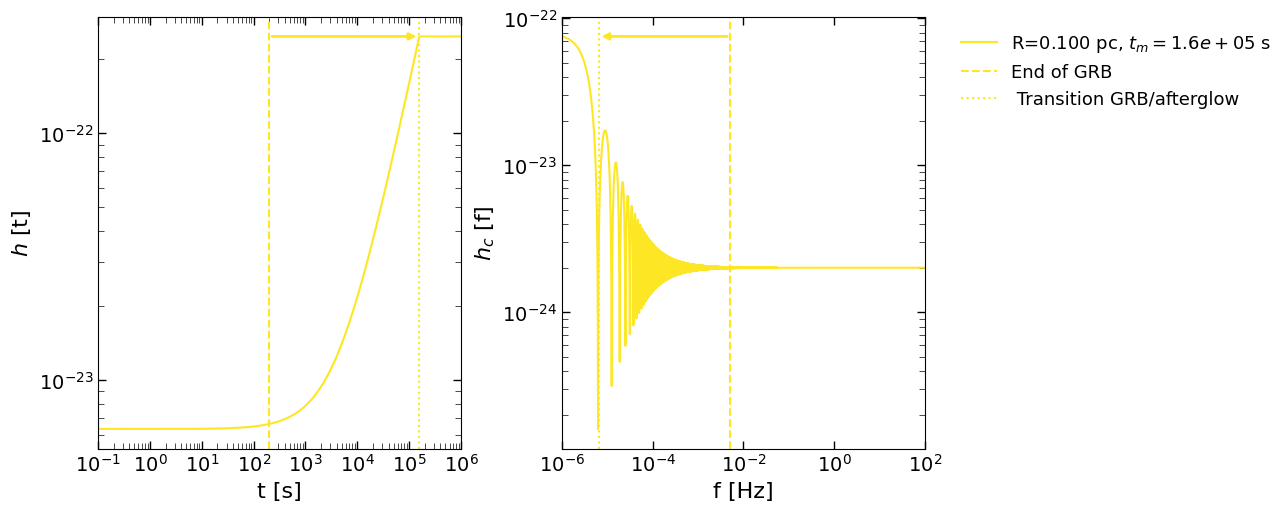

In [69]:
case = {
    'E_j': 1e50,  
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s,
}
radii_pc = [0.001, 0.01, 0.1]
P_in = 1e52
t = np.linspace(-10, 1e6, int(1e5))  # -10 s à 1e6 s

theta_j = case['theta_j']
theta_ej = case['theta_ej']
phi_ej = case['phi_ej']
beta = case['beta']
r = case['r']
end_grb_s = case['end_grb_s']
tau_grb_s = case['tau_grb_s']
E_j = case['E_j']

colors = plt.cm.viridis(np.linspace(0, 1, len(radii_pc)))


for idx, radius_pc in enumerate(radii_pc):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    t_end_afterglow_prop = ((radius_pc * PC_SI) * (1 - np.cos(theta_ej))) / C_SI
    t_m = end_grb_s + t_end_afterglow_prop
    h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
    h_afterglow = up.memory_afterglow_injection(P_in, end_grb_s, theta_ej, theta_j, r, beta)
    h_tot, _ = up.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej, radius = radius_pc)
    
    f, fft = up.new_fft(h_in, h_afterglow, end_grb_s, theta_ej, radius=radius_pc)
    
    label = f'R={radius_pc:.3f} pc, $t_m={t_m:.1e}$ s'
    ax1.plot(t, h_tot, color=colors[idx], label=label)
    ax2.loglog(f, 2*f*np.abs(fft), label=label, color=colors[idx])
    # Vlines pour end_grb_s et t_m
    ax1.axvline(end_grb_s, color=colors[idx], linestyle='dashed' )
    ax1.axvline(t_m, color=colors[idx], linestyle='dotted')
    ax2.axvline(1/end_grb_s, color=colors[idx], linestyle='dashed',  label="End of GRB")
    ax2.axvline(1/t_m, color=colors[idx], linestyle='dotted', label=" Transition GRB/afterglow")
    # Pour la flèche temporelle : 
    y_min, y_max = ax1.get_ylim()
    y_arrow = h_tot[-1]
    ax1.annotate(
        '', 
        xy=(end_grb_s + t_end_afterglow_prop, y_arrow), 
        xytext=(end_grb_s, y_arrow),
        arrowprops=dict(arrowstyle='-|>', color=colors[idx], lw=2),
        annotation_clip=False
    )
 
    # Pour la flèche fréquentielle : 
    y2_min, y2_max = ax2.get_ylim()
    y_arrow2 = max(2*f*np.abs(fft))
    ax2.annotate(
        '', 
        xy=(1/(end_grb_s), y_arrow2), 
        xytext=(1/(end_grb_s + t_end_afterglow_prop), y_arrow2),
        arrowprops=dict(arrowstyle='<|-', color=colors[idx], lw=2),
        annotation_clip=False
    )

    ax1.set_xlabel('t [s]')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.minorticks_on()
    ax1.set_ylabel(r'$h$ [t]')
    ax1.set_xlim(1e-1, 1e6)

    ax2.set_xlabel('f [Hz]')
    ax2.set_ylabel(r'$h_c$ [f]')

    ax2.set_xlim(1e-6, 1e2)

    ax2.legend(loc='upper right', frameon=False, bbox_to_anchor=(2, 1), fontsize=13)

    plt.show()

Associated timescale for the propagation of the FS afterglow with a radius of 0.001 pc: 1.56e+03 s Time of the transition between the GRB memory and the afterglow memory: 1.76e+03 s
Associated timescale for the propagation of the FS afterglow with a radius of 0.01 pc: 1.56e+04 s Time of the transition between the GRB memory and the afterglow memory: 1.58e+04 s


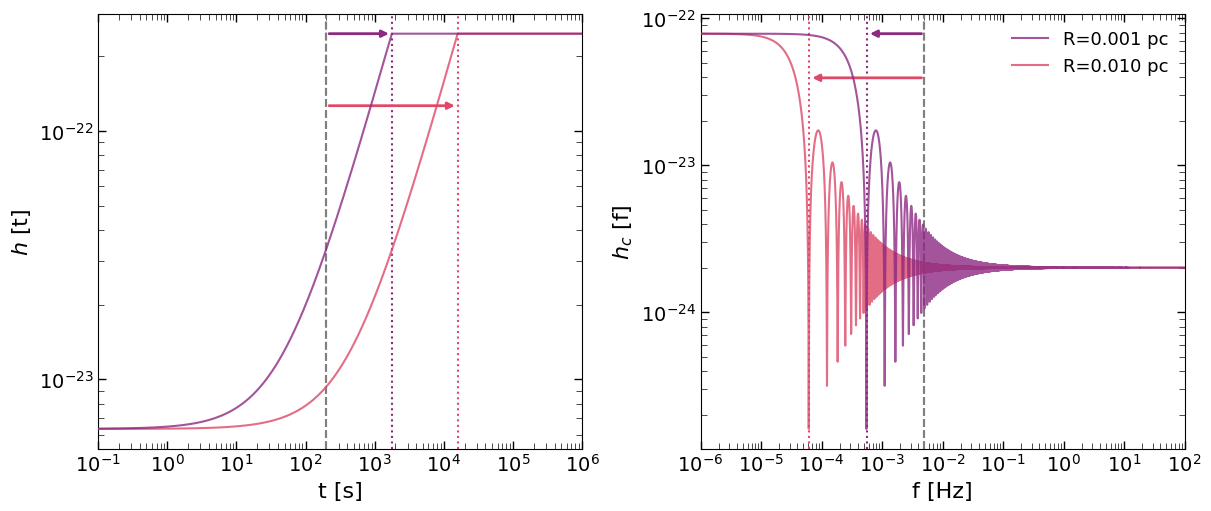

In [96]:
case = {
    'E_j': 1e50,  
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s,
}
radii_pc = [0.001, 0.01]
P_in = 1e52
t = np.logspace(np.log(1e-1), np.log(1e6), int(1e5))  # -10 s à 1e6 s

theta_j = case['theta_j']
theta_ej = case['theta_ej']
phi_ej = case['phi_ej']
beta = case['beta']
r = case['r']
end_grb_s = case['end_grb_s']
tau_grb_s = case['tau_grb_s']
E_j = case['E_j']

colors = plt.cm.magma(np.linspace(0.4, 0.6, len(radii_pc)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for idx, radius_pc in enumerate(radii_pc):
    
    t_end_afterglow_prop = ((radius_pc * PC_SI) * (1 - np.cos(theta_ej))) / C_SI
    t_m = end_grb_s + t_end_afterglow_prop
    print(f"Associated timescale for the propagation of the FS afterglow with a radius of {radius_pc} pc: {t_end_afterglow_prop:.2e} s", f"Time of the transition between the GRB memory and the afterglow memory: {t_m:.2e} s")
    h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
    h_afterglow = up.memory_afterglow_injection(P_in, end_grb_s, theta_ej, theta_j, r, beta)
    h_tot, _ = up.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej, radius = radius_pc)
    
    f, fft = up.new_fft(h_in, h_afterglow, end_grb_s, theta_ej, radius=radius_pc)
    
    label = f'R={radius_pc:.3f} pc'
    ax1.plot(t, h_tot, color=colors[idx], label=label, zorder= 10-idx, alpha=0.8)
    ax2.loglog(f, 2*f*np.abs(fft), label=label, color=colors[idx], zorder=10- idx, alpha=0.8)
    # Vlines pour end_grb_s et t_m
    ax1.axvline(end_grb_s, color='grey', linestyle='dashed')
    ax1.axvline(t_m, color=colors[idx], linestyle='dotted')
    ax2.axvline(1/end_grb_s, color='grey', linestyle='dashed')
    ax2.axvline(1/t_m, color=colors[idx], linestyle='dotted')
    # Pour la flèche temporelle : 
    y_min, y_max = ax1.get_ylim()
    y_arrow = h_tot[-1] - idx * (h_tot[-1] - h_in) / len(radii_pc) # to avoid having the arrows on top of each other
    ax1.annotate(
        '', 
        xy=(end_grb_s + t_end_afterglow_prop, y_arrow), 
        xytext=(end_grb_s, y_arrow),
        arrowprops=dict(arrowstyle='-|>', color=colors[idx], lw=2),
        annotation_clip=False
    )
 
    # Pour la flèche fréquentielle : 
    y2_min, y2_max = ax2.get_ylim()
    y_arrow2 = max(2*f*np.abs(fft)) - idx * (max(2*f*np.abs(fft)) - min(2*f*np.abs(fft))) / len(radii_pc) # to avoid having the arrows on top of each other
    ax2.annotate(
        '', 
        xy=(1/(end_grb_s), y_arrow2), 
        xytext=(1/(end_grb_s + t_end_afterglow_prop), y_arrow2),
        arrowprops=dict(arrowstyle='<|-', color=colors[idx], lw=2),
        annotation_clip=False
    )

    ax1.set_xlabel('t [s]')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.minorticks_on()
    ax1.set_ylabel(r'$h$ [t]')
    ax1.set_xlim(1e-1, 1e6)

    ax2.set_xlabel('f [Hz]')
    ax2.set_ylabel(r'$h_c$ [f]')

    ax2.set_xlim(1e-6, 1e2)

    ax2.legend(loc='upper right', frameon=False, fontsize=13)

plt.show()

Here the arrows represent the time that we add to the end of the GRB memory to get the total duration of the event, which is the duration of the GRB + the duration to reach the radius at which the afterglow memory is produced ( = arrow length). The impact of this duration on the total memory signal is quite important, as it impacts the minimum frequency at which the memory signal is present. If the total duration of the event is too long, the memory signal would not be present at frequencies ~ 1e-2 Hz, and thus would not be detectable with LISA. The value of this duration depends on the radius at which the afterglow memory is produced (and on the velocity of the ejecta = speed of light in this case). Thus, the associated radius value must be quite small (compared to the duration of the GRB * c) AND physically motivated to have a chance to detect the afterglow memory with LISA.  

If we increase the radius at which the afterglow memory is produced, the rise time of the afterglow memory would be longer, and thus the associated frequency would be lower, making the afterglow memory more difficult to detect with LISA.

* If $h_{peak - LISA} = 10^{-2}$ Hz, then the associated time is $t_m \sim$ 100 s, where $t_{m} = t_{GRB} + t_{end - afterglow}$, and $t_{end - afterglow} = R_{afterglow}/c$.

/tmp/ipykernel_1138/1540819335.py:49: RuntimeWarning: invalid value encountered in sqrt
  ax2.loglog(f_lisa, np.sqrt(f_lisa*Sn), label='LISA', color='k', linestyle='-.')


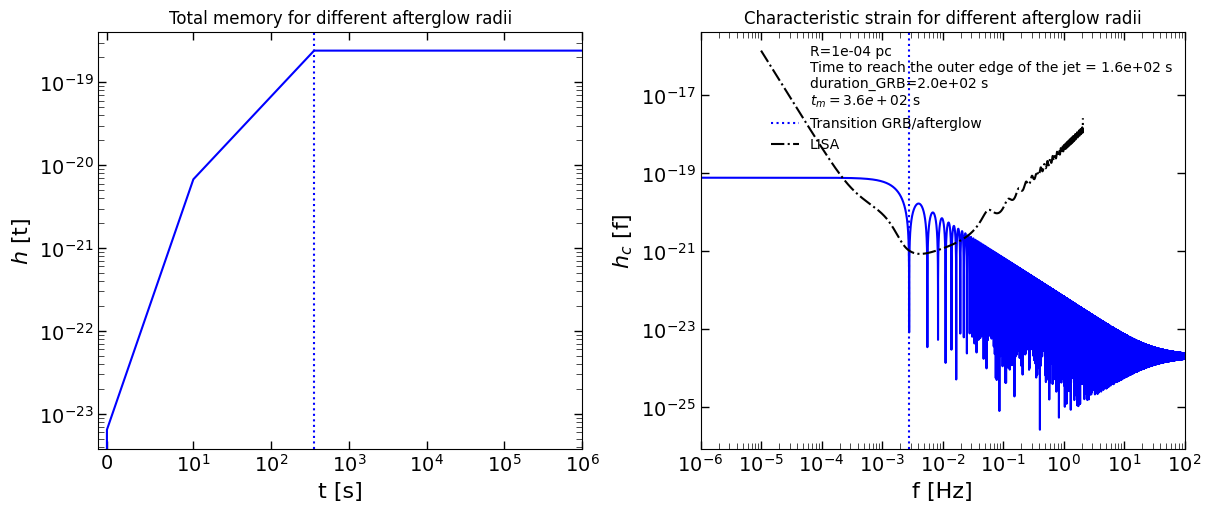

In [46]:
case = {
    'E_j': 1e50,  
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s,
}
radii_pc = 0.0001
P_in = 1e55
t = np.linspace(-10, 1e6, int(1e5))  # -10 s à 1e6 s

theta_j = case['theta_j']
theta_ej = case['theta_ej']
phi_ej = case['phi_ej']
beta = case['beta']
r = case['r']
end_grb_s = case['end_grb_s']
tau_grb_s = case['tau_grb_s']
E_j = case['E_j']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
h_afterglow = up.memory_afterglow_injection(P_in, end_grb_s, theta_ej, theta_j, r, beta)
h_tot, _ = up.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej, radius=radii_pc)
f, fft = up.new_fft(h_in, h_afterglow, end_grb_s, theta_ej, radius=radii_pc)

t_end_afterglow_prop = ((radii_pc * PC_SI) * (1 - np.cos(theta_ej))) / C_SI
t_m = end_grb_s + t_end_afterglow_prop
label_text = (
    f'R={radii_pc:.0e} pc\n'
    f'Time to reach the outer edge of the jet = {t_end_afterglow_prop:.1e} s\n'
    f'duration_GRB={end_grb_s:.1e} s\n'
    f'$t_m={t_m:.1e}$ s'
)
ax1.plot(t, h_tot, color='blue')
ax2.loglog(f, 2*f*np.abs(fft), color='blue')
# Vlines pour end_grb_s et t_m
ax1.axvline(t_m, color='blue', linestyle='dotted', label="Transition GRB/afterglow")
ax2.axvline(1/t_m, color='blue', linestyle='dotted', label="Transition GRB/afterglow")
# Add LISA sensitivity curve
import LISA as li
lisa = li.LISA() # initialize LISA object   
f_lisa  = np.logspace(-5,2, 10000)
Sn = lisa.Sn(f_lisa)
ax2.loglog(f_lisa, np.sqrt(f_lisa*Sn), label='LISA', color='k', linestyle='-.')

# Add the label as a text-only legend entry (not associated to a curve) ONLY for ax2
from matplotlib.lines import Line2D
custom_label = [Line2D([0], [0], color='none', label=label_text)]
ax2.legend(handles=custom_label + ax2.get_legend_handles_labels()[0], loc='upper right', frameon=False,)

ax1.set_xlabel('t [s]')
ax1.set_xscale('symlog', linthresh=10, linscale=1.0)
ax1.set_yscale('log')
ax1.minorticks_on()
ax1.set_ylabel(r'$h$ [t]')
ax1.set_title('Total memory for different afterglow radii')
ax1.set_xlim(-1, 1e6)
   
ax2.set_xlabel('f [Hz]')
ax2.set_ylabel(r'$h_c$ [f]')
ax2.set_title('Characteristic strain for different afterglow radii')
ax2.set_xlim(1e-6, 1e2)


plt.show()


In this configuration, the afterglow memory would be detectable with LISA (physically possible radius ?)

### Plot of each ejecta component + GRB + afterglow memory for a given set of parameters

Initial GRB memory: 6.32e-27, Afterglow memory: 2.41e-28, Dynamical ejecta memory: 2.87e-27, Wind ejecta memory: 2.39e-27


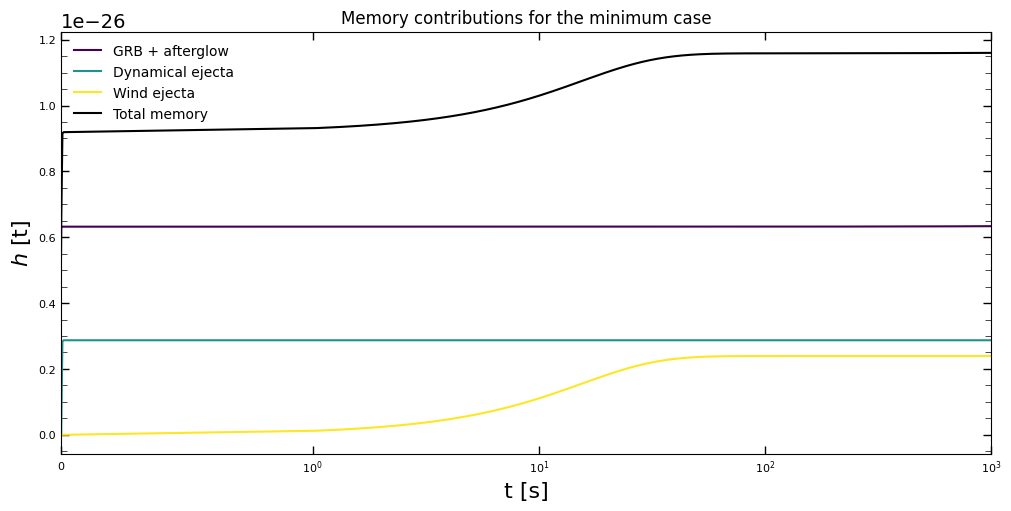

In [47]:
t = np.linspace(-0.1, 5e3, int(1e6))  # -10 s à 1e6 s
r = 100e6  # 100 Mpc
case_min = {
    'E_j': 1e49,  
    'P_in': 1e48,
    'theta_j': np.deg2rad(5),
    'theta_v': np.deg2rad(5),
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 1e6,  # 1 Mpc
    'tau_grb_s': 1e-3,  # s
    'end_grb_s': 200,   # s
    'M_ej_dyn': 0.0003, 
    'v_ej_dyn': 0.1, 
    'M_ej_wind': 1e-3,
    'v_ej_wind': 0.05,
    'tau_dyn_s': 1e-3,
    'start_wind': 10e-3, 
    'end_wind': 10e3,
    'tau_wind_s': 10,
    'radius_grb_afterglow': 0.01 # radius at which the GRB and afterglow memory are evaluated for the total memory calculation
}
# Dyn and wind afterglow contributions for the minimum case
h_dyn = up.linear_memory_ejecta_masked(t, case_min['M_ej_dyn'], case_min['v_ej_dyn'], case_min['tau_dyn_s'], r, start_s=0, model = 'exponential')
h_wind = up.linear_memory_ejecta_masked(t, case_min['M_ej_wind'], case_min['v_ej_wind'], case_min['tau_wind_s'],r, start_s=case_min['start_wind'])
# GRB + afterglow contribution for the minimum case
h_grb = up.memory_initial_acceleration_GRB(case_min['E_j'], case_min['theta_ej'], case_min['phi_ej'], r, case_min['beta'])
h_afterglow = up.memory_afterglow_injection(case_min['P_in'], case_min['end_grb_s'], case_min['theta_ej'], case_min['theta_j'], r, case_min['beta'])
h_tot_grb_afterglow, _ = up.memory_total_waveform(t, h_grb, h_afterglow, case_min['end_grb_s'], case_min['theta_ej'], radius=case_min['radius_grb_afterglow'])
print(f"Initial GRB memory: {h_grb:.2e}, Afterglow memory: {h_afterglow:.2e}, Dynamical ejecta memory: {h_dyn[-1]:.2e}, Wind ejecta memory: {h_wind[-1]:.2e}")
# First plot in temporal domain
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.plot(t, h_tot_grb_afterglow, label='GRB + afterglow', color=colors[0])


ax.plot(t, h_dyn, label='Dynamical ejecta', color=colors[1])

ax.plot(t, h_wind, label='Wind ejecta', color=colors[2])


ax.plot(t, h_tot_grb_afterglow + h_dyn + h_wind, label='Total memory', color='black')

ax.set_xlabel('t [s]')
ax.set_xscale('log')
ax.set_xscale('symlog', linthresh=1, linscale=1.0)
ax.set_xlim(-0.0, 1e3)

ax.minorticks_on()
ax.set_ylabel(r'$h$ [t]')
ax.set_title('Memory contributions for the minimum case')
ax.minorticks_on()
ax.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
ax.legend(loc='best', frameon=False)
plt.show()


Center on the first ms 

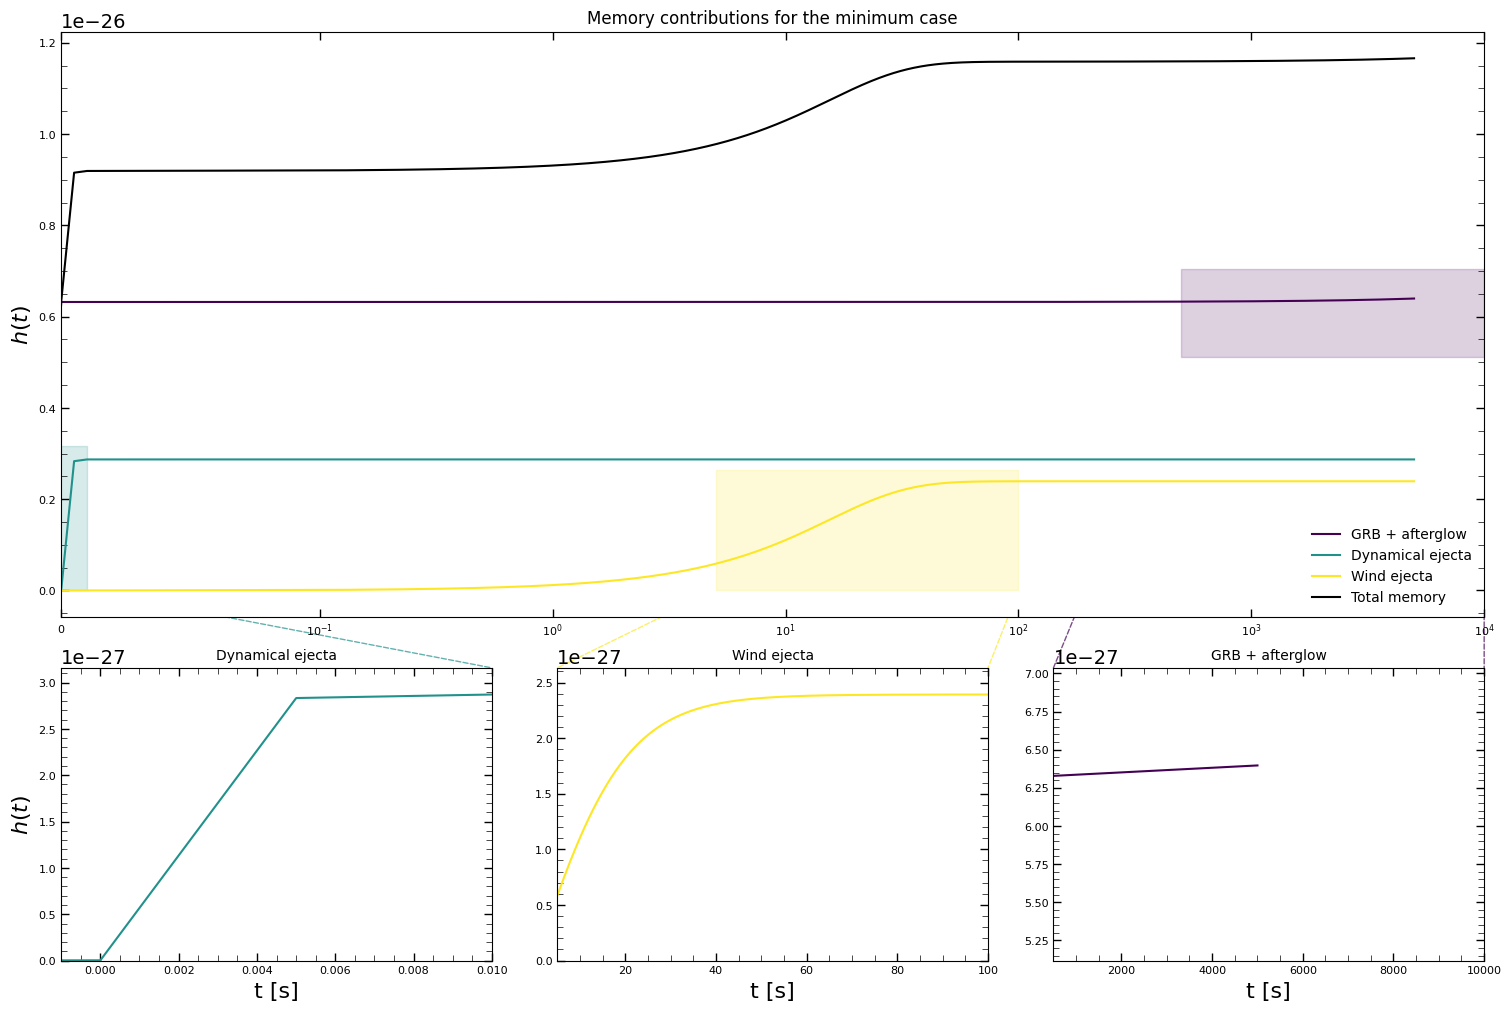

In [48]:
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch

# --- PARAMÈTRES DE ZOOM POUR CHAQUE INSET ---
# (x_min, x_max, y_min, y_max) pour chaque composant
zoom_regions = [
    (-1e-3, 0.01, 0.8 * np.min(h_dyn), 1.1 * np.max(h_dyn)),                            # Dynamical ejecta
    (5, 100, 0.8 * np.min(h_wind), 1.1 * np.max(h_wind)),                                # Wind ejecta
    (5e2, 1e4, 0.8 * np.max(h_tot_grb_afterglow), 1.1 * np.max(h_tot_grb_afterglow)),   # GRB + afterglow


]

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
gs = GridSpec(2, 3, figure=fig, height_ratios=[3, 1.5])

# --- GRAPHIQUE PRINCIPAL ---
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(t, h_tot_grb_afterglow, label='GRB + afterglow', color=colors[0])
ax_main.plot(t, h_dyn, label='Dynamical ejecta', color=colors[1])
ax_main.plot(t, h_wind, label='Wind ejecta', color=colors[2])
ax_main.plot(t, h_tot_grb_afterglow + h_dyn + h_wind, label='Total memory', color='black')

ax_main.set_xscale('symlog', linthresh=0.1)
ax_main.set_xlim(-0., 1e4)
ax_main.set_ylabel(r'$h(t)$')
ax_main.set_title('Memory contributions for the minimum case')
ax_main.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
ax_main.legend(loc='lower right', frameon=False)
ax_main.minorticks_on()

# --- INSETS ZOOMÉS ---
insets_data = [
    {'data': h_dyn, 'color': colors[1], 'label': 'Dynamical ejecta'},
    {'data': h_wind, 'color': colors[2], 'label': 'Wind ejecta'},
        {'data': h_tot_grb_afterglow, 'color': colors[0], 'label': 'GRB + afterglow'}
]

for i, inset in enumerate(insets_data):
    ax_inset = fig.add_subplot(gs[1, i])
    x0, x1, y0, y1 = zoom_regions[i]
    # Zone de zoom personnalisée sur le plot principal (rectangles limités en y)
    ax_main.fill_between(
        [x0, x1], [y0, y0], [y1, y1],
        color=inset['color'], alpha=0.18, zorder=0
    )
    # Plot dans l'inset
    ax_inset.plot(t, inset['data'], color=inset['color'])
    ax_inset.set_xlim((x0, x1))
    ax_inset.set_ylim((y0, y1))
    ax_inset.set_title(inset['label'], fontsize=10)
    ax_inset.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
    ax_inset.minorticks_on()
    if i == 0:
        ax_inset.set_ylabel(r'$h(t)$')
    ax_inset.set_xlabel('t [s]')

    # Lignes de connexion
    con1 = ConnectionPatch(xyA=(x0, y0), xyB=(x0, y1),
                           coordsA="data", coordsB="data", axesA=ax_main, axesB=ax_inset,
                           color=inset['color'], linestyle='--', zorder=0, alpha=0.7)
    con2 = ConnectionPatch(xyA=(x1, y0), xyB=(x1, y1),
                           coordsA="data", coordsB="data", axesA=ax_main, axesB=ax_inset,
                           color=inset['color'], linestyle='--', zorder=0, alpha=0.7)
    fig.add_artist(con1)
    fig.add_artist(con2)

plt.show()


Now fft part

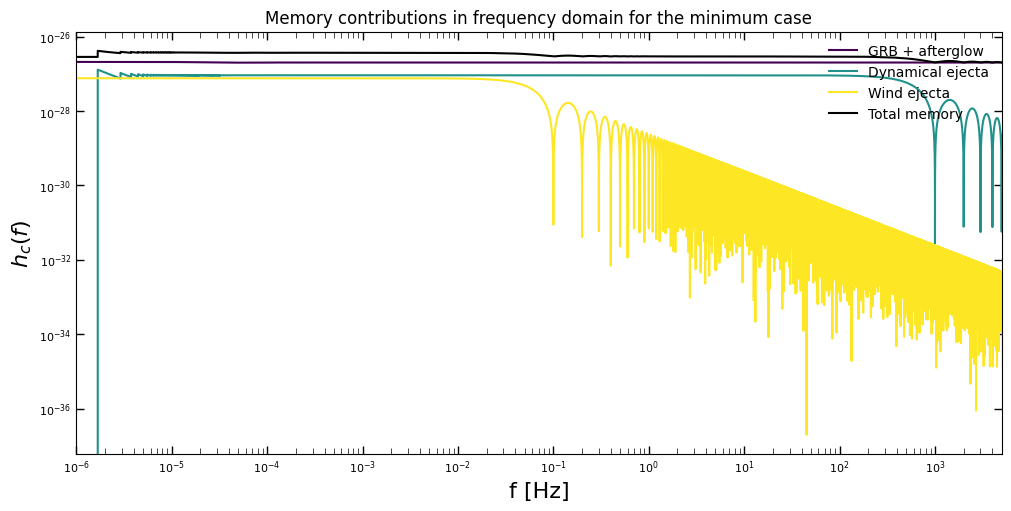

In [49]:
# dyn - wind: 
f, fft_dyn = up.memory_fft_formula(h_dyn[-1], case_min['tau_dyn_s'], plot=False)
f, fft_wind = up.memory_fft_formula(h_wind[-1], case_min['tau_wind_s'], plot=False)
f, fft_grb_afterglow = up.new_fft(h_grb, h_afterglow, case_min['end_grb_s'], case_min['theta_ej'], radius=case_min['radius_grb_afterglow'])
# plot in frequency domain
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.loglog(f, 2*f*np.abs(fft_grb_afterglow), label='GRB + afterglow', color=colors[0])
ax.loglog(f, np.abs(fft_dyn), label='Dynamical ejecta', color=colors[1])
ax.loglog(f, np.abs(fft_wind), label='Wind ejecta', color=colors[2])
ax.loglog(f, np.abs(2 * f * fft_grb_afterglow + fft_dyn + fft_wind), label='Total memory', color='black')
ax.set_xlabel('f [Hz]')
ax.set_ylabel(r'$h_c(f)$')
ax.set_title('Memory contributions in frequency domain for the minimum case')
plt.legend(loc='upper right', frameon=False)
ax.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
ax.set_xlim(1e-6, 5e3)

plt.show()

## Visualization of the memory in a spectrogram

### SFFT (short-time Fourier transform)

In [50]:
from scipy.signal import stft
def sfft(signal, fs, t_start):
    f, t, Zxx = stft(signal, fs=fs, nperseg=512, noverlap=500)
    t += t_start # add the start time to the time array to get the correct time values
    return f, t, np.abs(Zxx)

/tmp/ipykernel_1138/2201579355.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc='upper right', frameon=False)
/tmp/ipykernel_1138/2201579355.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(loc='upper right', frameon=False)


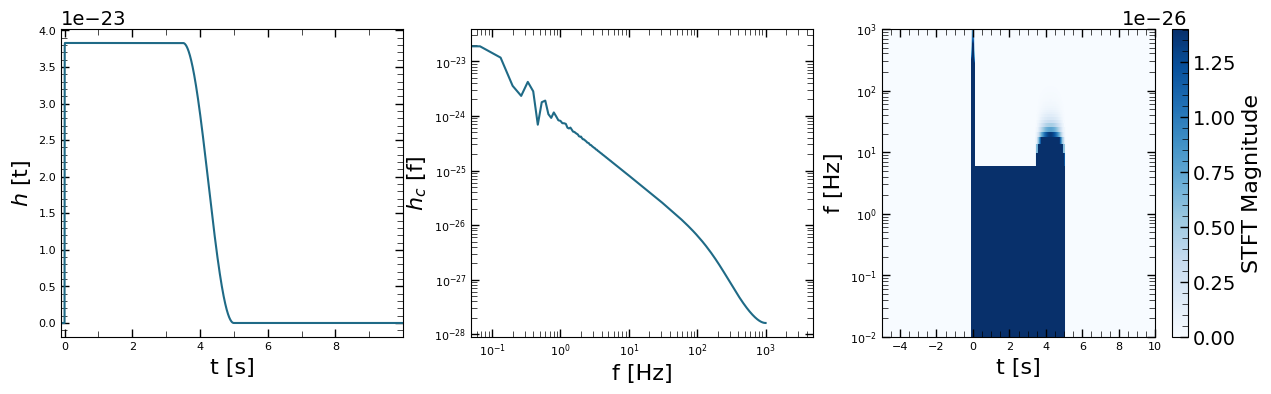

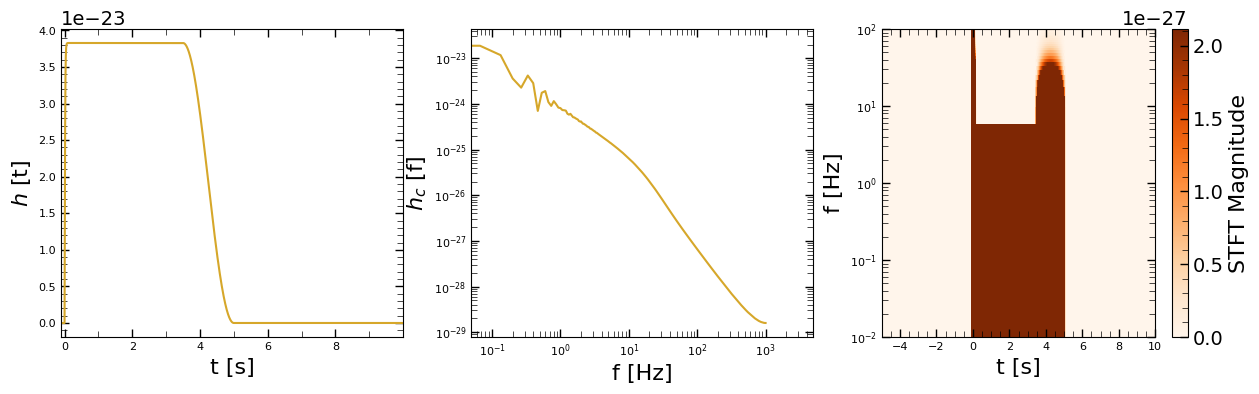

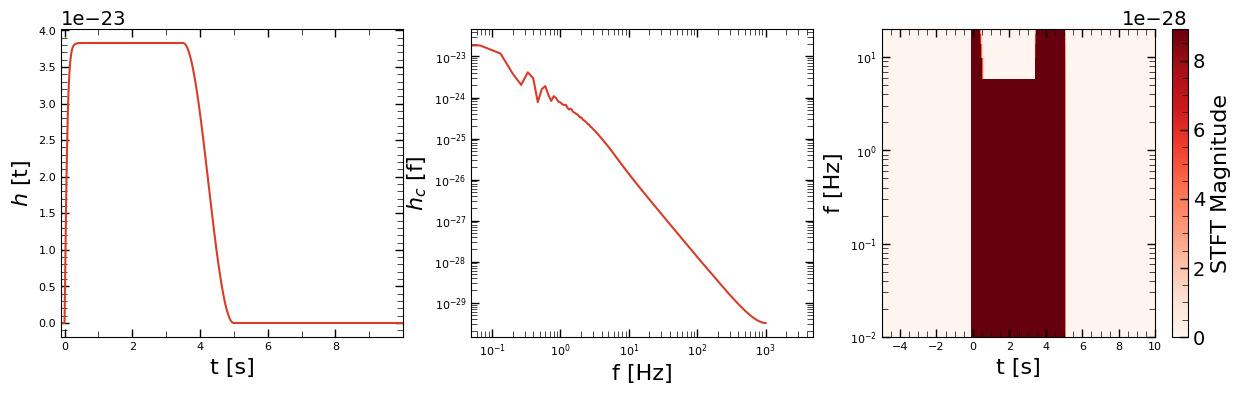

In [51]:
from matplotlib.ticker import SymmetricalLogLocator
## Test of the stft for : 
# 1. Dyn only 
# Plot for illustration
tau = [1e-3, 1e-2, 5e-2] # timescales in seconds
dt = 5e-4 # dt << tau to properly sample the signal and the rising part of the memory
t = np.arange(-5, 5, dt)
fs = 1/dt  # sampling frequency
start_dyn = 0
M_ej = 0.01 # ejecta masses in solar masses
v_ej = 0.2

r = 1e6 # 1 Mpc
theta_ej = np.pi / 4 # observer angle in radians
colors = ['#1F6A86','#D6A72A', '#D63E2A']
cmaps = ['Blues', 'Oranges', 'Reds']
for idx, tau_i in enumerate(tau):
    fig, ax = plt.subplots(1,3, figsize=(15, 4), constrained_layout=False)
    # h temporal
    delta_h = up.delta_h_ejecta(M_ej, v_ej, r)
    h_t = up.linear_memory_ejecta_masked(t, M_ej, v_ej, tau_i, r, start_dyn, model='exponential')
    # pre-process the signal 
    import utils_signal as usig

    h_t_windowed = usig.apply_window(h_t, window_type='tukey', alpha=0.3)
    t_pad,h_t_windowed = usig.pad_signal(h_t_windowed, t, r=0.5) 
    # h frequency
    f, fft = usig.fft_signal(t, h_t_windowed)
    # h spectrogram
    f_stft, t_stft, Zxx = sfft(h_t_windowed, fs, t_start=t[0])
    f_char = 1/tau_i
    # Plotting
    ax[0].plot(t_pad, h_t_windowed, color=colors[idx])
    ax[0].set_xlabel('t [s]')
    ax[0].set_ylabel(r'$h $ [t]')
    ax[0].set_xlim(-0.1, t_pad[-1])
    ax[0].tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
    ax[0].minorticks_on()
    ax[0].xaxis.set_minor_locator(
        SymmetricalLogLocator(linthresh=1, base=10, subs=[x for x in range(1, 10)]))
    ax[1].loglog(f, np.abs(fft), color=colors[idx])
    ax[1].set_xlim(5e-2, 5e3)
    ax[1].set_xlabel('f [Hz]')
    ax[1].set_ylabel(r'$h_c$ [f]')
    ax[1].tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
    ax[1].legend(loc='upper right', frameon=False)
    
    vmin, vmax = np.percentile(Zxx, [1, 99])
    im = ax[2].pcolormesh(t_stft, f_stft, Zxx, shading='auto', cmap=cmaps[idx], vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax[2], label='STFT Magnitude')
 
    ax[2].set_xlabel('t [s]')
    ax[2].set_ylabel('f [Hz]')
    #ax[2].set_xlim(-0.25, 0.25)
    ax[2].set_ylim(1e-2, f_char)
    ax[2].set_yscale('log')
  

    ax[2].tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
    ax[2].legend(loc='upper right', frameon=False)
    plt.show()

Check the impact of the window length on the spectrogram !

Use of the `scipy.signal.spectrogram` function to compute the spectrogram of the memory signal

3.8283326732702734e-23


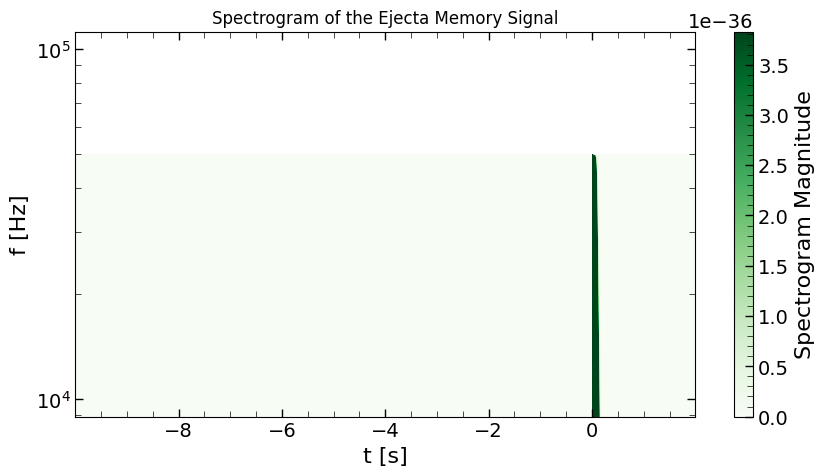

In [52]:
dt = 1e-5
t = np.arange(-10, 2, dt)
fs = 1/dt
tau = 1e-2
M_ej = 0.01
v_ej = 0.2
r = 1e6
theta_ej = np.pi / 2
h_t = up.linear_memory_ejecta_masked(t, M_ej, v_ej, tau, r, 0, model='exponential')
print(h_t[-1])
# use scipy spectrogram function to compute the spectrogram
from scipy.signal import spectrogram
f_spec, t_spec, Sxx = spectrogram(h_t, fs=fs, nperseg=500, noverlap=0.95*500, window='hann')
Sxx = np.sqrt(Sxx)
# Plot the spectrogram
plt.figure(figsize=(10, 5))
vmin, vmax = np.percentile(Sxx, [1, 99])
t_centered = t_spec + t[0]  # center the time values around the original time array
plt.pcolormesh(t_centered, f_spec, Sxx, shading='auto', cmap='Greens', vmin=vmin, vmax=vmax)
plt.colorbar(label='Spectrogram Magnitude')
plt.xlabel('t [s]')
plt.ylabel('f [Hz]')
plt.yscale('log')
plt.title('Spectrogram of the Ejecta Memory Signal')
plt.show()